# F1 Podium Prediction — Milestone 1

This notebook predicts whether each driver entering a race finishes on the podium,
using only information available after qualifying and before the race starts.

The notebook covers data auditing and cleaning, exploratory analysis, the three
data-engineering questions, leakage-safe feature engineering, preprocessing,
temporal model evaluation, threshold selection, feature-group ablation, XAI,
and inference.

**Reproducibility note:** the original EDA and analysis plot code is preserved;
only execution-order, import, dataset-path, and robustness fixes were applied.


In [3]:
# ============================================================
# F1 PODIUM PREDICTION — CORE IMPORTS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Explainability
import shap

# Reproducibility: fix every random seed (Python, NumPy, TensorFlow/Keras)
# and ask TensorFlow for deterministic operations, so a Run All always
# gives the same neural-network results.
import random
random.seed(42)
np.random.seed(42)
keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

warnings.filterwarnings("ignore")

print("Core libraries imported successfully.")


Core libraries imported successfully.


In [4]:
# ============================================================
# DATA LOADING — ROBUST KAGGLE PATH DETECTION
# ============================================================

required_files = {
    "circuits.csv",
    "constructors.csv",
    "constructor_results.csv",
    "constructor_standings.csv",
    "drivers.csv",
    "driver_standings.csv",
    "lap_times.csv",
    "pit_stops.csv",
    "qualifying.csv",
    "races.csv",
    "results.csv",
    "seasons.csv",
    "sprint_results.csv",
    "status.csv"
}

DATA_PATH = None

for root, dirs, files in os.walk("/kaggle/input"):
    if required_files.issubset(set(files)):
        DATA_PATH = root
        break

# Fallback for running outside Kaggle (e.g. a GitHub clone with the CSVs in ./archive).
if DATA_PATH is None and os.path.isdir("archive"):
    DATA_PATH = "archive"

if DATA_PATH is None:
    raise FileNotFoundError(
        "The F1 dataset was not found under /kaggle/input. "
        "Attach the dataset using Kaggle's Add Input/Add Data button."
    )

print("Using dataset path:", DATA_PATH)

# Load all 14 tables. The literal \\N sentinel is converted to NaN.
circuits = pd.read_csv(f"{DATA_PATH}/circuits.csv", na_values="\\N")
constructors = pd.read_csv(f"{DATA_PATH}/constructors.csv", na_values="\\N")
constructor_results = pd.read_csv(f"{DATA_PATH}/constructor_results.csv", na_values="\\N")
constructor_standings = pd.read_csv(f"{DATA_PATH}/constructor_standings.csv", na_values="\\N")
drivers = pd.read_csv(f"{DATA_PATH}/drivers.csv", na_values="\\N")
driver_standings = pd.read_csv(f"{DATA_PATH}/driver_standings.csv", na_values="\\N")
lap_times = pd.read_csv(f"{DATA_PATH}/lap_times.csv", na_values="\\N")
pit_stops = pd.read_csv(f"{DATA_PATH}/pit_stops.csv", na_values="\\N")
qualifying = pd.read_csv(f"{DATA_PATH}/qualifying.csv", na_values="\\N")
races = pd.read_csv(f"{DATA_PATH}/races.csv", na_values="\\N")
results = pd.read_csv(f"{DATA_PATH}/results.csv", na_values="\\N")
seasons = pd.read_csv(f"{DATA_PATH}/seasons.csv", na_values="\\N")
sprint_results = pd.read_csv(f"{DATA_PATH}/sprint_results.csv", na_values="\\N")
status = pd.read_csv(f"{DATA_PATH}/status.csv", na_values="\\N")

print("All 14 tables loaded successfully!")


Using dataset path: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
All 14 tables loaded successfully!


---
## CHECKPOINT 1 — Exploratory Data Analysis (EDA)

**Checklist items covered:** EDA of the raw data, before cleaning (the after-cleaning EDA plots are in Checkpoint 3).

**Evidence:** Table shapes, missing values per table, candidate-key checks, the duplicated (raceId, driverId) pairs, and qualifying coverage per season in the cells below; before/after cleaning plots in Checkpoint 2.

---

In [5]:
tables = {
    "circuits": circuits,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "drivers": drivers,
    "driver_standings": driver_standings,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

for name, df in tables.items():
    print(f"{name:25} → {df.shape}")

circuits                  → (77, 9)
constructors              → (212, 5)
constructor_results       → (12625, 5)
constructor_standings     → (13391, 7)
drivers                   → (861, 9)
driver_standings          → (34863, 7)
lap_times                 → (589081, 6)
pit_stops                 → (11371, 7)
qualifying                → (10494, 9)
races                     → (1125, 18)
results                   → (26759, 18)
seasons                   → (75, 2)
sprint_results            → (360, 16)
status                    → (139, 2)


In [6]:
audit = []

for name, df in tables.items():
    audit.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

audit_df = pd.DataFrame(audit)

audit_df

,Table,Rows,Columns,Missing Values,Duplicate Rows
0,circuits,77,9,0,0
1,constructors,212,5,0,0
2,constructor_results,12625,5,12608,0
3,constructor_standings,13391,7,0,0
4,drivers,861,9,1559,0
5,driver_standings,34863,7,0,0
6,lap_times,589081,6,0,0
7,pit_stops,11371,7,0,0
8,qualifying,10494,9,11668,0
9,races,1125,18,11349,0


In [7]:
for name, df in tables.items():
    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}")
    print("Columns:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2}. {col}")


CIRCUITS
Columns:
 1. circuitId
 2. circuitRef
 3. name
 4. location
 5. country
 6. lat
 7. lng
 8. alt
 9. url

CONSTRUCTORS
Columns:
 1. constructorId
 2. constructorRef
 3. name
 4. nationality
 5. url

CONSTRUCTOR_RESULTS
Columns:
 1. constructorResultsId
 2. raceId
 3. constructorId
 4. points
 5. status

CONSTRUCTOR_STANDINGS
Columns:
 1. constructorStandingsId
 2. raceId
 3. constructorId
 4. points
 5. position
 6. positionText
 7. wins

DRIVERS
Columns:
 1. driverId
 2. driverRef
 3. number
 4. code
 5. forename
 6. surname
 7. dob
 8. nationality
 9. url

DRIVER_STANDINGS
Columns:
 1. driverStandingsId
 2. raceId
 3. driverId
 4. points
 5. position
 6. positionText
 7. wins

LAP_TIMES
Columns:
 1. raceId
 2. driverId
 3. lap
 4. position
 5. time
 6. milliseconds

PIT_STOPS
Columns:
 1. raceId
 2. driverId
 3. stop
 4. lap
 5. time
 6. duration
 7. milliseconds

QUALIFYING
Columns:
 1. qualifyId
 2. raceId
 3. driverId
 4. constructorId
 5. number
 6. position
 7. q1
 8. q

In [8]:
for name, df in tables.items():
    missing = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)

    missing_table = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_pct
    })

    missing_table = missing_table[missing_table["Missing Count"] > 0]

    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}")
    print(missing_table.sort_values("Missing %", ascending=False))


CIRCUITS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

CONSTRUCTORS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

CONSTRUCTOR_RESULTS
        Missing Count  Missing %
status          12608      99.87

CONSTRUCTOR_STANDINGS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

DRIVERS
        Missing Count  Missing %
number            802      93.15
code              757      87.92

DRIVER_STANDINGS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

LAP_TIMES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

PIT_STOPS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

QUALIFYING
    Missing Count  Missing %
q3           6865      65.42
q2           4647      44.28
q1            156       1.49

RACES
             Missing Count  Missing %
sprint_time           1110      98.67
sprint_date           1107      98.40
fp3_time              1072      95.29
quali_time            1057      93.96
fp2_time             

In [9]:
candidate_keys = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "qualifying": ["qualifyId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "seasons": ["year"],
    "sprint_results": ["resultId"],
    "status": ["statusId"]
}

for table_name, keys in candidate_keys.items():
    df = tables[table_name]

    duplicate_count = df.duplicated(subset=keys).sum()

    print(
        f"{table_name:25} "
        f"Key = {keys} | "
        f"Duplicate key rows = {duplicate_count}"
    )

circuits                  Key = ['circuitId'] | Duplicate key rows = 0
constructors              Key = ['constructorId'] | Duplicate key rows = 0
constructor_results       Key = ['constructorResultsId'] | Duplicate key rows = 0
constructor_standings     Key = ['constructorStandingsId'] | Duplicate key rows = 0
drivers                   Key = ['driverId'] | Duplicate key rows = 0
driver_standings          Key = ['driverStandingsId'] | Duplicate key rows = 0
lap_times                 Key = ['raceId', 'driverId', 'lap'] | Duplicate key rows = 0
pit_stops                 Key = ['raceId', 'driverId', 'stop'] | Duplicate key rows = 0
qualifying                Key = ['qualifyId'] | Duplicate key rows = 0
races                     Key = ['raceId'] | Duplicate key rows = 0
results                   Key = ['resultId'] | Duplicate key rows = 0
seasons                   Key = ['year'] | Duplicate key rows = 0
sprint_results            Key = ['resultId'] | Duplicate key rows = 0
status             

In [10]:
# Check whether each driver appears only once in each race

race_driver_counts = (
    results
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="row_count")
)

duplicates = race_driver_counts[
    race_driver_counts["row_count"] > 1
]

print("Total unique (raceId, driverId) combinations:",
      len(race_driver_counts))

print("Duplicated (raceId, driverId) combinations:",
      len(duplicates))

print("\nDuplicated combinations:")
display(duplicates.head(20))

Total unique (raceId, driverId) combinations: 26668
Duplicated (raceId, driverId) combinations: 85

Duplicated combinations:


,raceId,driverId,row_count
13659,540,229,2
17821,717,373,2
18222,733,465,2
18445,742,475,2
18532,745,418,2
18553,746,475,2
18982,766,541,2
19080,770,479,2
19170,774,566,2
19210,776,581,2


In [11]:
# Inspect the actual result records for duplicated race-driver pairs

duplicate_keys = duplicates[["raceId", "driverId"]]

duplicate_results = results.merge(
    duplicate_keys,
    on=["raceId", "driverId"],
    how="inner"
)

display(
    duplicate_results.sort_values(
        ["raceId", "driverId"]
    ).head(50)
)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,13189,540,229,54,10.0,0,NaN,F,26,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,81
1,13192,540,229,57,23.0,0,NaN,F,29,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,97
2,17363,717,373,172,1.0,1,7.0,7,7,0.0,102,NaN,NaN,NaN,NaN,NaN,NaN,60
175,24304,717,373,172,2.0,1,NaN,R,12,0.0,54,NaN,NaN,NaN,NaN,NaN,NaN,98
3,17741,733,465,172,48.0,0,NaN,W,22,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54
4,17744,733,465,97,50.0,0,NaN,W,25,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54
5,17962,742,475,102,26.0,20,NaN,D,19,0.0,56,NaN,NaN,NaN,NaN,NaN,NaN,2
6,17964,742,475,172,28.0,5,NaN,R,21,0.0,44,NaN,NaN,NaN,NaN,NaN,NaN,23
7,18063,745,418,172,22.0,11,NaN,R,17,0.0,23,NaN,NaN,NaN,NaN,NaN,NaN,6
174,24303,745,418,172,21.0,15,11.0,11,11,0.0,92,NaN,NaN,NaN,NaN,NaN,NaN,18


In [12]:
# Add race year to the duplicated race-driver combinations

duplicate_details = (
    duplicate_results
    .merge(
        races[["raceId", "year", "name"]],
        on="raceId",
        how="left"
    )
    .sort_values(["year", "raceId", "driverId"])
)

display(
    duplicate_details[
        [
            "raceId",
            "year",
            "name",
            "driverId",
            "constructorId",
            "grid",
            "position",
            "positionOrder",
            "points",
            "laps",
            "statusId"
        ]
    ].head(100)
)

,raceId,year,name,driverId,constructorId,grid,position,positionOrder,points,laps,statusId
84,835,1950,Indianapolis 500,529,150,8,NaN,31,0.0,30,67
88,835,1950,Indianapolis 500,529,113,9,5.0,5,1.0,136,12
85,838,1950,French Grand Prix,627,154,6,NaN,12,0.0,10,25
89,838,1950,French Grand Prix,627,154,15,6.0,6,0.0,56,18
86,839,1950,Italian Grand Prix,579,51,1,NaN,15,1.0,23,6
...,...,...,...,...,...,...,...,...,...,...,...
40,792,1955,Argentine Grand Prix,554,105,4,NaN,17,0.0,2,3
139,792,1955,Argentine Grand Prix,554,105,7,6.0,6,0.0,88,18
142,792,1955,Argentine Grand Prix,554,105,19,NaN,8,0.0,54,5
36,792,1955,Argentine Grand Prix,577,105,18,7.0,7,0.0,83,53


In [13]:
# Examine how duplicate race-driver records differ in finishing position

duplicate_summary = (
    duplicate_results
    .groupby(["raceId", "driverId"])
    .agg(
        num_records=("resultId", "count"),
        best_position=("positionOrder", "min"),
        worst_position=("positionOrder", "max"),
        total_points=("points", "sum"),
        years=("raceId", "count")
    )
    .reset_index()
)

# Add race information
duplicate_summary = duplicate_summary.merge(
    races[["raceId", "year", "name"]],
    on="raceId",
    how="left"
)

# Identify cases where one record is a podium
duplicate_summary["has_podium_record"] = (
    duplicate_summary["best_position"] <= 3
)

display(
    duplicate_summary
    .sort_values(["year", "raceId", "driverId"])
    .head(100)
)

print(
    "Duplicate race-driver groups:",
    len(duplicate_summary)
)

print(
    "Groups containing a podium record:",
    duplicate_summary["has_podium_record"].sum()
)

,raceId,driverId,num_records,best_position,worst_position,total_points,years,year,name,has_podium_record
81,835,529,2,5,31,1.0,2,1950,Indianapolis 500,False
82,838,627,2,6,12,0.0,2,1950,French Grand Prix,False
83,839,579,2,13,15,1.0,2,1950,Italian Grand Prix,False
84,839,647,2,2,17,3.0,2,1950,Italian Grand Prix,True
77,828,579,2,1,11,5.0,2,1951,French Grand Prix,True
...,...,...,...,...,...,...,...,...,...,...
3,742,475,2,19,21,0.0,2,1961,British Grand Prix,False
4,745,418,2,11,17,0.0,2,1961,United States Grand Prix,False
2,733,465,2,22,25,0.0,2,1962,British Grand Prix,False
1,717,373,2,7,12,0.0,2,1964,United States Grand Prix,False


Duplicate race-driver groups: 85
Groups containing a podium record: 22


In [14]:
# Create one row per (raceId, driverId)
# using the best finishing result for historical duplicate entries.

results_clean = (
    results
    .sort_values(["positionOrder", "resultId"], na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)

print("Original results rows:", len(results))
print("Cleaned race-driver rows:", len(results_clean))

# Verify uniqueness
duplicate_check = results_clean.duplicated(
    subset=["raceId", "driverId"]
).sum()

print("Remaining duplicate (raceId, driverId) pairs:", duplicate_check)

Original results rows: 26759
Cleaned race-driver rows: 26668
Remaining duplicate (raceId, driverId) pairs: 0


In [15]:
# Check whether every race-driver result has a qualifying record

race_driver_qualifying = results_clean[
    ["raceId", "driverId"]
].merge(
    qualifying[
        ["raceId", "driverId"]
    ],
    on=["raceId", "driverId"],
    how="left",
    indicator=True
)

qualifying_match_counts = (
    race_driver_qualifying["_merge"]
    .value_counts()
)

print(qualifying_match_counts)

print("\nTotal race-driver rows:", len(results_clean))

print(
    "Rows with qualifying record:",
    (race_driver_qualifying["_merge"] == "both").sum()
)

print(
    "Rows without qualifying record:",
    (race_driver_qualifying["_merge"] == "left_only").sum()
)

_merge
left_only     16174
both          10494
right_only        0
Name: count, dtype: int64

Total race-driver rows: 26668
Rows with qualifying record: 10494
Rows without qualifying record: 16174


In [16]:
# Check qualifying coverage across F1 history

qualifying_coverage = (
    results_clean[
        ["raceId", "driverId"]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
    .merge(
        qualifying[["raceId", "driverId"]],
        on=["raceId", "driverId"],
        how="left",
        indicator=True
    )
    .groupby("year")
    .agg(
        total_race_drivers=("driverId", "size"),
        with_qualifying=(
            "_merge",
            lambda x: (x == "both").sum()
        ),
        without_qualifying=(
            "_merge",
            lambda x: (x == "left_only").sum()
        )
    )
    .reset_index()
)

qualifying_coverage["qualifying_coverage_pct"] = (
    qualifying_coverage["with_qualifying"]
    / qualifying_coverage["total_race_drivers"]
    * 100
)

display(qualifying_coverage.to_string(index=False))

' year  total_race_drivers  with_qualifying  without_qualifying  qualifying_coverage_pct\n 1950                 156                0                 156                 0.000000\n 1951                 175                0                 175                 0.000000\n 1952                 212                0                 212                 0.000000\n 1953                 230                0                 230                 0.000000\n 1954                 213                0                 213                 0.000000\n 1955                 162                0                 162                 0.000000\n 1956                 178                0                 178                 0.000000\n 1957                 163                0                 163                 0.000000\n 1958                 238                0                 238                 0.000000\n 1959                 195                0                 195                 0.000000\n 1960               

In [17]:
# Find race-driver records after 2003 that have no qualifying record

missing_modern_qualifying = (
    results_clean[
        ["raceId", "driverId"]
    ]
    .merge(
        races[["raceId", "year", "name"]],
        on="raceId",
        how="left"
    )
    .merge(
        qualifying[["raceId", "driverId"]],
        on=["raceId", "driverId"],
        how="left",
        indicator=True
    )
)

missing_modern_qualifying = (
    missing_modern_qualifying[
        (missing_modern_qualifying["year"] >= 2003) &
        (missing_modern_qualifying["_merge"] == "left_only")
    ]
    .sort_values(["year", "raceId", "driverId"])
)

print(
    "Missing qualifying records from 2003 onward:",
    len(missing_modern_qualifying)
)

display(missing_modern_qualifying)

Missing qualifying records from 2003 onward: 24


,raceId,driverId,year,name,_merge
11026,844,155,2011,Turkish Grand Prix,left_only
8770,845,2,2011,Spanish Grand Prix,left_only
5386,852,30,2011,Belgian Grand Prix,left_only
13291,858,22,2011,Abu Dhabi Grand Prix,left_only
12173,865,815,2012,Monaco Grand Prix,left_only
24708,867,10,2012,European Grand Prix,left_only
22966,872,807,2012,Italian Grand Prix,left_only
22040,875,39,2012,Korean Grand Prix,left_only
8842,918,20,2014,Abu Dhabi Grand Prix,left_only
4319,918,817,2014,Abu Dhabi Grand Prix,left_only


In [18]:
# Inspect the 24 modern race-driver observations
# that have a race result but no qualifying record.

missing_ids = missing_modern_qualifying[
    ["raceId", "driverId", "year", "name"]
]

missing_details = (
    missing_ids
    .merge(
        results_clean[
            [
                "raceId",
                "driverId",
                "constructorId",
                "grid",
                "position",
                "positionOrder",
                "points",
                "statusId"
            ]
        ],
        on=["raceId", "driverId"],
        how="left"
    )
    .merge(
        drivers[
            ["driverId", "forename", "surname"]
        ],
        on="driverId",
        how="left"
    )
    .sort_values(["year", "raceId", "driverId"])
)

display(missing_details)

,raceId,driverId,year,name,constructorId,grid,position,positionOrder,points,statusId,forename,surname
0,844,155,2011,Turkish Grand Prix,15,24,10.0,10,1.0,1,Kamui,Kobayashi
1,845,2,2011,Spanish Grand Prix,4,24,8.0,8,4.0,11,Nick,Heidfeld
2,852,30,2011,Belgian Grand Prix,131,24,5.0,5,10.0,1,Michael,Schumacher
3,858,22,2011,Abu Dhabi Grand Prix,3,24,12.0,12,0.0,11,Rubens,Barrichello
4,865,815,2012,Monaco Grand Prix,15,23,11.0,11,0.0,11,Sergio,Pérez
5,867,10,2012,European Grand Prix,206,0,NaN,24,0.0,54,Timo,Glock
6,872,807,2012,Italian Grand Prix,10,24,21.0,21,0.0,23,Nico,Hülkenberg
7,875,39,2012,Korean Grand Prix,164,23,20.0,20,0.0,12,Narain,Karthikeyan
8,918,20,2014,Abu Dhabi Grand Prix,9,19,8.0,8,8.0,1,Sebastian,Vettel
9,918,817,2014,Abu Dhabi Grand Prix,9,20,4.0,4,24.0,1,Daniel,Ricciardo


In [19]:
# Keep a consistent alias for downstream code; do not overwrite DATA_PATH.
data_path = DATA_PATH


---
## CHECKPOINT 2 — Data Cleaning

**Checklist items covered:** Sentinel handling (`\N`) and semantic typing; grain fixed to one row per (raceId, driverId) with duplicates documented; primary-key and foreign-key checks.

**Evidence:** Sentinel and semantic-typing reports, primary-key and foreign-key tables, the duplicate-rule justification, and the before/after cleaning plots (rows and podium rate) below.

---

## Data Cleaning and Integrity

Raw CSV files remain immutable. Cleaning is performed on copies. Primary-key
quality, foreign-key reconciliation, and the required one-row-per-driver-race
grain are verified before modeling.

### Sentinel Handling and Semantic Typing

The CSV files use the literal `\N` as a missing-value sentinel. During loading, `pandas.read_csv`
maps this sentinel to `NaN` through `na_values="\\N"`, so later analysis can distinguish
missing values from real numeric or text values.

The cleaning stage also applies semantic typing to dates and duration-like fields. Race dates
and driver dates of birth are converted to datetime values. Qualifying session times are
converted from `m:ss.sss` strings to numeric seconds, and lap/pit-stop duration fields are
converted to numeric seconds on separate working copies where applicable.

Raw CSV tables remain unchanged; typed/cleaned copies are used for analysis.


In [20]:
# ============================================================
# Sentinel handling and semantic typing verification
# ============================================================

# 1. Confirm that the loaded tables contain no literal "\N" strings.
sentinel_report = []

for table_name, df in tables.items():
    literal_sentinels = int(
        (df.astype("object") == r"\N").sum().sum()
    )
    sentinel_report.append({
        "Table": table_name,
        "Literal \\N values remaining": literal_sentinels
    })

sentinel_report_df = pd.DataFrame(sentinel_report)

print("Literal sentinel check:")
display(sentinel_report_df)

# 2. Semantic typing on working copies.
races_typed = races.copy()
races_typed["date"] = pd.to_datetime(
    races_typed["date"],
    errors="coerce"
)

drivers_typed = drivers.copy()
drivers_typed["dob"] = pd.to_datetime(
    drivers_typed["dob"],
    errors="coerce"
)

def duration_to_seconds(value):
    """Convert common duration strings to seconds.

    Supported formats include:
    - M:SS.sss      (e.g. 2:05.152)
    - H:MM:SS.sss  (e.g. 2:05:05.152)
    - numeric values already expressed in seconds
    """
    if pd.isna(value):
        return np.nan

    text_value = str(value).strip()

    if not text_value:
        return np.nan

    parts = text_value.split(":")

    try:
        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = float(parts[1])
            return minutes * 60 + seconds

        if len(parts) == 3:
            hours = int(parts[0])
            minutes = int(parts[1])
            seconds = float(parts[2])
            return hours * 3600 + minutes * 60 + seconds

        return float(text_value)

    except (ValueError, TypeError):
        return np.nan

# Qualifying duration typing (working copy).
qualifying_typed = qualifying.copy()

for col in ["q1", "q2", "q3"]:
    qualifying_typed[f"{col}_seconds"] = (
        qualifying_typed[col].apply(duration_to_seconds)
    )

# Lap-time duration typing (working copy).
lap_times_typed = lap_times.copy()

if "time" in lap_times_typed.columns:
    lap_times_typed["time_seconds"] = (
        lap_times_typed["time"].apply(duration_to_seconds)
    )

# Pit-stop duration typing (working copy).
pit_stops_typed = pit_stops.copy()

if "duration" in pit_stops_typed.columns:
    pit_stops_typed["duration_seconds"] = (
        pit_stops_typed["duration"].apply(duration_to_seconds)
    )

semantic_type_report = pd.DataFrame({
    "Field": [
        "races.date",
        "drivers.dob",
        "qualifying.q1/q2/q3",
        "lap_times.time",
        "pit_stops.duration"
    ],
    "Typed representation": [
        str(races_typed["date"].dtype),
        str(drivers_typed["dob"].dtype),
        "numeric seconds",
        "numeric seconds",
        "numeric seconds"
    ]
})

print("\nSemantic typing report:")
display(semantic_type_report)


Literal sentinel check:


,Table,Literal \N values remaining
0,circuits,0
1,constructors,0
2,constructor_results,0
3,constructor_standings,0
4,drivers,0
5,driver_standings,0
6,lap_times,0
7,pit_stops,0
8,qualifying,0
9,races,0



Semantic typing report:


,Field,Typed representation
0,races.date,datetime64[ns]
1,drivers.dob,datetime64[ns]
2,qualifying.q1/q2/q3,numeric seconds
3,lap_times.time,numeric seconds
4,pit_stops.duration,numeric seconds


In [21]:
# ============================================================
# Primary-key and foreign-key integrity checks
# ============================================================

primary_key_report = []

for table_name, keys in candidate_keys.items():
    df = tables[table_name]
    primary_key_report.append({
        "Table": table_name,
        "Key": ", ".join(keys),
        "Null-key rows": int(df[list(keys)].isna().any(axis=1).sum()),
        "Duplicate-key rows": int(df.duplicated(subset=keys).sum())
    })

primary_key_report_df = pd.DataFrame(primary_key_report)
display(primary_key_report_df)

foreign_key_specs = [
    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),
    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),
    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),
    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),
    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),
    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),
    ("races", "circuitId", "circuits", "circuitId"),
    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),
    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId"),
]

foreign_key_report = []

for child_table, child_col, parent_table, parent_col in foreign_key_specs:
    child = tables[child_table][child_col]
    parent_values = set(tables[parent_table][parent_col].dropna().unique())
    non_null = child.dropna()

    foreign_key_report.append({
        "Child": child_table,
        "Foreign key": child_col,
        "Parent": parent_table,
        "Parent key": parent_col,
        "Null values": int(child.isna().sum()),
        "Unmatched non-null values": int((~non_null.isin(parent_values)).sum())
    })

foreign_key_report_df = pd.DataFrame(foreign_key_report)
display(foreign_key_report_df)

,Table,Key,Null-key rows,Duplicate-key rows
0,circuits,circuitId,0,0
1,constructors,constructorId,0,0
2,constructor_results,constructorResultsId,0,0
3,constructor_standings,constructorStandingsId,0,0
4,drivers,driverId,0,0
5,driver_standings,driverStandingsId,0,0
6,lap_times,"raceId, driverId, lap",0,0
7,pit_stops,"raceId, driverId, stop",0,0
8,qualifying,qualifyId,0,0
9,races,raceId,0,0


,Child,Foreign key,Parent,Parent key,Null values,Unmatched non-null values
0,constructor_results,raceId,races,raceId,0,0
1,constructor_results,constructorId,constructors,constructorId,0,0
2,constructor_standings,raceId,races,raceId,0,0
3,constructor_standings,constructorId,constructors,constructorId,0,0
4,driver_standings,raceId,races,raceId,0,0
5,driver_standings,driverId,drivers,driverId,0,0
6,lap_times,raceId,races,raceId,0,0
7,lap_times,driverId,drivers,driverId,0,0
8,pit_stops,raceId,races,raceId,0,0
9,pit_stops,driverId,drivers,driverId,0,0


### Duplicate Handling and Cleaning Impact

The raw `results` table has 85 `(raceId, driverId)` pairs that appear more than once (91 extra rows),
almost all from 1950s shared drives, where one driver drove two cars in the same race.

**Rule:** keep the row with the best (lowest) `positionOrder`, and break any tie with the lowest
`resultId`.

**Why this rule:**
- The modeling grain must be exactly one row per driver per race, because each row is one prediction.
- `positionOrder` is the only position column that is filled for every row, so it can always rank
  the candidates.
- For the question "did this driver reach the podium in this race?", the driver's best classified
  result in that race is the relevant one.
- The lowest `resultId` makes the rule deterministic. In this dataset no duplicate group has a tied
  best `positionOrder`, so the tie-break never changes which row is kept.

**Impact:** 26,759 → 26,668 rows; the podium rate moves from 12.69% to 12.73% (plot below).
The modeling table starts in 1994 (first season with qualifying data), so these early duplicates
do not enter the model itself.

### Before vs. After Cleaning: Target Distribution Impact

Because duplicate result rows can affect downstream counts, the podium target is also compared
before and after the duplicate-handling rule. The purpose is to document the empirical impact
of cleaning rather than relying only on the row-count reduction.


,Stage,Rows,Podium rows,Podium rate
0,Before cleaning,26759,3397,0.1269
1,After cleaning,26668,3395,0.1273


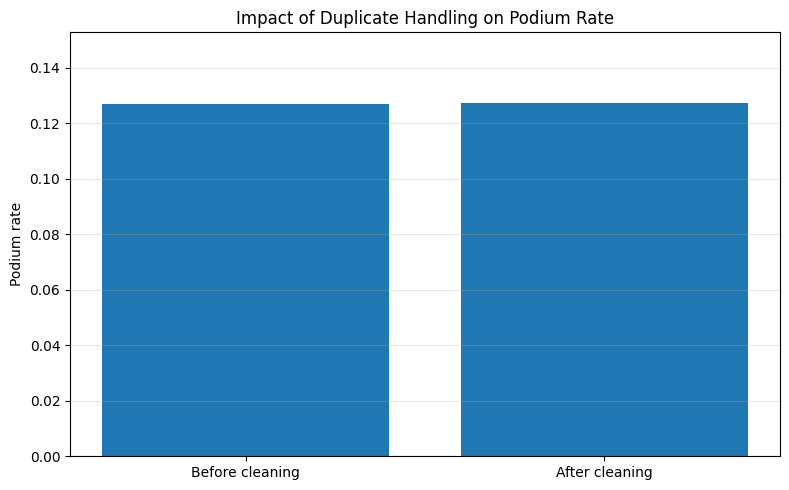

In [22]:
# ============================================================
# Before/after cleaning: podium-target impact
# ============================================================

# Create the cleaned result table before calculating the before/after impact.
# This keeps the cell safe under Run All while preserving the original plot.
results_clean = (
    results
    .sort_values(["positionOrder", "resultId"], na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)


raw_podium = (
    results["positionOrder"].le(3).astype(int)
)

clean_podium = (
    results_clean["positionOrder"].le(3).astype(int)
)

cleaning_target_impact = pd.DataFrame({
    "Stage": ["Before cleaning", "After cleaning"],
    "Rows": [len(results), len(results_clean)],
    "Podium rows": [int(raw_podium.sum()), int(clean_podium.sum())],
    "Podium rate": [raw_podium.mean(), clean_podium.mean()]
})

display(
    cleaning_target_impact.assign(
        **{"Podium rate": cleaning_target_impact["Podium rate"].round(4)}
    )
)

plt.figure(figsize=(8, 5))
plt.bar(
    cleaning_target_impact["Stage"],
    cleaning_target_impact["Podium rate"]
)
plt.ylabel("Podium rate")
plt.title("Impact of Duplicate Handling on Podium Rate")
plt.ylim(0, max(cleaning_target_impact["Podium rate"]) * 1.2)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# Create one row per (raceId, driverId)
# using the best finishing result for historical duplicate entries.

results_clean = (
    results
    .sort_values(["positionOrder", "resultId"], na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)

print("Original results rows:", len(results))
print("Cleaned race-driver rows:", len(results_clean))

# Verify uniqueness
duplicate_check = results_clean.duplicated(
    subset=["raceId", "driverId"]
).sum()

print("Remaining duplicate (raceId, driverId) pairs:", duplicate_check)

Original results rows: 26759
Cleaned race-driver rows: 26668
Remaining duplicate (raceId, driverId) pairs: 0


Rows removed by duplicate handling: 91


,Stage,Result rows
0,Before cleaning,26759
1,After cleaning,26668


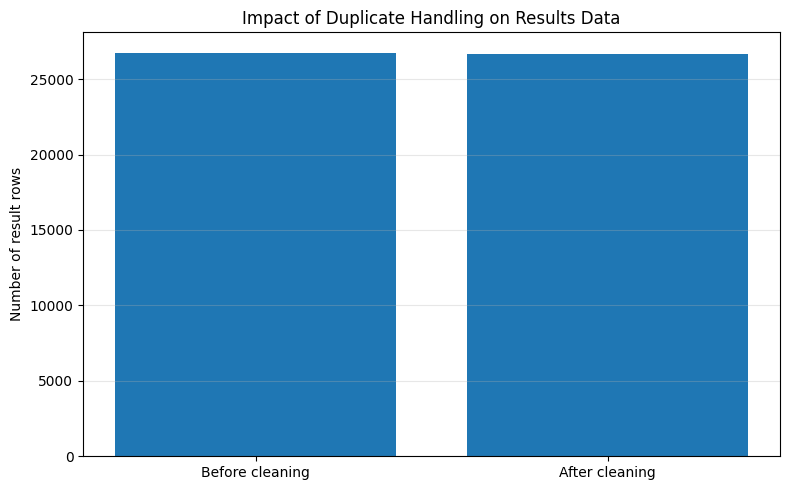

In [24]:
# ============================================================
# Before/after cleaning visualization
# ============================================================

cleaning_impact = pd.DataFrame({
    "Stage": ["Before cleaning", "After cleaning"],
    "Result rows": [len(results), len(results_clean)]
})

print(f"Rows removed by duplicate handling: {len(results) - len(results_clean):,}")

display(cleaning_impact)

plt.figure(figsize=(8, 5))
plt.bar(cleaning_impact["Stage"], cleaning_impact["Result rows"])
plt.ylabel("Number of result rows")
plt.title("Impact of Duplicate Handling on Results Data")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## CHECKPOINT 5 — Feature Selection

**Checklist items covered:** Leakage-safe form features using only past races, pre-race standings, the grid = 0 recode, and the final feature list in six groups plus context.

**Evidence:** Check prints below (e.g. 0 rows with more previous podiums than previous races, 0 round-1 rows with points), the standings correlations, the feature-effect plots in Checkpoint 3, and the 'Feature Selection and Pre-Race Validity' summary at the end.

---

## Leakage-Safe Modeling Table and Feature Engineering

In [25]:
# Clean results so there is exactly one row per (raceId, driverId)
# Keep the best finishing result when historical shared-drive cases occur.

results_clean = (
    results
    .sort_values(["positionOrder", "resultId"], na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)

print("Original results rows:", len(results))
print("Cleaned results rows:", len(results_clean))

print(
    "Duplicate (raceId, driverId) pairs remaining:",
    results_clean.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Original results rows: 26759
Cleaned results rows: 26668
Duplicate (raceId, driverId) pairs remaining: 0


In [26]:
model_base = (
    results_clean
    .merge(
        races[["raceId", "year", "round", "circuitId", "name"]],
        on="raceId",
        how="left"
    )
    .merge(
        qualifying[
            [
                "raceId",
                "driverId",
                "constructorId",
                "number",
                "position",
                "q1",
                "q2",
                "q3"
            ]
        ],
        on=["raceId", "driverId"],
        how="inner",
        suffixes=("_result", "_quali")
    )
)

print("model_base shape:", model_base.shape)
print("Year range:", model_base["year"].min(), "to", model_base["year"].max())
print("Unique races:", model_base["raceId"].nunique())
print("Unique drivers:", model_base["driverId"].nunique())
print(
    "Duplicate (raceId, driverId) pairs:",
    model_base.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

model_base shape: (10494, 28)
Year range: 1994 to 2024
Unique races: 494
Unique drivers: 172
Duplicate (raceId, driverId) pairs: 0


In [27]:
# Create the prediction target
model_base["podium"] = (
    model_base["positionOrder"] <= 3
).astype(int)

print("Podium distribution:")
print(model_base["podium"].value_counts())

print("\nPodium percentage:")
print(
    (model_base["podium"].value_counts(normalize=True) * 100)
    .round(2)
)

Podium distribution:
podium
0    9012
1    1482
Name: count, dtype: int64

Podium percentage:
podium
0    85.88
1    14.12
Name: proportion, dtype: float64


In [28]:
# Check whether the constructor from qualifying
# matches the constructor recorded in the race result.

constructor_check = (
    model_base["constructorId_result"]
    == model_base["constructorId_quali"]
)

print("Constructor agreement:")
print(constructor_check.mean() * 100)

print("\nConstructor mismatches:")
print((~constructor_check).sum())

Constructor agreement:
99.90470745187726

Constructor mismatches:
10


In [29]:
model = model_base.copy()

# Constructor known at prediction time
model["constructorId"] = model["constructorId_quali"]

# Qualifying position
model["qualifying_position"] = model["position_quali"]

print("Model shape:", model.shape)

print(
    "\nDuplicate (raceId, driverId) pairs:",
    model.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Model shape: (10494, 31)

Duplicate (raceId, driverId) pairs: 0


In [30]:
# Create one row per race in chronological order
race_order = (
    model[["raceId", "year", "round"]]
    .drop_duplicates()
    .sort_values(["year", "round"])
    .reset_index(drop=True)
)

# Assign chronological index
race_order["race_index"] = range(len(race_order))

# Merge the index back into the model
model = model.merge(
    race_order[["raceId", "race_index"]],
    on="raceId",
    how="left"
)

print("Number of unique races:", model["raceId"].nunique())
print("Minimum race_index:", model["race_index"].min())
print("Maximum race_index:", model["race_index"].max())
print(
    "Missing race_index:",
    model["race_index"].isna().sum()
)

print("\nDuplicate race IDs in race_order:")
print(
    race_order["raceId"].duplicated().sum()
)

Number of unique races: 494
Minimum race_index: 0
Maximum race_index: 493
Missing race_index: 0

Duplicate race IDs in race_order:
0


In [31]:
# Sort chronologically within each driver
model = model.sort_values(
    ["driverId", "race_index"]
).copy()

# Number of races the driver had BEFORE the current race
model["driver_previous_races"] = (
    model.groupby("driverId")
         .cumcount()
)

# Number of podiums the driver had BEFORE the current race
model["driver_previous_podiums"] = (
    model.groupby("driverId")["podium"]
         .transform(
             lambda x: x.shift(1).fillna(0).cumsum()
         )
)

# Historical podium rate
model["driver_previous_podium_rate"] = (
    model["driver_previous_podiums"]
    / model["driver_previous_races"].replace(0, np.nan)
).fillna(0)

print(
    "Rows where previous podiums > previous races:",
    (
        model["driver_previous_podiums"]
        > model["driver_previous_races"]
    ).sum()
)

print(
    "First driver observations with non-zero history:",
    (
        (model["driver_previous_races"] == 0)
        & (model["driver_previous_podiums"] != 0)
    ).sum()
)

print(
    "Rows with invalid podium rate:",
    (
        (model["driver_previous_podium_rate"] < 0)
        | (model["driver_previous_podium_rate"] > 1)
    ).sum()
)

Rows where previous podiums > previous races: 0
First driver observations with non-zero history: 0
Rows with invalid podium rate: 0


In [32]:
# Driver's average finishing position before the current race
model["driver_previous_avg_finish"] = (
    model.groupby("driverId")["positionOrder"]
         .transform(
             lambda x: x.shift(1).expanding().mean()
         )
).fillna(0)

print(
    "Missing previous average finish:",
    model["driver_previous_avg_finish"].isna().sum()
)

print("\nFirst observations for a few drivers:")
display(
    model[
        [
            "driverId",
            "race_index",
            "positionOrder",
            "driver_previous_avg_finish"
        ]
    ].head(15)
)

Missing previous average finish: 0

First observations for a few drivers:


,driverId,race_index,positionOrder,driver_previous_avg_finish
1006,1,137,3,0.000000
513,1,138,2,3.000000
514,1,139,2,2.500000
515,1,140,2,2.333333
516,1,141,2,2.250000
23,1,142,1,2.200000
24,1,143,1,2.000000
1013,1,144,3,1.857143
1014,1,145,3,2.000000
3974,1,146,9,2.111111


In [33]:
# Driver's average finishing position over the previous 5 races
model["driver_previous_5_avg_finish"] = (
    model.groupby("driverId")["positionOrder"]
         .transform(
             lambda x: x.shift(1).rolling(
                 window=5,
                 min_periods=1
             ).mean()
         )
).fillna(0)

print(
    "Missing previous-5 average finish:",
    model["driver_previous_5_avg_finish"].isna().sum()
)

print("\nSample:")
display(
    model[
        [
            "driverId",
            "race_index",
            "positionOrder",
            "driver_previous_5_avg_finish"
        ]
    ].head(15)
)

Missing previous-5 average finish: 0

Sample:


,driverId,race_index,positionOrder,driver_previous_5_avg_finish
1006,1,137,3,0.000000
513,1,138,2,3.000000
514,1,139,2,2.500000
515,1,140,2,2.333333
516,1,141,2,2.250000
23,1,142,1,2.200000
24,1,143,1,1.800000
1013,1,144,3,1.600000
1014,1,145,3,1.800000
3974,1,146,9,2.000000


In [34]:
check = (
    model
    .sort_values(["driverId", "race_index"])
    .groupby("driverId")["positionOrder"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).mean()
    )
    .fillna(0)
)

print(
    "Rows where previous-5 average does not match:",
    (
        ~np.isclose(
            model["driver_previous_5_avg_finish"].values,
            check.values
        )
    ).sum()
)

Rows where previous-5 average does not match: 0


In [35]:
# Create one row per constructor per race
constructor_race = (
    model[
        [
            "raceId",
            "race_index",
            "year",
            "round",
            "constructorId",
            "podium"
        ]
    ]
    .groupby(
        [
            "raceId",
            "race_index",
            "year",
            "round",
            "constructorId"
        ],
        as_index=False
    )
    .agg(
        constructor_podium=("podium", "max")
    )
)

print("Constructor-race rows:", len(constructor_race))

print(
    "Duplicate constructor-race combinations:",
    constructor_race.duplicated(
        subset=["raceId", "constructorId"]
    ).sum()
)

print("\nConstructor podium distribution:")
print(constructor_race["constructor_podium"].value_counts())

Constructor-race rows: 5263
Duplicate constructor-race combinations: 0

Constructor podium distribution:
constructor_podium
0    4082
1    1181
Name: count, dtype: int64


In [36]:
constructor_race = (
    constructor_race
    .sort_values(["constructorId", "race_index"])
    .copy()
)

# Number of races this constructor had BEFORE the current race
constructor_race["constructor_previous_races"] = (
    constructor_race
    .groupby("constructorId")
    .cumcount()
)

# Number of podiums BEFORE the current race
constructor_race["constructor_previous_podiums"] = (
    constructor_race
    .groupby("constructorId")["constructor_podium"]
    .transform(
        lambda x: x.shift(1).fillna(0).cumsum()
    )
)

# Historical podium rate
constructor_race["constructor_previous_podium_rate"] = (
    constructor_race["constructor_previous_podiums"]
    / constructor_race["constructor_previous_races"].replace(0, np.nan)
).fillna(0)

print(
    "Rows where previous podiums > previous races:",
    (
        constructor_race["constructor_previous_podiums"]
        > constructor_race["constructor_previous_races"]
    ).sum()
)

print(
    "First constructor observations with non-zero history:",
    (
        (constructor_race["constructor_previous_races"] == 0)
        & (constructor_race["constructor_previous_podiums"] != 0)
    ).sum()
)

print(
    "Rows with invalid historical podium rate:",
    (
        (constructor_race["constructor_previous_podium_rate"] < 0)
        | (constructor_race["constructor_previous_podium_rate"] > 1)
    ).sum()
)

Rows where previous podiums > previous races: 0
First constructor observations with non-zero history: 0
Rows with invalid historical podium rate: 0


In [37]:
constructor_history_features = constructor_race[
    [
        "raceId",
        "constructorId",
        "constructor_previous_races",
        "constructor_previous_podiums",
        "constructor_previous_podium_rate"
    ]
].copy()

model = model.merge(
    constructor_history_features,
    on=["raceId", "constructorId"],
    how="left"
)

print("Model shape:", model.shape)

print(
    "Missing constructor history:",
    model[
        [
            "constructor_previous_races",
            "constructor_previous_podiums",
            "constructor_previous_podium_rate"
        ]
    ].isna().sum().sum()
)

print(
    "Duplicate (raceId, driverId) pairs:",
    model.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Model shape: (10494, 40)
Missing constructor history: 0
Duplicate (raceId, driverId) pairs: 0


In [38]:
# Sort by driver, constructor, and chronological race order
model = model.sort_values(
    ["driverId", "constructorId", "race_index"]
).copy()

# Number of previous races for this driver with this constructor
model["driver_constructor_previous_races"] = (
    model.groupby(
        ["driverId", "constructorId"]
    ).cumcount()
)

# Number of previous podiums for this driver with this constructor
model["driver_constructor_previous_podiums"] = (
    model.groupby(
        ["driverId", "constructorId"]
    )["podium"]
    .transform(
        lambda x: x.shift(1).fillna(0).cumsum()
    )
)

# Historical podium rate for this driver-constructor combination
model["driver_constructor_previous_podium_rate"] = (
    model["driver_constructor_previous_podiums"]
    / model["driver_constructor_previous_races"].replace(0, np.nan)
).fillna(0)

print(
    "Rows where previous podiums > previous races:",
    (
        model["driver_constructor_previous_podiums"]
        > model["driver_constructor_previous_races"]
    ).sum()
)

print(
    "First driver-constructor observations with non-zero history:",
    (
        (model["driver_constructor_previous_races"] == 0)
        & (model["driver_constructor_previous_podiums"] != 0)
    ).sum()
)

print(
    "Rows with invalid historical podium rate:",
    (
        (model["driver_constructor_previous_podium_rate"] < 0)
        | (model["driver_constructor_previous_podium_rate"] > 1)
    ).sum()
)

Rows where previous podiums > previous races: 0
First driver-constructor observations with non-zero history: 0
Rows with invalid historical podium rate: 0


In [39]:
model = (
    model
    .sort_values(["race_index", "driverId"])
    .reset_index(drop=True)
)

print("Model shape:", model.shape)

print(
    "Race index starts at:",
    model["race_index"].min()
)

print(
    "Race index ends at:",
    model["race_index"].max()
)

print(
    "Duplicate (raceId, driverId) pairs:",
    model.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Model shape: (10494, 43)
Race index starts at: 0
Race index ends at: 493
Duplicate (raceId, driverId) pairs: 0


In [40]:
model = (
    model
    .merge(
        drivers[["driverId", "dob"]],
        on="driverId",
        how="left"
    )
    .merge(
        races[["raceId", "date"]],
        on="raceId",
        how="left"
    )
)

print("Model shape:", model.shape)

print(
    "Missing driver DOB:",
    model["dob"].isna().sum()
)

print(
    "Missing race date:",
    model["date"].isna().sum()
)

Model shape: (10494, 45)
Missing driver DOB: 0
Missing race date: 0


In [41]:
# Convert dates to datetime
model["dob"] = pd.to_datetime(model["dob"])
model["date"] = pd.to_datetime(model["date"])

# Calculate driver's age at the race date
model["driver_age"] = (
    (model["date"] - model["dob"]).dt.days / 365.25
).round(2)

print("Missing driver age:", model["driver_age"].isna().sum())

print(
    "Minimum driver age:",
    model["driver_age"].min()
)

print(
    "Maximum driver age:",
    model["driver_age"].max()
)

print(
    "Ages below 15:",
    (model["driver_age"] < 15).sum()
)

print(
    "Ages above 60:",
    (model["driver_age"] > 60).sum()
)

Missing driver age: 0
Minimum driver age: 17.45
Maximum driver age: 43.89
Ages below 15: 0
Ages above 60: 0


In [42]:
print("Drivers nationality:")
display(
    drivers[["driverId", "nationality"]].head(15)
)

print("\nCircuits country:")
display(
    circuits[["circuitId", "country"]].head(15)
)

Drivers nationality:


,driverId,nationality
0,1,British
1,2,German
2,3,German
3,4,Spanish
4,5,Finnish
5,6,Japanese
6,7,French
7,8,Finnish
8,9,Polish
9,10,German



Circuits country:


,circuitId,country
0,1,Australia
1,2,Malaysia
2,3,Bahrain
3,4,Spain
4,5,Turkey
5,6,Monaco
6,7,Canada
7,8,France
8,9,UK
9,10,Germany


In [43]:
print("Unique driver nationalities:")
print(sorted(drivers["nationality"].dropna().unique()))

print("\nUnique circuit countries:")
print(sorted(circuits["country"].dropna().unique()))

Unique driver nationalities:
['American', 'American-Italian', 'Argentine', 'Argentine-Italian', 'Argentinian ', 'Australian', 'Austrian', 'Belgian', 'Brazilian', 'British', 'Canadian', 'Chilean', 'Chinese', 'Colombian', 'Czech', 'Danish', 'Dutch', 'East German', 'Finnish', 'French', 'German', 'Hungarian', 'Indian', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Liechtensteiner', 'Malaysian', 'Mexican', 'Monegasque', 'New Zealander', 'Polish', 'Portuguese', 'Rhodesian', 'Russian', 'South African', 'Spanish', 'Swedish', 'Swiss', 'Thai', 'Uruguayan', 'Venezuelan']

Unique circuit countries:
['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'USA', 'United States']


In [44]:
nationality_to_country = {
    "American": "United States",
    "Argentine": "Argentina",
    "Argentinian ": "Argentina",
    "Australian": "Australia",
    "Austrian": "Austria",
    "Belgian": "Belgium",
    "Brazilian": "Brazil",
    "British": "UK",
    "Canadian": "Canada",
    "Chilean": "Chile",
    "Chinese": "China",
    "Colombian": "Colombia",
    "Czech": "Czech Republic",
    "Danish": "Denmark",
    "Dutch": "Netherlands",
    "Finnish": "Finland",
    "French": "France",
    "German": "Germany",
    "Hungarian": "Hungary",
    "Indian": "India",
    "Indonesian": "Indonesia",
    "Irish": "Ireland",
    "Italian": "Italy",
    "Japanese": "Japan",
    "Liechtensteiner": "Liechtenstein",
    "Malaysian": "Malaysia",
    "Mexican": "Mexico",
    "Monegasque": "Monaco",
    "New Zealander": "New Zealand",
    "Polish": "Poland",
    "Portuguese": "Portugal",
    "Rhodesian": "Rhodesia",
    "Russian": "Russia",
    "South African": "South Africa",
    "Spanish": "Spain",
    "Swedish": "Sweden",
    "Swiss": "Switzerland",
    "Thai": "Thailand",
    "Uruguayan": "Uruguay",
    "Venezuelan": "Venezuela"
}

print("Mapping created:", len(nationality_to_country), "entries")

Mapping created: 40 entries


In [45]:
unmapped_nationalities = sorted(
    set(drivers["nationality"].dropna().unique())
    - set(nationality_to_country.keys())
)

print("Unmapped nationalities:")
print(unmapped_nationalities)

Unmapped nationalities:
['American-Italian', 'Argentine-Italian', 'East German']


In [46]:
# Normalize circuit country naming
circuit_country_normalized = circuits["country"].replace({
    "USA": "United States"
})

print("Unique normalized circuit countries:")
print(sorted(circuit_country_normalized.dropna().unique()))

Unique normalized circuit countries:
['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'United States']


In [47]:
# Add normalized driver country
model["driver_country"] = model["driverId"].map(
    drivers.set_index("driverId")["nationality"].map(
        nationality_to_country
    )
)

# Add normalized circuit country
model["circuit_country"] = model["circuitId"].map(
    circuits.set_index("circuitId")["country"].replace({
        "USA": "United States"
    })
)

# Home race indicator
model["home_race"] = (
    model["driver_country"] == model["circuit_country"]
).astype(int)

print("Home races:", model["home_race"].sum())
print("Non-home races:", (model["home_race"] == 0).sum())
print("Missing driver country:", model["driver_country"].isna().sum())
print("Missing circuit country:", model["circuit_country"].isna().sum())

Home races: 479
Non-home races: 10015
Missing driver country: 0
Missing circuit country: 0


In [48]:
display(
    model.loc[
        model["home_race"] == 1,
        [
            "year",
            "round",
            "driverId",
            "driver_country",
            "circuitId",
            "circuit_country",
            "home_race"
        ]
    ].head(20)
)

,year,round,driverId,driver_country,circuitId,circuit_country,home_race
0,1994,1,22,Brazil,18,Brazil,1
21,1994,1,102,Brazil,18,Brazil,1
23,1994,1,104,Brazil,18,Brazil,1
36,1994,2,79,Japan,28,Japan,1
41,1994,2,88,Japan,28,Japan,1
60,1994,3,78,Italy,21,Italy,1
62,1994,3,81,Italy,21,Italy,1
68,1994,3,94,Italy,21,Italy,1
74,1994,3,105,Italy,21,Italy,1
79,1994,3,110,Italy,21,Italy,1


In [49]:
print("Qualifying columns:")
print(
    model[
        [
            "qualifying_position",
            "q1",
            "q2",
            "q3",
            "grid"
        ]
    ].isna().sum()
)

print("\nData types:")
print(
    model[
        [
            "qualifying_position",
            "q1",
            "q2",
            "q3",
            "grid"
        ]
    ].dtypes
)

Qualifying columns:
qualifying_position       0
q1                      156
q2                     4647
q3                     6865
grid                      0
dtype: int64

Data types:
qualifying_position     int64
q1                     object
q2                     object
q3                     object
grid                    int64
dtype: object


In [50]:
display(
    model[
        [
            "qualifying_position",
            "q1",
            "q2",
            "q3"
        ]
    ].head(20)
)

,qualifying_position,q1,q2,q3
0,14,1:18.414,NaN,NaN
1,2,1:16.290,NaN,NaN
2,19,1:19.304,NaN,NaN
3,5,1:17.806,NaN,NaN
4,9,1:18.183,NaN,NaN
5,3,1:17.385,NaN,NaN
6,16,1:18.751,NaN,NaN
7,8,1:18.122,NaN,NaN
8,21,1:19.483,NaN,NaN
9,4,1:17.554,NaN,NaN


In [51]:
def qualifying_time_to_seconds(value):
    if pd.isna(value):
        return np.nan

    minutes, seconds = str(value).split(":")
    return int(minutes) * 60 + float(seconds)


for col in ["q1", "q2", "q3"]:
    model[col + "_seconds"] = model[col].apply(
        qualifying_time_to_seconds
    )

display(
    model[
        [
            "q1", "q1_seconds",
            "q2", "q2_seconds",
            "q3", "q3_seconds"
        ]
    ].head(20)
)

,q1,q1_seconds,q2,q2_seconds,q3,q3_seconds
0,1:18.414,78.414,NaN,NaN,NaN,NaN
1,1:16.290,76.290,NaN,NaN,NaN,NaN
2,1:19.304,79.304,NaN,NaN,NaN,NaN
3,1:17.806,77.806,NaN,NaN,NaN,NaN
4,1:18.183,78.183,NaN,NaN,NaN,NaN
5,1:17.385,77.385,NaN,NaN,NaN,NaN
6,1:18.751,78.751,NaN,NaN,NaN,NaN
7,1:18.122,78.122,NaN,NaN,NaN,NaN
8,1:19.483,79.483,NaN,NaN,NaN,NaN
9,1:17.554,77.554,NaN,NaN,NaN,NaN


In [52]:
for col in ["q1_seconds", "q2_seconds", "q3_seconds"]:
    print(f"\n{col}")
    print("Missing:", model[col].isna().sum())
    print("Minimum:", model[col].min())
    print("Maximum:", model[col].max())
    print("Invalid <= 0:", (model[col].dropna() <= 0).sum())


q1_seconds
Missing: 156
Minimum: 53.904
Maximum: 1002.64
Invalid <= 0: 0

q2_seconds
Missing: 4647
Minimum: 53.647
Maximum: 132.47
Invalid <= 0: 0

q3_seconds
Missing: 6865
Minimum: 53.377
Maximum: 129.776
Invalid <= 0: 0


In [53]:
print("Minimum qualifying position:", model["qualifying_position"].min())
print("Maximum qualifying position:", model["qualifying_position"].max())

print("\nInvalid positions <= 0:")
print((model["qualifying_position"] <= 0).sum())

print("\nQualifying position distribution:")
display(
    model["qualifying_position"]
    .value_counts()
    .sort_index()
    .head(30)
)

Minimum qualifying position: 1
Maximum qualifying position: 28

Invalid positions <= 0:
0

Qualifying position distribution:


qualifying_position
1     494
2     494
3     494
4     494
5     494
6     494
7     494
8     494
9     494
10    494
11    494
12    494
13    494
14    494
15    494
16    494
17    494
18    494
19    487
20    479
21    215
22    207
23     90
24     82
25     20
26     20
27      1
28      1
Name: count, dtype: int64

In [54]:
print("Minimum grid:", model["grid"].min())
print("Maximum grid:", model["grid"].max())

print("\nInvalid grid < 0:")
print((model["grid"] < 0).sum())

print("\nGrid = 0:")
print((model["grid"] == 0).sum())

print("\nMissing grid:")
print(model["grid"].isna().sum())

print("\nGrid distribution:")
display(
    model["grid"]
    .value_counts()
    .sort_index()
    .head(30)
)

Minimum grid: 0
Maximum grid: 26

Invalid grid < 0:
0

Grid = 0:
87

Missing grid:
0

Grid distribution:


grid
0      87
1     494
2     492
3     494
4     494
5     494
6     494
7     493
8     493
9     494
10    492
11    492
12    493
13    493
14    493
15    492
16    492
17    496
18    488
19    478
20    432
21    213
22    206
23     86
24     80
25     20
26     19
Name: count, dtype: int64

In [55]:
grid_difference = (
    model["qualifying_position"] != model["grid"]
)

print("Rows where qualifying position != grid:",
      grid_difference.sum())

print("Percentage:",
      round(grid_difference.mean() * 100, 2), "%")

Rows where qualifying position != grid: 2509
Percentage: 23.91 %


In [56]:
print("Circuit columns:")
print(circuits.columns.tolist())

print("\nCircuit sample:")
display(circuits.head())

Circuit columns:
['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']

Circuit sample:


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [57]:
circuit_numeric = circuits[
    ["lat", "lng", "alt"]
].copy()

print("Missing values:")
print(circuit_numeric.isna().sum())

print("\nMinimum values:")
print(circuit_numeric.min())

print("\nMaximum values:")
print(circuit_numeric.max())

Missing values:
lat    0
lng    0
alt    0
dtype: int64

Minimum values:
lat    -37.8497
lng   -118.1890
alt     -7.0000
dtype: float64

Maximum values:
lat      57.2653
lng     144.9680
alt    2227.0000
dtype: float64


In [58]:
# Add circuit characteristics to the modeling dataset
circuit_features = circuits[
    ["circuitId", "lat", "lng", "alt"]
].copy()

model = model.merge(
    circuit_features,
    on="circuitId",
    how="left"
)

print("Model shape:", model.shape)

print("\nMissing circuit features:")
print(
    model[["lat", "lng", "alt"]].isna().sum()
)

Model shape: (10494, 55)

Missing circuit features:
lat    0
lng    0
alt    0
dtype: int64


In [59]:
print("Model shape:", model.shape)

print(
    "Duplicate (raceId, driverId) pairs:",
    model.duplicated(["raceId", "driverId"]).sum()
)

print(
    "Missing lat/lng/alt:",
    model[["lat", "lng", "alt"]].isna().sum().to_dict()
)

Model shape: (10494, 55)
Duplicate (raceId, driverId) pairs: 0
Missing lat/lng/alt: {'lat': 0, 'lng': 0, 'alt': 0}


In [60]:
print("Number of columns:", len(model.columns))

for i, col in enumerate(model.columns, start=1):
    print(f"{i:2d}. {col}")

Number of columns: 55
 1. resultId
 2. raceId
 3. driverId
 4. constructorId_result
 5. number_result
 6. grid
 7. position_result
 8. positionText
 9. positionOrder
10. points
11. laps
12. time
13. milliseconds
14. fastestLap
15. rank
16. fastestLapTime
17. fastestLapSpeed
18. statusId
19. year
20. round
21. circuitId
22. name
23. constructorId_quali
24. number_quali
25. position_quali
26. q1
27. q2
28. q3
29. podium
30. constructorId
31. qualifying_position
32. race_index
33. driver_previous_races
34. driver_previous_podiums
35. driver_previous_podium_rate
36. driver_previous_avg_finish
37. driver_previous_5_avg_finish
38. constructor_previous_races
39. constructor_previous_podiums
40. constructor_previous_podium_rate
41. driver_constructor_previous_races
42. driver_constructor_previous_podiums
43. driver_constructor_previous_podium_rate
44. dob
45. date
46. driver_age
47. driver_country
48. circuit_country
49. home_race
50. q1_seconds
51. q2_seconds
52. q3_seconds
53. lat
54. lng
55

In [61]:
feature_columns = [
    # Group 1: Qualifying / Starting Position
    "grid",
    "qualifying_position",
    "q1_seconds",
    "q2_seconds",
    "q3_seconds",

    # Group 2: Driver History
    "driver_previous_races",
    "driver_previous_podiums",
    "driver_previous_podium_rate",
    "driver_previous_avg_finish",
    "driver_previous_5_avg_finish",
    "driver_age",

    # Group 3: Constructor Strength
    "constructor_previous_races",
    "constructor_previous_podiums",
    "constructor_previous_podium_rate",

    # Group 4: Driver–Constructor History
    "driver_constructor_previous_races",
    "driver_constructor_previous_podiums",
    "driver_constructor_previous_podium_rate",

    # Group 5: Race / Circuit Context
    "year",
    "round",
    "circuitId",
    "home_race",
    "lat",
    "lng",
    "alt"
]

print("Number of candidate features:", len(feature_columns))

print("\nCandidate features:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2d}. {feature}")

Number of candidate features: 24

Candidate features:
 1. grid
 2. qualifying_position
 3. q1_seconds
 4. q2_seconds
 5. q3_seconds
 6. driver_previous_races
 7. driver_previous_podiums
 8. driver_previous_podium_rate
 9. driver_previous_avg_finish
10. driver_previous_5_avg_finish
11. driver_age
12. constructor_previous_races
13. constructor_previous_podiums
14. constructor_previous_podium_rate
15. driver_constructor_previous_races
16. driver_constructor_previous_podiums
17. driver_constructor_previous_podium_rate
18. year
19. round
20. circuitId
21. home_race
22. lat
23. lng
24. alt


In [62]:
print("Missing values:")
print(model[feature_columns].isna().sum())

print("\nData types:")
print(model[feature_columns].dtypes)

print("\nQ1 values above 200 seconds:")
print(
    model.loc[
        model["q1_seconds"] > 200,
        ["year", "round", "driverId", "q1", "q1_seconds"]
    ].sort_values(["year", "round"])
)

Missing values:
grid                                          0
qualifying_position                           0
q1_seconds                                  156
q2_seconds                                 4647
q3_seconds                                 6865
driver_previous_races                         0
driver_previous_podiums                       0
driver_previous_podium_rate                   0
driver_previous_avg_finish                    0
driver_previous_5_avg_finish                  0
driver_age                                    0
constructor_previous_races                    0
constructor_previous_podiums                  0
constructor_previous_podium_rate              0
driver_constructor_previous_races             0
driver_constructor_previous_podiums           0
driver_constructor_previous_podium_rate       0
year                                          0
round                                         0
circuitId                                     0
home_race               

---
## CHECKPOINT 7 — Dataset Splitting

**Checklist items covered:** Proper dataset splitting for training, validation and testing (chronological: train 1994–2019, validation 2020–2021, test 2022–2024).

**Evidence:** The split table and justification below, and the printed split sizes and podium rates (8,356 / 779 / 1,359 rows).

---

### Chronological Train / Validation / Test Split

| Set | Seasons | Rows | Podium rate |
|---|---|---|---|
| Train | 1994–2019 | 8,356 | 13.9% |
| Validation | 2020–2021 | 779 | 15.0% |
| Test | 2022–2024 | 1,359 | 15.0% |

**Why split by season instead of randomly:**
- The model is meant to predict *future* races from past ones. A random split would put races from
  2023 into training and races from 2010 into testing, so the model would learn from the future.
- The form features (previous podiums, previous average finish, standings) build on earlier
  races. A season split keeps every validation and test race strictly after all training races.

**Why these boundaries:**
- **Start in 1994:** `qualifying.csv` begins in 1994. Qualifying position and lap times are core
  features, so earlier seasons cannot be used without inventing qualifying data.
- **Validation 2020–2021:** the last two seasons of the turbo-hybrid era. They are used to choose
  thresholds and compare models without touching the test set.
- **Test 2022–2024:** the newest seasons and a new technical era (ground-effect cars). This is a
  strict, honest test of how the model handles rule changes it never saw.

In [63]:
train = model[model["year"] <= 2019].copy()

validation = model[
    (model["year"] >= 2020) &
    (model["year"] <= 2021)
].copy()

test = model[model["year"] >= 2022].copy()

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

print("\nTrain years:", train["year"].min(), "to", train["year"].max())
print("Validation years:", validation["year"].min(), "to", validation["year"].max())
print("Test years:", test["year"].min(), "to", test["year"].max())

print("\nTrain podium rate:", train["podium"].mean())
print("Validation podium rate:", validation["podium"].mean())
print("Test podium rate:", test["podium"].mean())

print("\nUnique races:")
print("Train:", train["raceId"].nunique())
print("Validation:", validation["raceId"].nunique())
print("Test:", test["raceId"].nunique())

Train shape: (8356, 55)
Validation shape: (779, 55)
Test shape: (1359, 55)

Train years: 1994 to 2019
Validation years: 2020 to 2021
Test years: 2022 to 2024

Train podium rate: 0.13894207754906654
Validation podium rate: 0.15019255455712452
Test podium rate: 0.15011037527593818

Unique races:
Train: 387
Validation: 39
Test: 68


In [64]:
qualifying_missing_by_year = (
    model
    .groupby("year")
    [["q1_seconds", "q2_seconds", "q3_seconds"]]
    .apply(lambda x: x.isna().mean())
    .round(3)
)

print(qualifying_missing_by_year.to_string())

      q1_seconds  q2_seconds  q3_seconds
year                                    
1994       0.003       1.000       1.000
1995       0.057       1.000       1.000
1996       0.020       1.000       1.000
1997       0.005       1.000       1.000
1998       0.013       1.000       1.000
1999       0.015       1.000       1.000
2000       0.000       1.000       1.000
2001       0.000       1.000       1.000
2002       0.000       1.000       1.000
2003       0.034       1.000       1.000
2004       0.058       1.000       1.000
2005       0.045       0.715       1.000
2006       0.020       0.283       0.556
2007       0.005       0.289       0.548
2008       0.005       0.266       0.522
2009       0.003       0.262       0.509
2010       0.009       0.294       0.583
2011       0.011       0.294       0.628
2012       0.000       0.292       0.607
2013       0.005       0.275       0.562
2014       0.017       0.281       0.546
2015       0.008       0.254       0.527
2016       0.007

In [65]:
history_columns = [
    "driver_previous_races",
    "constructor_previous_races",
    "driver_constructor_previous_races"
]

print("Rows with no driver history:",
      (model["driver_previous_races"] == 0).sum())

print("Rows with no constructor history:",
      (model["constructor_previous_races"] == 0).sum())

print("Rows with no driver-constructor history:",
      (model["driver_constructor_previous_races"] == 0).sum())

Rows with no driver history: 172
Rows with no constructor history: 91
Rows with no driver-constructor history: 392


In [66]:
history_features = [
    "driver_previous_avg_finish",
    "driver_previous_5_avg_finish",
    "driver_previous_podium_rate",
    "constructor_previous_podium_rate",
    "driver_constructor_previous_podium_rate"
]

for col in history_features:
    print(f"\n{col}")
    print("  Zero values:", (model[col] == 0).sum())
    print("  Non-zero values:", (model[col] != 0).sum())


driver_previous_avg_finish
  Zero values: 172
  Non-zero values: 10322

driver_previous_5_avg_finish
  Zero values: 172
  Non-zero values: 10322

driver_previous_podium_rate
  Zero values: 3845
  Non-zero values: 6649

constructor_previous_podium_rate
  Zero values: 2570
  Non-zero values: 7924

driver_constructor_previous_podium_rate
  Zero values: 5605
  Non-zero values: 4889


In [67]:
print("\nRows with zero previous driver races:")
print(
    model.loc[
        model["driver_previous_races"] == 0,
        [
            "year",
            "raceId",
            "driverId",
            "driver_previous_races",
            "driver_previous_avg_finish",
            "driver_previous_5_avg_finish",
            "driver_previous_podium_rate"
        ]
    ].head(10)
)


Rows with zero previous driver races:
   year  raceId  driverId  driver_previous_races  driver_previous_avg_finish  \
0  1994     257        22                      0                         0.0   
1  1994     257        30                      0                         0.0   
2  1994     257        44                      0                         0.0   
3  1994     257        49                      0                         0.0   
4  1994     257        50                      0                         0.0   
5  1994     257        55                      0                         0.0   
6  1994     257        56                      0                         0.0   
7  1994     257        57                      0                         0.0   
8  1994     257        65                      0                         0.0   
9  1994     257        71                      0                         0.0   

   driver_previous_5_avg_finish  driver_previous_podium_rate  
0                

In [68]:
model["driver_has_history"] = (
    model["driver_previous_races"] > 0
).astype(int)

model["constructor_has_history"] = (
    model["constructor_previous_races"] > 0
).astype(int)

model["driver_constructor_has_history"] = (
    model["driver_constructor_previous_races"] > 0
).astype(int)

print("Driver has history:")
print(model["driver_has_history"].value_counts().sort_index())

print("\nConstructor has history:")
print(model["constructor_has_history"].value_counts().sort_index())

print("\nDriver-constructor has history:")
print(model["driver_constructor_has_history"].value_counts().sort_index())

Driver has history:
driver_has_history
0      172
1    10322
Name: count, dtype: int64

Constructor has history:
constructor_has_history
0       91
1    10403
Name: count, dtype: int64

Driver-constructor has history:
driver_constructor_has_history
0      392
1    10102
Name: count, dtype: int64


In [69]:
model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_avg_finish"
] = np.nan

model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_5_avg_finish"
] = np.nan

In [70]:
print(
    "Missing driver_previous_avg_finish:",
    model["driver_previous_avg_finish"].isna().sum()
)

print(
    "Missing driver_previous_5_avg_finish:",
    model["driver_previous_5_avg_finish"].isna().sum()
)

print(
    "\nAverage finish for drivers with history:",
    model.loc[
        model["driver_previous_races"] > 0,
        "driver_previous_avg_finish"
    ].describe()
)

Missing driver_previous_avg_finish: 172
Missing driver_previous_5_avg_finish: 172

Average finish for drivers with history: count    10322.000000
mean        11.336576
std          3.404844
min          1.000000
25%          8.920833
50%         11.200000
75%         13.583214
max         28.000000
Name: driver_previous_avg_finish, dtype: float64


In [71]:
# Fix the artificial 0 placeholders for "no previous history"

model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_avg_finish"
] = np.nan

model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_5_avg_finish"
] = np.nan


# Verify the correction
print("Missing driver_previous_avg_finish:",
      model["driver_previous_avg_finish"].isna().sum())

print("Missing driver_previous_5_avg_finish:",
      model["driver_previous_5_avg_finish"].isna().sum())

Missing driver_previous_avg_finish: 172
Missing driver_previous_5_avg_finish: 172


### Pre-Race Championship Standings (leakage-safe)

`driver_standings` and `constructor_standings` store the championship table **after** each race.
Using the current race's row would leak its result. Instead, each race is matched with the
standings after the **previous round of the same season**, which is exactly what is known before
the lights go out. In round 1 nobody has scored yet, so points start at 0.

In [72]:
# ============================================================
# Pre-race standings: championship table after the PREVIOUS round
# ============================================================

# For each race, find the raceId of the previous round in the same season.
race_rounds = races[["raceId", "year", "round"]].sort_values(["year", "round"]).copy()
race_rounds["previous_raceId"] = race_rounds.groupby("year")["raceId"].shift(1)

model = model.merge(
    race_rounds[["raceId", "previous_raceId"]],
    on="raceId",
    how="left"
)

# Standings after the previous round, renamed so they join on previous_raceId.
driver_before = driver_standings[["raceId", "driverId", "points", "position"]].rename(columns={
    "raceId": "previous_raceId",
    "points": "driver_standing_points_before",
    "position": "driver_standing_position_before"
})
constructor_before = constructor_standings[["raceId", "constructorId", "points", "position"]].rename(columns={
    "raceId": "previous_raceId",
    "points": "constructor_standing_points_before",
    "position": "constructor_standing_position_before"
})

# Use the same number type on both sides of the join (previous_raceId has NaN in round 1).
driver_before["previous_raceId"] = driver_before["previous_raceId"].astype(float)
constructor_before["previous_raceId"] = constructor_before["previous_raceId"].astype(float)

rows_before = len(model)
model = model.merge(driver_before, on=["previous_raceId", "driverId"], how="left")
model = model.merge(constructor_before, on=["previous_raceId", "constructorId"], how="left")

# No earlier standing (round 1, or first race of the season for this driver/team)
# means 0 points so far. Missing positions are filled later by the training median.
model["driver_standing_points_before"] = model["driver_standing_points_before"].fillna(0)
model["constructor_standing_points_before"] = model["constructor_standing_points_before"].fillna(0)

print("Rows before / after the join:", rows_before, "/", len(model))
print("Duplicate (raceId, driverId) pairs:", model.duplicated(["raceId", "driverId"]).sum())
print("Round-1 rows with points before the race (must be 0):",
      ((model["round"] == 1) & (model["driver_standing_points_before"] > 0)).sum())
print("Missing standing positions:", model["driver_standing_position_before"].isna().sum(),
      "(driver),", model["constructor_standing_position_before"].isna().sum(), "(constructor)")
print("Correlation with podium:")
print(model[["podium", "driver_standing_points_before", "driver_standing_position_before",
             "constructor_standing_points_before", "constructor_standing_position_before"]]
      .corr()["podium"].round(3))

Rows before / after the join: 10494 / 10494
Duplicate (raceId, driverId) pairs: 0
Round-1 rows with points before the race (must be 0): 0
Missing standing positions: 952 (driver), 736 (constructor)
Correlation with podium:
podium                                  1.000
driver_standing_points_before           0.403
driver_standing_position_before        -0.446
constructor_standing_points_before      0.382
constructor_standing_position_before   -0.437
Name: podium, dtype: float64


In [73]:
# Recreate the chronological splits after the feature correction

train = model[model["year"] <= 2019].copy()

validation = model[
    (model["year"] >= 2020) &
    (model["year"] <= 2021)
].copy()

test = model[model["year"] >= 2022].copy()

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

print("\nMissing historical averages:")
print("Train:")
print(
    train[
        ["driver_previous_avg_finish",
         "driver_previous_5_avg_finish"]
    ].isna().sum()
)

print("\nValidation:")
print(
    validation[
        ["driver_previous_avg_finish",
         "driver_previous_5_avg_finish"]
    ].isna().sum()
)

print("\nTest:")
print(
    test[
        ["driver_previous_avg_finish",
         "driver_previous_5_avg_finish"]
    ].isna().sum()
)

Train shape: (8356, 63)
Validation shape: (779, 63)
Test shape: (1359, 63)

Missing historical averages:
Train:
driver_previous_avg_finish      158
driver_previous_5_avg_finish    158
dtype: int64

Validation:
driver_previous_avg_finish      6
driver_previous_5_avg_finish    6
dtype: int64

Test:
driver_previous_avg_finish      8
driver_previous_5_avg_finish    8
dtype: int64


In [74]:
feature_columns = [
    # Group 1: Qualifying / Starting Position
    "grid",
    "qualifying_position",
    "q1_seconds",
    "q2_seconds",
    "q3_seconds",

    # Group 2: Driver History
    "driver_previous_races",
    "driver_previous_podiums",
    "driver_previous_podium_rate",
    "driver_previous_avg_finish",
    "driver_previous_5_avg_finish",
    "driver_age",
    "driver_has_history",

    # Group 3: Constructor Strength
    "constructor_previous_races",
    "constructor_previous_podiums",
    "constructor_previous_podium_rate",
    "constructor_has_history",

    # Group 4: Driver–Constructor History
    "driver_constructor_previous_races",
    "driver_constructor_previous_podiums",
    "driver_constructor_previous_podium_rate",
    "driver_constructor_has_history",

    # Group 5: Race / Circuit Context
    "year",
    "round",
    "home_race",
    "lat",
    "lng",
    "alt",

    # Group 6: Pre-race championship standings (after the previous round)
    "driver_standing_points_before",
    "driver_standing_position_before",
    "constructor_standing_points_before",
    "constructor_standing_position_before"
]

print("Number of final candidate features:", len(feature_columns))

Number of final candidate features: 30


In [75]:
# Separate features (X) and target (y)

X_train = train[feature_columns].copy()
y_train = train["podium"].copy()

X_validation = validation[feature_columns].copy()
y_validation = validation["podium"].copy()

X_test = test[feature_columns].copy()
y_test = test["podium"].copy()

# Verify shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTarget distribution:")
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_validation.value_counts())

print("\nTest:")
print(y_test.value_counts())

X_train: (8356, 30)
y_train: (8356,)
X_validation: (779, 30)
y_validation: (779,)
X_test: (1359, 30)
y_test: (1359,)

Target distribution:
Train:
podium
0    7195
1    1161
Name: count, dtype: int64

Validation:
podium
0    662
1    117
Name: count, dtype: int64

Test:
podium
0    1155
1     204
Name: count, dtype: int64


In [76]:
# Check missing values in the final feature set

missing_summary = pd.DataFrame({
    "train_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
    "test_missing": X_test.isna().sum()
})

missing_summary = missing_summary[
    missing_summary.sum(axis=1) > 0
].sort_values(
    "train_missing",
    ascending=False
)

print(missing_summary)

                                      train_missing  validation_missing  \
q3_seconds                                     5772                 394   
q2_seconds                                     4096                 202   
driver_standing_position_before                 840                  44   
constructor_standing_position_before            636                  40   
driver_previous_5_avg_finish                    158                   6   
driver_previous_avg_finish                      158                   6   
q1_seconds                                      135                   8   

                                      test_missing  
q3_seconds                                     699  
q2_seconds                                     349  
driver_standing_position_before                 68  
constructor_standing_position_before            60  
driver_previous_5_avg_finish                     8  
driver_previous_avg_finish                       8  
q1_seconds                  

In [77]:
# Add missingness indicators for qualifying session times.
# 1 = qualifying time is missing
# 0 = qualifying time is available

for df in [X_train, X_validation, X_test]:
    df["q1_missing"] = df["q1_seconds"].isna().astype(int)
    df["q2_missing"] = df["q2_seconds"].isna().astype(int)
    df["q3_missing"] = df["q3_seconds"].isna().astype(int)

# Verify the indicators
print("Training missingness indicators:")
print(
    X_train[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nValidation missingness indicators:")
print(
    X_validation[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nTest missingness indicators:")
print(
    X_test[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nNew feature counts:")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

Training missingness indicators:
q1_missing     135
q2_missing    4096
q3_missing    5772
dtype: int64

Validation missingness indicators:
q1_missing      8
q2_missing    202
q3_missing    394
dtype: int64

Test missingness indicators:
q1_missing     13
q2_missing    349
q3_missing    699
dtype: int64

New feature counts:
X_train: (8356, 33)
X_validation: (779, 33)
X_test: (1359, 33)


In [78]:
# Recreate X and y after the notebook state reset

X_train = train[feature_columns].copy()
y_train = train["podium"].copy()

X_validation = validation[feature_columns].copy()
y_validation = validation["podium"].copy()

X_test = test[feature_columns].copy()
y_test = test["podium"].copy()

# Add missingness indicators for qualifying session times
# 1 = qualifying time is missing
# 0 = qualifying time is available

for df in [X_train, X_validation, X_test]:
    df["q1_missing"] = df["q1_seconds"].isna().astype(int)
    df["q2_missing"] = df["q2_seconds"].isna().astype(int)
    df["q3_missing"] = df["q3_seconds"].isna().astype(int)

    # grid = 0 means the car did not start from a grid slot (pit-lane start or
    # did not start). Flag it, then move it behind the last grid slot (30), so
    # the model does not read 0 as "better than pole position".
    df["did_not_start_from_grid"] = (df["grid"] == 0).astype(int)
    df.loc[df["grid"] == 0, "grid"] = 30

# Verify
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("\nTraining missingness indicators:")
print(
    X_train[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nValidation missingness indicators:")
print(
    X_validation[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nTest missingness indicators:")
print(
    X_test[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

X_train: (8356, 34)
X_validation: (779, 34)
X_test: (1359, 34)

Training missingness indicators:
q1_missing     135
q2_missing    4096
q3_missing    5772
dtype: int64

Validation missingness indicators:
q1_missing      8
q2_missing    202
q3_missing    394
dtype: int64

Test missingness indicators:
q1_missing     13
q2_missing    349
q3_missing    699
dtype: int64


## Data Pre-processing Setup

In [79]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Preprocessing pipeline:
# 1. Learn median values from training data
# 2. Fill missing values using those training medians
# 3. Standardize the features using training statistics

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created:")
print(preprocessor)

Preprocessing pipeline created:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [80]:
# Fit preprocessing ONLY on the training data
preprocessor.fit(X_train)

# Transform all datasets using the training-fitted preprocessing
X_train_processed = preprocessor.transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_validation_processed:", X_validation_processed.shape)
print("X_test_processed:", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Train:", np.isnan(X_train_processed).sum())
print("Validation:", np.isnan(X_validation_processed).sum())
print("Test:", np.isnan(X_test_processed).sum())

Processed shapes:
X_train_processed: (8356, 34)
X_validation_processed: (779, 34)
X_test_processed: (1359, 34)

Missing values after preprocessing:
Train: 0
Validation: 0
Test: 0


---
## CHECKPOINT 3 — Data Analysis

**Checklist items covered:** Data Analysis with plotted results (after cleaning), including plots of the effect of the features.

**Evidence:** Plots of the target balance, podium rate by year, by qualifying position and by grid position, driver and constructor history vs. podium, and Q1 lap-time distributions below.

---

## Exploratory Data Analysis (EDA) and Data Analysis

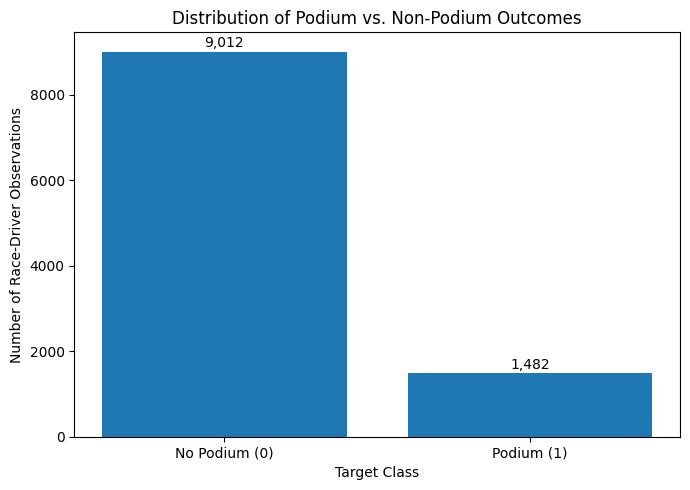

In [81]:
import matplotlib.pyplot as plt

# Target distribution
target_counts = model["podium"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Podium (0)", "Podium (1)"],
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Race-Driver Observations")
plt.title("Distribution of Podium vs. Non-Podium Outcomes")

for i, value in enumerate(target_counts.values):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

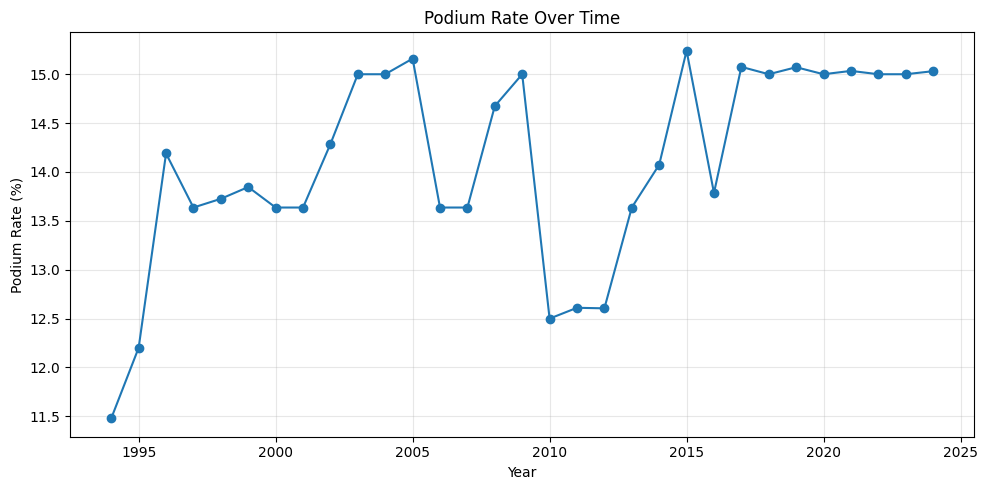

In [82]:
# Podium rate by year

podium_by_year = (
    model.groupby("year")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    podium_by_year["year"],
    podium_by_year["podium"] * 100,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate Over Time")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

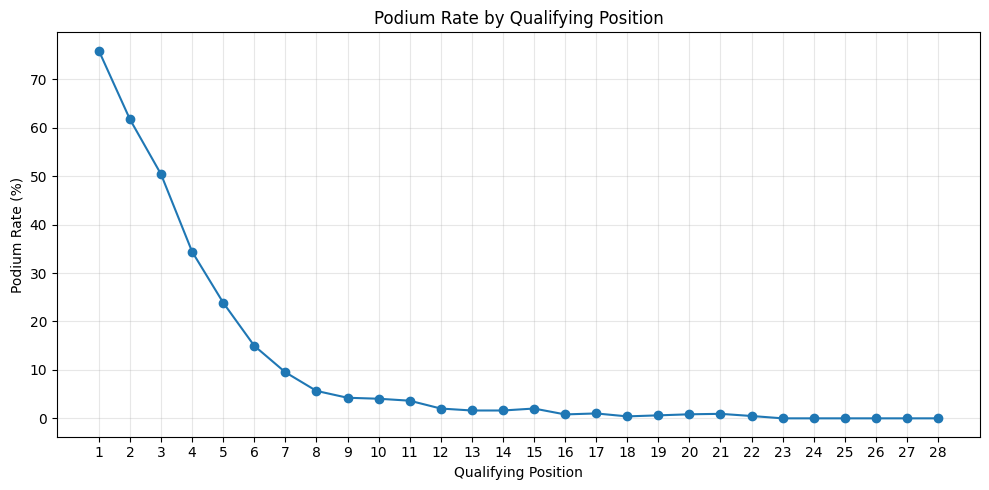

In [83]:
# Podium rate by qualifying position

qualifying_effect = (
    model.groupby("qualifying_position")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    qualifying_effect["qualifying_position"],
    qualifying_effect["podium"] * 100,
    marker="o"
)

plt.xlabel("Qualifying Position")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate by Qualifying Position")
plt.xticks(
    sorted(model["qualifying_position"].unique())
)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

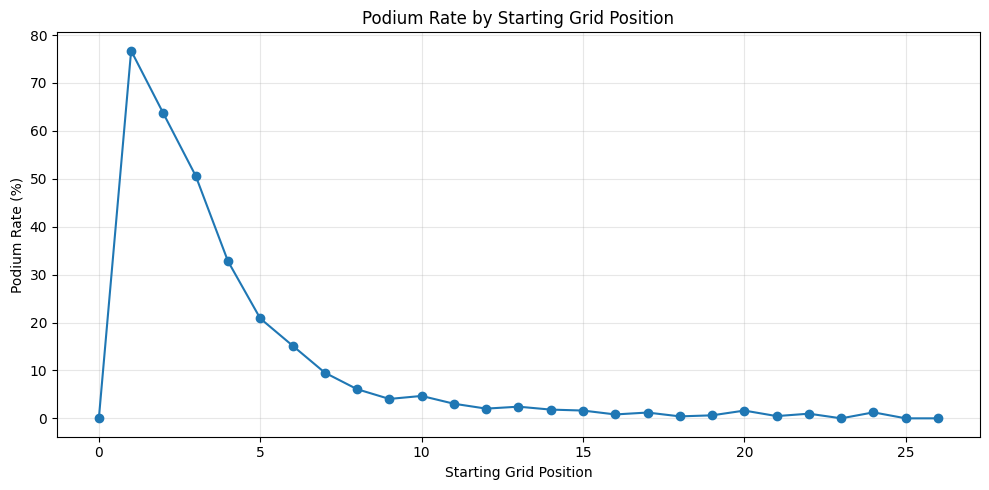

In [84]:
# Podium rate by actual starting grid position

grid_effect = (
    model.groupby("grid")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    grid_effect["grid"],
    grid_effect["podium"] * 100,
    marker="o"
)

plt.xlabel("Starting Grid Position")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate by Starting Grid Position")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

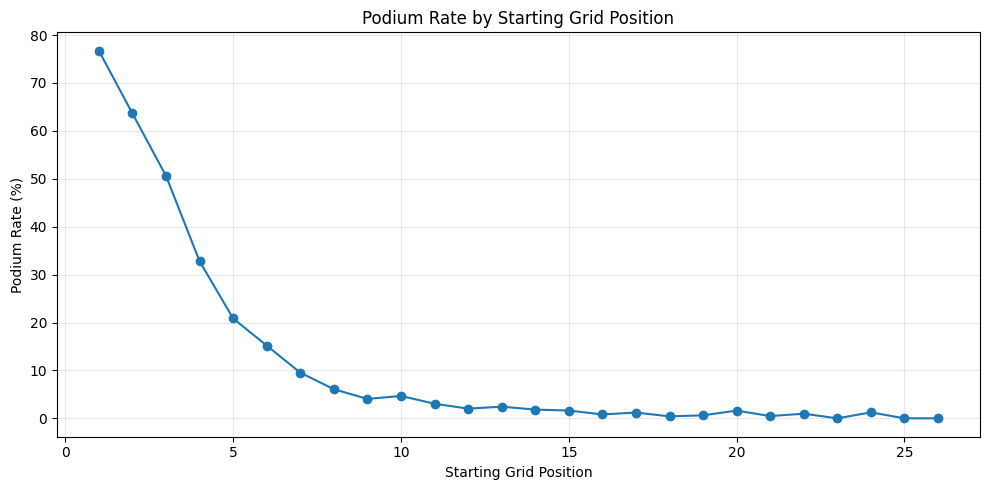

In [85]:
# Exclude the special grid=0 encoding from this visualization.
# This does NOT modify the underlying model data.

grid_effect = (
    model[model["grid"] > 0]
    .groupby("grid")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    grid_effect["grid"],
    grid_effect["podium"] * 100,
    marker="o"
)

plt.xlabel("Starting Grid Position")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate by Starting Grid Position")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

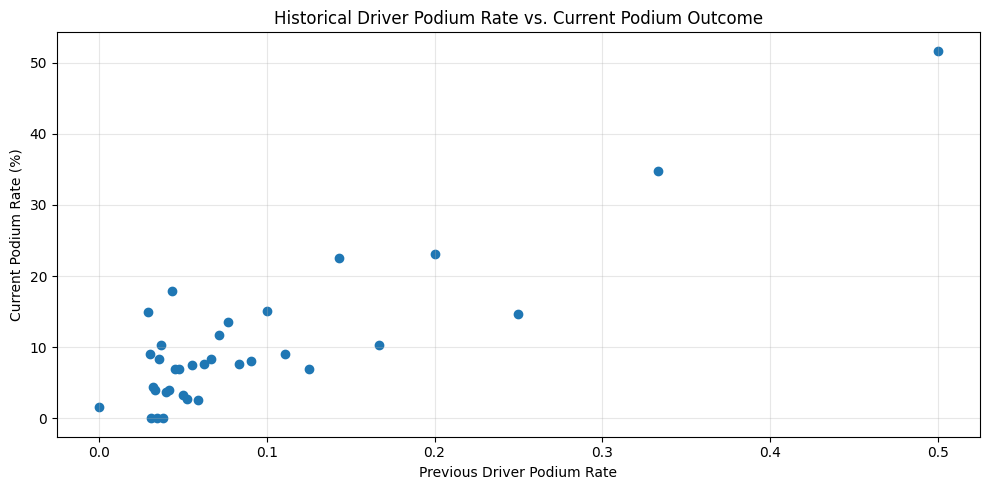

In [86]:
# Relationship between historical driver podium rate and current podium outcome

driver_history_effect = (
    model.groupby("driver_previous_podium_rate")["podium"]
    .mean()
    .reset_index()
)

# Keep only values with enough observations for a meaningful visualization
driver_history_counts = (
    model["driver_previous_podium_rate"]
    .value_counts()
)

valid_history_values = driver_history_counts[
    driver_history_counts >= 20
].index

driver_history_effect = driver_history_effect[
    driver_history_effect["driver_previous_podium_rate"]
    .isin(valid_history_values)
]

plt.figure(figsize=(10, 5))

plt.scatter(
    driver_history_effect["driver_previous_podium_rate"],
    driver_history_effect["podium"] * 100
)

plt.xlabel("Previous Driver Podium Rate")
plt.ylabel("Current Podium Rate (%)")
plt.title("Historical Driver Podium Rate vs. Current Podium Outcome")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

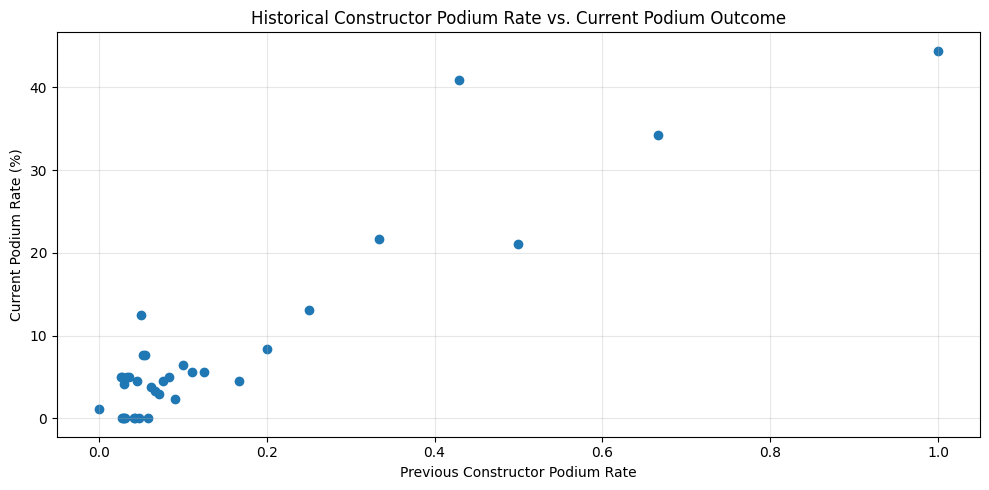

In [87]:
# Relationship between historical constructor podium rate
# and current podium outcome

constructor_history_effect = (
    model.groupby("constructor_previous_podium_rate")["podium"]
    .mean()
    .reset_index()
)

constructor_history_counts = (
    model["constructor_previous_podium_rate"]
    .value_counts()
)

valid_constructor_values = constructor_history_counts[
    constructor_history_counts >= 20
].index

constructor_history_effect = constructor_history_effect[
    constructor_history_effect["constructor_previous_podium_rate"]
    .isin(valid_constructor_values)
]

plt.figure(figsize=(10, 5))

plt.scatter(
    constructor_history_effect["constructor_previous_podium_rate"],
    constructor_history_effect["podium"] * 100
)

plt.xlabel("Previous Constructor Podium Rate")
plt.ylabel("Current Podium Rate (%)")
plt.title("Historical Constructor Podium Rate vs. Current Podium Outcome")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

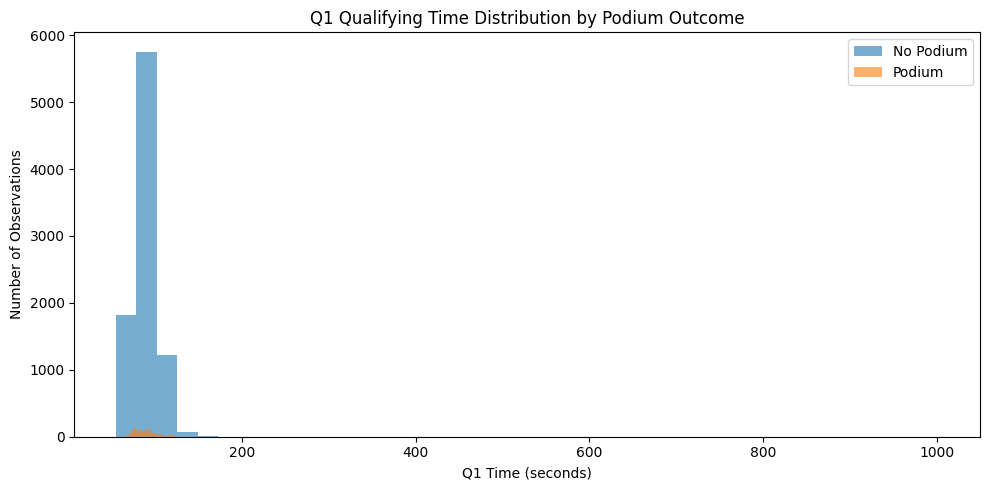

In [88]:
# Q1 qualifying time distribution by podium outcome

plt.figure(figsize=(10, 5))

plt.hist(
    model.loc[
        model["podium"] == 0,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="No Podium"
)

plt.hist(
    model.loc[
        model["podium"] == 1,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="Podium"
)

plt.xlabel("Q1 Time (seconds)")
plt.ylabel("Number of Observations")
plt.title("Q1 Qualifying Time Distribution by Podium Outcome")
plt.legend()

plt.tight_layout()
plt.show()

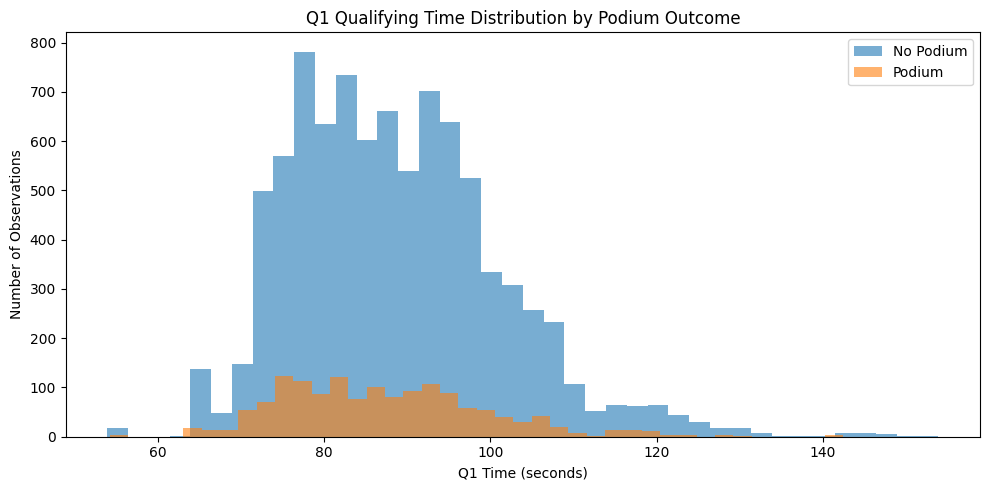

In [89]:
# Q1 qualifying-time distribution by podium outcome
# The x-axis is limited for visualization only.
# The underlying data, including historical extreme values, is unchanged.

q1_plot_data = model[
    model["q1_seconds"] <= 200
].copy()

plt.figure(figsize=(10, 5))

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 0,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="No Podium"
)

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 1,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="Podium"
)

plt.xlabel("Q1 Time (seconds)")
plt.ylabel("Number of Observations")
plt.title("Q1 Qualifying Time Distribution by Podium Outcome")
plt.legend()

plt.tight_layout()
plt.show()

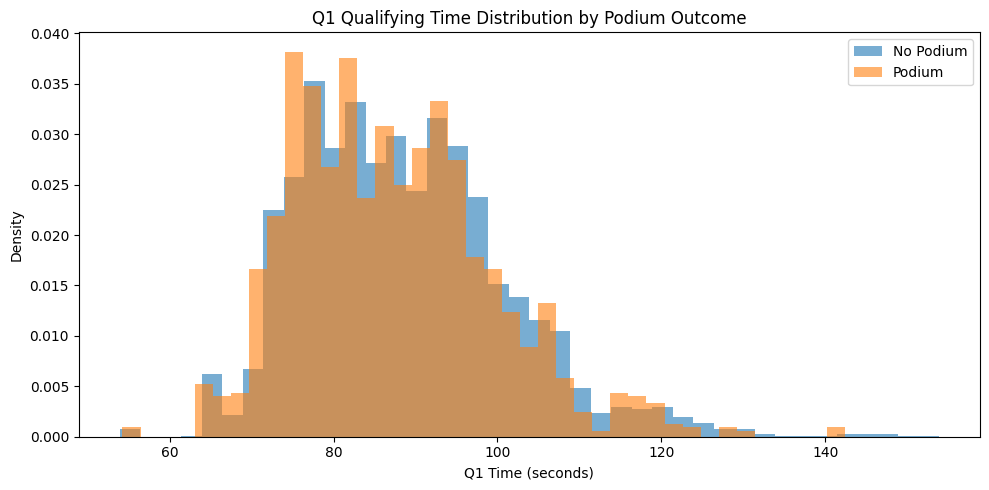

In [90]:
# Compare Q1 qualifying-time distributions by podium outcome
# using proportions rather than raw observation counts.

q1_plot_data = model[
    model["q1_seconds"] <= 200
].copy()

plt.figure(figsize=(10, 5))

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 0,
        "q1_seconds"
    ].dropna(),
    bins=40,
    density=True,
    alpha=0.6,
    label="No Podium"
)

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 1,
        "q1_seconds"
    ].dropna(),
    bins=40,
    density=True,
    alpha=0.6,
    label="Podium"
)

plt.xlabel("Q1 Time (seconds)")
plt.ylabel("Density")
plt.title("Q1 Qualifying Time Distribution by Podium Outcome")
plt.legend()

plt.tight_layout()
plt.show()

---
## CHECKPOINT 4 — Data-Engineering Questions (all 3)

**Checklist items covered:** All three Data-Engineering Questions, with plotted results and written answers in markdown.

**Evidence:** Q1: grid and qualifying-position rankings with two plots; Q2: home vs. non-home podium rates by grid group with a plot; Q3: mechanical-retirement rates by constructor with two plots; each followed by an 'Answer' cell.

---

## Data-Engineering Questions

## Data-Engineering Question 1

### Which circuits convert a front-row start into a podium most often, and does the ranking change after the 2014 hybrid era?

A front-row start is defined using the actual starting grid (`grid` positions 1 or 2), rather than qualifying position. This distinction is important because penalties can change a driver's starting position after qualifying.

For each circuit, the front-row podium conversion rate is calculated as:

**Front-row podium conversion rate = podium finishes among front-row starters / total front-row starters**

The analysis compares the pre-hybrid period (1994–2013) with the hybrid era and later period (2014–2024).

Only the race-driver grain is used, with one row per `(raceId, driverId)`.

In [91]:
# ============================================================
# Data-Engineering Question 1
# Front-row podium conversion by circuit and era
# ============================================================

# Add circuit names to the analysis table.
# We use the actual grid position, not qualifying position.

q1_analysis = (
    model[
        [
            "raceId",
            "driverId",
            "year",
            "circuitId",
            "grid",
            "podium"
        ]
    ]
    .merge(
        circuits[["circuitId", "name"]],
        on="circuitId",
        how="left"
    )
    .copy()
)

# Define actual front-row starters.
q1_analysis["front_row"] = (
    q1_analysis["grid"].isin([1, 2])
).astype(int)

# Keep only actual front-row starts.
q1_front_row = q1_analysis[
    q1_analysis["front_row"] == 1
].copy()

# Define the two historical periods.
q1_front_row["era"] = np.where(
    q1_front_row["year"] < 2014,
    "Pre-Hybrid (1994-2013)",
    "Hybrid+ (2014-2024)"
)

# Aggregate by circuit and era.
q1_circuit = (
    q1_front_row
    .groupby(
        ["era", "circuitId", "name"],
        as_index=False
    )
    .agg(
        front_row_starts=("podium", "size"),
        podiums=("podium", "sum")
    )
)

# Calculate podium conversion rate.
q1_circuit["podium_conversion_rate"] = (
    q1_circuit["podiums"]
    / q1_circuit["front_row_starts"]
)

# Display the strongest circuits.
q1_circuit.sort_values(
    ["era", "podium_conversion_rate"],
    ascending=[True, False]
).head(20)

,era,circuitId,name,front_row_starts,podiums,podium_conversion_rate
26,Hybrid+ (2014-2024),75,Autódromo Internacional do Algarve,4,4,1.000000
27,Hybrid+ (2014-2024),76,Autodromo Internazionale del Mugello,2,2,1.000000
30,Hybrid+ (2014-2024),79,Miami International Autodrome,6,6,1.000000
31,Hybrid+ (2014-2024),80,Las Vegas Strip Street Circuit,4,4,1.000000
17,Hybrid+ (2014-2024),22,Suzuka Circuit,18,16,0.888889
21,Hybrid+ (2014-2024),39,Circuit Park Zandvoort,8,7,0.875000
28,Hybrid+ (2014-2024),77,Jeddah Corniche Circuit,8,7,0.875000
18,Hybrid+ (2014-2024),24,Yas Marina Circuit,22,19,0.863636
1,Hybrid+ (2014-2024),2,Sepang International Circuit,7,6,0.857143
5,Hybrid+ (2014-2024),6,Circuit de Monaco,20,17,0.850000


In [92]:
# ============================================================
# Q1: Reliable circuit ranking
# Require at least 10 front-row starts in each era
# ============================================================

q1_reliable = q1_circuit[
    q1_circuit["front_row_starts"] >= 10
].copy()

# Rank circuits within each era
q1_reliable["rank"] = (
    q1_reliable
    .groupby("era")["podium_conversion_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Show the top 10 circuits in each era
q1_top10 = (
    q1_reliable
    .sort_values(
        ["era", "podium_conversion_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

print(q1_top10.to_string(index=False))

                   era  circuitId                           name  front_row_starts  podiums  podium_conversion_rate  rank
   Hybrid+ (2014-2024)         22                 Suzuka Circuit                18       16                0.888889   1.0
   Hybrid+ (2014-2024)         24             Yas Marina Circuit                22       19                0.863636   2.0
   Hybrid+ (2014-2024)          6              Circuit de Monaco                20       17                0.850000   3.0
   Hybrid+ (2014-2024)          4 Circuit de Barcelona-Catalunya                22       18                0.818182   4.0
   Hybrid+ (2014-2024)         13   Circuit de Spa-Francorchamps                22       18                0.818182   4.0
   Hybrid+ (2014-2024)         71                 Sochi Autodrom                16       13                0.812500   6.0
   Hybrid+ (2014-2024)         69        Circuit of the Americas                20       16                0.800000   7.0
   Hybrid+ (2014-2024)  

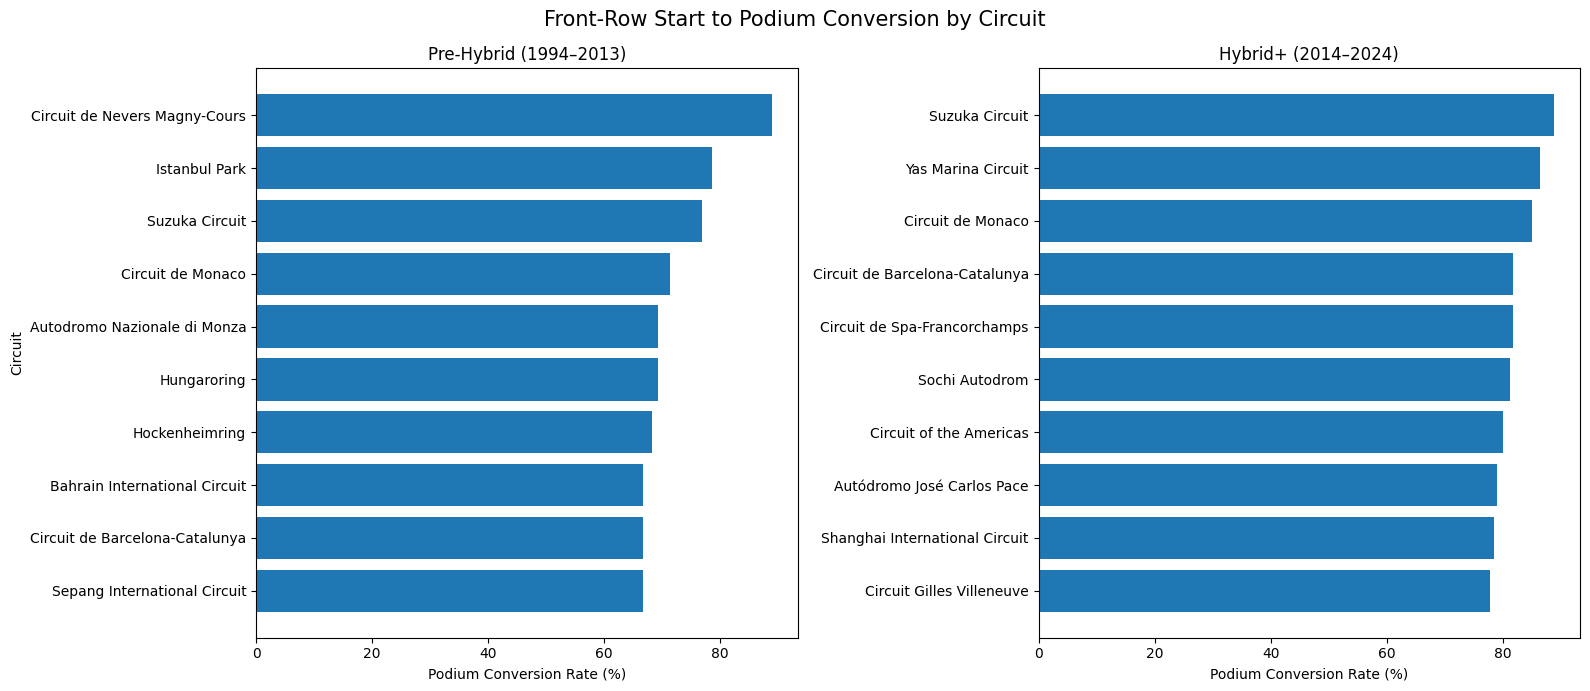

In [93]:
# ============================================================
# Q1 Final Visualization
# Top circuits by front-row -> podium conversion rate
# ============================================================

# Select the top 10 circuits from each era
plot_data = q1_reliable.copy()

pre_hybrid = (
    plot_data[
        plot_data["era"] == "Pre-Hybrid (1994-2013)"
    ]
    .sort_values("podium_conversion_rate", ascending=True)
    .tail(10)
)

hybrid = (
    plot_data[
        plot_data["era"] == "Hybrid+ (2014-2024)"
    ]
    .sort_values("podium_conversion_rate", ascending=True)
    .tail(10)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    sharex=True
)

# Pre-hybrid
axes[0].barh(
    pre_hybrid["name"],
    pre_hybrid["podium_conversion_rate"] * 100
)

axes[0].set_title("Pre-Hybrid (1994–2013)")
axes[0].set_xlabel("Podium Conversion Rate (%)")
axes[0].set_ylabel("Circuit")

# Hybrid+
axes[1].barh(
    hybrid["name"],
    hybrid["podium_conversion_rate"] * 100
)

axes[1].set_title("Hybrid+ (2014–2024)")
axes[1].set_xlabel("Podium Conversion Rate (%)")
axes[1].set_ylabel("")

fig.suptitle(
    "Front-Row Start to Podium Conversion by Circuit",
    fontsize=15
)

plt.tight_layout()
plt.show()

Qualified on the front row but started elsewhere (e.g. penalties): 38
Started on the front row without qualifying there: 36

Pre-Hybrid (1994-2013) — top 10 by grid version
                          name  front_row_starts_grid  podium_conversion_rate_grid  rank_grid  front_row_starts_quali  podium_conversion_rate_quali  rank_quali
 Circuit de Nevers Magny-Cours                     18                        0.889        1.0                      18                         0.889         1.0
                 Istanbul Park                     14                        0.786        2.0                      14                         0.786         2.0
                Suzuka Circuit                     26                        0.769        3.0                      26                         0.769         3.0
             Circuit de Monaco                     28                        0.714        4.0                      28                         0.643        13.0
                   Hungaror

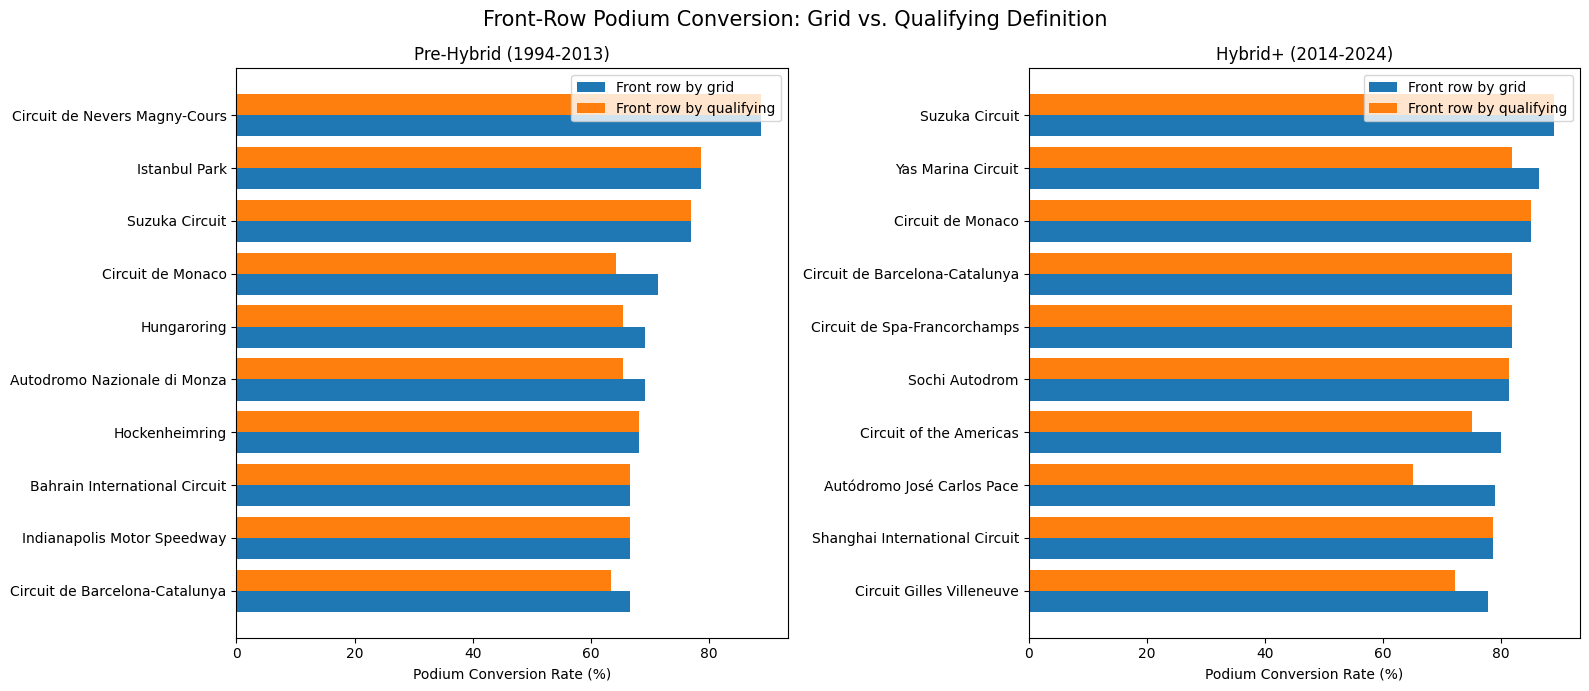

In [94]:
# ============================================================
# Q1 (qualifying version): front row = qualifying position 1 or 2
# ============================================================
# Same calculation as the grid version above, but "front row" now means
# QUALIFYING position 1 or 2. Grid penalties make the two differ.

front_by_grid = model["grid"].isin([1, 2])
front_by_quali = model["qualifying_position"].isin([1, 2])
print("Qualified on the front row but started elsewhere (e.g. penalties):",
      (front_by_quali & ~front_by_grid).sum())
print("Started on the front row without qualifying there:",
      (~front_by_quali & front_by_grid).sum())

# (drop the race "name" column first so the circuit name can use that column name)
q1_quali = (
    model[front_by_quali]
    .drop(columns="name")
    .merge(circuits[["circuitId", "name"]], on="circuitId", how="left")
)
q1_quali["era"] = np.where(q1_quali["year"] < 2014, "Pre-Hybrid (1994-2013)", "Hybrid+ (2014-2024)")

q1_quali_circuit = (
    q1_quali
    .groupby(["era", "circuitId", "name"], as_index=False)
    .agg(front_row_starts=("podium", "size"), podiums=("podium", "sum"))
)
q1_quali_circuit["podium_conversion_rate"] = (
    q1_quali_circuit["podiums"] / q1_quali_circuit["front_row_starts"]
)

# Same reliability rule as the grid version: at least 10 front-row starts.
q1_quali_reliable = q1_quali_circuit[q1_quali_circuit["front_row_starts"] >= 10].copy()
q1_quali_reliable["rank"] = (
    q1_quali_reliable.groupby("era")["podium_conversion_rate"].rank(ascending=False, method="min")
)

# Side-by-side table: grid version vs qualifying version.
q1_compare = q1_reliable[["era", "name", "front_row_starts", "podium_conversion_rate", "rank"]].merge(
    q1_quali_reliable[["era", "name", "front_row_starts", "podium_conversion_rate", "rank"]],
    on=["era", "name"],
    how="outer",
    suffixes=("_grid", "_quali")
)

for era in ["Pre-Hybrid (1994-2013)", "Hybrid+ (2014-2024)"]:
    print(f"\n{era} — top 10 by grid version")
    print(
        q1_compare[q1_compare["era"] == era]
        .sort_values("rank_grid")
        .head(10)
        .drop(columns="era")
        .round(3)
        .to_string(index=False)
    )

# Plot: conversion rate of the top-10 grid-version circuits under both definitions.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, era in zip(axes, ["Pre-Hybrid (1994-2013)", "Hybrid+ (2014-2024)"]):
    top = (
        q1_compare[q1_compare["era"] == era]
        .sort_values("rank_grid")
        .head(10)
        .iloc[::-1]
    )
    y = np.arange(len(top))
    ax.barh(y - 0.2, top["podium_conversion_rate_grid"] * 100, height=0.4, label="Front row by grid")
    ax.barh(y + 0.2, top["podium_conversion_rate_quali"] * 100, height=0.4, label="Front row by qualifying")
    ax.set_yticks(y)
    ax.set_yticklabels(top["name"])
    ax.set_title(era)
    ax.set_xlabel("Podium Conversion Rate (%)")
    ax.legend()

fig.suptitle("Front-Row Podium Conversion: Grid vs. Qualifying Definition", fontsize=15)
plt.tight_layout()
plt.show()

### Answer to Data-Engineering Question 1

The circuit ranking for converting a front-row start into a podium changes between the pre-hybrid and hybrid+ periods. Using circuits with at least 10 front-row starts (to avoid unstable rankings from very small samples):

**Grid version (front row = `grid` 1 or 2, the actual starting position):**
- Pre-hybrid (1994–2013): Magny-Cours ranks first (16 podiums from 18 front-row starts; 88.9%), then Istanbul Park (78.6%) and Suzuka (76.9%).
- Hybrid+ (2014–2024): Suzuka ranks first (16 of 18; 88.9%), then Yas Marina (86.4%) and Monaco (85.0%).

**Qualifying version (front row = `qualifying_position` 1 or 2):**
- 38 drivers qualified on the front row but started elsewhere (for example after grid penalties), and 36 started on the front row without qualifying there.
- The top three per era barely change: pre-hybrid Magny-Cours, Istanbul Park and Suzuka; hybrid+ Suzuka (88.9%), then Monaco (85.0%) and Yas Marina (81.8%).
- Further down, the two definitions do differ. Monaco is 4th pre-hybrid by grid (71.4%) but 13th by qualifying (64.3%), and Interlagos (Autódromo José Carlos Pace) is 8th in the hybrid+ era by grid (78.9%) but 17th by qualifying (65.0%).

Under both definitions the ranking changes after the 2014 transition. The grid version is used as the main answer because `grid` is where the car actually started, after penalties. The side-by-side table and plot above show how penalties shift some circuits.

The unit of analysis is one driver-race observation (`raceId`, `driverId`); the front-row condition is pre-race information and the podium is the resulting outcome. The 10-start minimum is applied only to the analytical ranking and does not modify the modeling dataset.

**Missingness:** this analysis uses the modeling table, which only contains driver-race rows with a qualifying record (1994–2024). The 83 races without any qualifying record (one in 1994 and most of 1996–2002; see the qualifying-coverage table in Checkpoint 1) are therefore not included. This also keeps the grid and qualifying versions on exactly the same rows.

## Data-Engineering Question 2

### Do drivers podium more often at a circuit in their home country, after controlling for starting position?

In [95]:
# ============================================================
# Data-Engineering Question 2
# Home-country advantage after controlling for grid position
# ============================================================

q2_analysis = model[
    [
        "raceId",
        "driverId",
        "year",
        "grid",
        "home_race",
        "podium"
    ]
].copy()

# Exclude grid = 0 rows: the car did not start from a numbered grid slot.
# In the full dataset this mostly means "did not qualify" (older seasons with
# more entries than grid places), plus withdrawn cars and pit-lane starts.
# In the 1994+ rows used here it is mostly pit-lane starts.
grid0_all = results_clean[results_clean["grid"] == 0].merge(status, on="statusId")
grid0_here = model[model["grid"] == 0].merge(status, on="statusId")
print("grid = 0, all seasons:", len(grid0_all), "rows. Most common statuses:")
print(grid0_all["status"].value_counts().head(4).to_string())
print("\ngrid = 0 in this analysis (1994+):", len(grid0_here), "rows. Most common statuses:")
print(grid0_here["status"].value_counts().head(4).to_string())

q2_analysis = q2_analysis[
    q2_analysis["grid"] > 0
].copy()

# Create comparable starting-position groups.
q2_analysis["grid_group"] = pd.cut(
    q2_analysis["grid"],
    bins=[0, 3, 10, 15, np.inf],
    labels=[
        "Front (1-3)",
        "Upper midfield (4-10)",
        "Midfield (11-15)",
        "Back (16+)"
    ]
)

# Calculate podium rate within each starting-position group
# separately for home and non-home races.
q2_grouped = (
    q2_analysis
    .groupby(
        ["grid_group", "home_race"],
        observed=False
    )
    .agg(
        observations=("podium", "size"),
        podiums=("podium", "sum"),
        podium_rate=("podium", "mean")
    )
    .reset_index()
)

q2_grouped["home_status"] = q2_grouped["home_race"].map({
    0: "Non-home",
    1: "Home"
})

q2_grouped["podium_rate_percent"] = (
    q2_grouped["podium_rate"] * 100
)

q2_grouped[
    [
        "grid_group",
        "home_status",
        "observations",
        "podiums",
        "podium_rate_percent"
    ]
]

grid = 0, all seasons: 1635 rows. Most common statuses:
status
Did not qualify       1012
Did not prequalify     330
Withdrew               163
+1 Lap                  27

grid = 0 in this analysis (1994+): 87 rows. Most common statuses:
status
+1 Lap             26
Finished           22
+2 Laps             7
Did not qualify     5


,grid_group,home_status,observations,podiums,podium_rate_percent
0,Front (1-3),Non-home,1409,900,63.875089
1,Front (1-3),Home,71,42,59.154930
2,Upper midfield (4-10),Non-home,3294,442,13.418336
3,Upper midfield (4-10),Home,160,18,11.250000
4,Midfield (11-15),Non-home,2353,53,2.252444
5,Midfield (11-15),Home,110,1,0.909091
6,Back (16+),Non-home,2874,25,0.869868
7,Back (16+),Home,136,1,0.735294


In [96]:
# ============================================================
# Q2: Grid-adjusted overall home vs. non-home podium rate
# ============================================================

# Use the pooled distribution of grid groups as the common weights.
grid_weights = (
    q2_analysis["grid_group"]
    .value_counts(normalize=True)
    .sort_index()
)

# Get podium rates for home and non-home drivers.
rate_table = (
    q2_grouped
    .pivot(
        index="grid_group",
        columns="home_status",
        values="podium_rate"
    )
    .reindex(grid_weights.index)
)

# Standardized (grid-adjusted) podium rates.
adjusted_non_home = (
    rate_table["Non-home"] * grid_weights
).sum()

adjusted_home = (
    rate_table["Home"] * grid_weights
).sum()

adjusted_difference = adjusted_home - adjusted_non_home

print("Grid-adjusted podium rate:")
print(f"Home:     {adjusted_home * 100:.2f}%")
print(f"Non-home: {adjusted_non_home * 100:.2f}%")

print(
    f"\nAdjusted difference (Home - Non-home): "
    f"{adjusted_difference * 100:.2f} percentage points"
)

print("\nGrid-group weights used:")
print((grid_weights * 100).round(2))

Grid-adjusted podium rate:
Home:     12.57%
Non-home: 14.32%

Adjusted difference (Home - Non-home): -1.75 percentage points

Grid-group weights used:
grid_group
Front (1-3)              14.22
Upper midfield (4-10)    33.19
Midfield (11-15)         23.67
Back (16+)               28.92
Name: proportion, dtype: float64


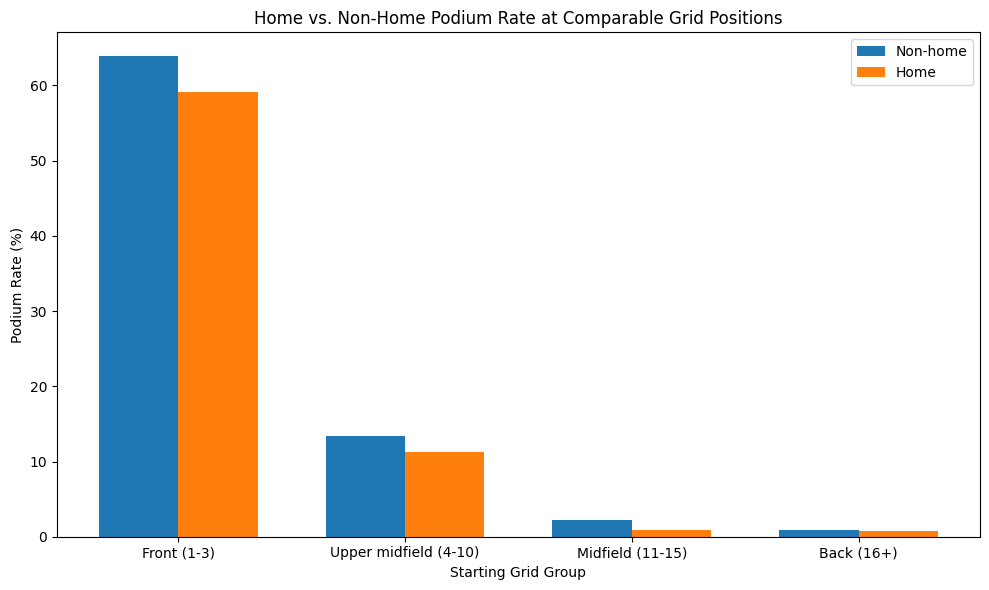

In [97]:
# ============================================================
# Q2 Final Visualization
# Podium rate by home status within comparable grid groups
# ============================================================

plot_q2 = q2_grouped.copy()

# Convert to percentage
plot_q2["podium_rate_percent"] = (
    plot_q2["podium_rate"] * 100
)

grid_order = [
    "Front (1-3)",
    "Upper midfield (4-10)",
    "Midfield (11-15)",
    "Back (16+)"
]

home_rates = (
    plot_q2[
        plot_q2["home_status"] == "Home"
    ]
    .set_index("grid_group")
    .reindex(grid_order)["podium_rate_percent"]
)

non_home_rates = (
    plot_q2[
        plot_q2["home_status"] == "Non-home"
    ]
    .set_index("grid_group")
    .reindex(grid_order)["podium_rate_percent"]
)

x = np.arange(len(grid_order))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    non_home_rates.values,
    width,
    label="Non-home"
)

plt.bar(
    x + width / 2,
    home_rates.values,
    width,
    label="Home"
)

plt.xticks(
    x,
    grid_order
)

plt.xlabel("Starting Grid Group")
plt.ylabel("Podium Rate (%)")
plt.title("Home vs. Non-Home Podium Rate at Comparable Grid Positions")
plt.legend()

plt.tight_layout()
plt.show()

### Answer to Data-Engineering Question 2

After controlling for starting position, the analysis does not show a positive home-country advantage in podium finishes. The podium rate for home races is lower than the non-home rate in every starting-grid group: 59.15% vs. 63.88% for the front group, 11.25% vs. 13.42% for positions 4–10, 0.91% vs. 2.25% for positions 11–15, and 0.74% vs. 0.87% for positions 16 and above.

Using the pooled distribution of starting-grid groups to standardize both groups gives a grid-adjusted podium rate of 12.57% for home races and 14.32% for non-home races, a difference of -1.75 percentage points.

**Why grid = 0 rows are excluded.** `grid = 0` means the car did not start from a numbered grid slot, so it has no comparable starting position. Across the whole dataset (1,635 rows), it mostly means the car **did not qualify**: 1,012 "Did not qualify" and 330 "Did not prequalify" rows, almost all from before 1995, when more cars entered than the grid allowed. A further 163 rows are withdrawn cars, and a few are pit-lane starts. In the 1994+ rows used in this analysis, only 87 rows have `grid = 0`, and most of them are cars that started from the pit lane and still raced (for example 26 "+1 Lap" and 22 "Finished"), with only 5 "Did not qualify". The cell above prints these counts.

Home race is determined by mapping the driver's nationality to the circuit country. The comparison uses one driver-race observation per `(raceId, driverId)` and compares the pre-race starting position with the eventual podium outcome.

This result should be interpreted as an association in the dataset, not as evidence that racing at home causes a lower podium probability.

**Missingness:** like Q1, this analysis uses the modeling table, so only driver-race rows with a qualifying record (1994–2024) are included; rows with `grid = 0` are excluded as explained above.

## Data-Engineering Question 3

In [98]:
# ============================================================
# Data-Engineering Question 3
# Inspect actual retirement/status values
# ============================================================

status = pd.read_csv(
    f"{data_path}/status.csv",
    na_values="\\N"
)

# Race results from the required periods
q3_base = (
    results_clean[
        ["raceId", "driverId", "constructorId", "statusId"]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
)

q3_base = q3_base[
    q3_base["year"].between(2014, 2024)
].copy()

# Attach status descriptions
q3_base = q3_base.merge(
    status[["statusId", "status"]],
    on="statusId",
    how="left"
)

# Count each status
status_counts = (
    q3_base
    .groupby("status", dropna=False)
    .size()
    .sort_values(ascending=False)
)

print("Status values in 2014-2024:")
print(status_counts.to_string())

Status values in 2014-2024:
status
Finished            2403
+1 Lap              1178
+2 Laps              208
Collision            150
Accident              85
Engine                81
Collision damage      59
Retired               50
Brakes                49
Gearbox               42
Power Unit            42
Suspension            25
+3 Laps               24
Hydraulics            15
Withdrew              14
Electrical            14
Power loss            13
Disqualified          11
Wheel                 11
Spun off              11
Oil leak              10
Overheating            8
Water pressure         7
Puncture               7
Mechanical             7
Turbo                  6
+4 Laps                6
Battery                5
Fuel pressure          5
Exhaust                5
ERS                    5
Undertray              4
Electronics            4
Water leak             4
Tyre                   4
Front wing             3
Transmission           3
Wheel nut              3
Rear wing      

In [99]:
# ============================================================
# Data-Engineering Question 3
# Define mechanical vs. non-mechanical retirement statuses
# ============================================================

# Clear component/system-failure statuses observed in the dataset.
mechanical_statuses = {
    "Engine",
    "Brakes",
    "Gearbox",
    "Power Unit",
    "Suspension",
    "Hydraulics",
    "Electrical",
    "Power loss",
    "Oil leak",
    "Overheating",
    "Water pressure",
    "Turbo",
    "Battery",
    "Fuel pressure",
    "Exhaust",
    "ERS",
    "Electronics",
    "Water leak",
    "Transmission",
    "Wheel",
    "Wheel nut",
    "Puncture",
    "Radiator",
    "Oil pressure",
    "Throttle",
    "Clutch",
    "Driveshaft",
    "Fuel leak",
    "Vibrations",
    "Steering",
    "Fuel system",
    "Fuel pump",
    "Drivetrain",
    "Brake duct",
    "Cooling system",
    "Differential",
    "Spark plugs",
    "Water pump",
    "Mechanical",
    "Technical"
}

# Join status and grid information.
q3_base = (
    results_clean[
        [
            "raceId",
            "driverId",
            "constructorId",
            "statusId",
            "grid"
        ]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
    .merge(
        status[["statusId", "status"]],
        on="statusId",
        how="left"
    )
)

# Keep only the two requested periods.
q3_base = q3_base[
    q3_base["year"].between(2014, 2024)
].copy()

# Race-start definition:
# "Withdrew" is excluded because the driver did not start the race.
# Other statuses remain race outcomes and therefore stay in the denominator.
q3_base["race_started"] = (
    q3_base["status"] != "Withdrew"
).astype(int)

# Mechanical failure indicator.
q3_base["mechanical_retirement"] = (
    q3_base["status"].isin(mechanical_statuses)
).astype(int)

# The mechanical indicator is only meaningful for actual race starts.
q3_base.loc[
    q3_base["race_started"] == 0,
    "mechanical_retirement"
] = 0

# Historical periods required by the question.
q3_base["era"] = np.where(
    q3_base["year"].between(2014, 2021),
    "2014-2021",
    "2022-2024"
)

print("Mechanical statuses used:")
print(sorted(mechanical_statuses))

print("\nStatuses NOT classified as mechanical:")
print(
    sorted(
        set(q3_base["status"].dropna().unique())
        - mechanical_statuses
    )
)

print("\nRace-start counts:")
print(
    q3_base.groupby("era")["race_started"]
    .sum()
)

print("\nMechanical-retirement counts:")
print(
    q3_base.groupby("era")["mechanical_retirement"]
    .sum()
)

Mechanical statuses used:
['Battery', 'Brake duct', 'Brakes', 'Clutch', 'Cooling system', 'Differential', 'Driveshaft', 'Drivetrain', 'ERS', 'Electrical', 'Electronics', 'Engine', 'Exhaust', 'Fuel leak', 'Fuel pressure', 'Fuel pump', 'Fuel system', 'Gearbox', 'Hydraulics', 'Mechanical', 'Oil leak', 'Oil pressure', 'Overheating', 'Power Unit', 'Power loss', 'Puncture', 'Radiator', 'Spark plugs', 'Steering', 'Suspension', 'Technical', 'Throttle', 'Transmission', 'Turbo', 'Vibrations', 'Water leak', 'Water pressure', 'Water pump', 'Wheel', 'Wheel nut']

Statuses NOT classified as mechanical:
['+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps', '+6 Laps', '+7 Laps', '+8 Laps', 'Accident', 'Collision', 'Collision damage', 'Damage', 'Debris', 'Disqualified', 'Excluded', 'Finished', 'Front wing', 'Illness', 'Out of fuel', 'Rear wing', 'Retired', 'Seat', 'Spun off', 'Tyre', 'Undertray', 'Withdrew']

Race-start counts:
era
2014-2021    3258
2022-2024    1354
Name: race_started, dtype: int64



In [100]:
# ============================================================
# Q3: Final documented mechanical-retirement mapping
# ============================================================

mechanical_statuses = {
    # Engine / powertrain
    "Engine",
    "Power Unit",
    "Power loss",
    "Turbo",
    "ERS",
    "Electrical",
    "Electronics",
    "Battery",
    "Spark plugs",

    # Transmission / drivetrain
    "Gearbox",
    "Transmission",
    "Drivetrain",
    "Differential",
    "Driveshaft",
    "Clutch",

    # Braking / steering / suspension
    "Brakes",
    "Brake duct",
    "Steering",
    "Suspension",

    # Cooling / fluids
    "Cooling system",
    "Radiator",
    "Water leak",
    "Water pressure",
    "Water pump",
    "Overheating",
    "Oil leak",
    "Oil pressure",

    # Fuel system
    "Fuel system",
    "Fuel pump",
    "Fuel pressure",
    "Fuel leak",

    # Other car/component failures
    "Hydraulics",
    "Exhaust",
    "Mechanical",
    "Technical",
    "Vibrations",
    "Wheel",
    "Wheel nut",
    "Puncture",
    "Tyre",
    "Front wing",
    "Rear wing",
    "Undertray",
    "Seat"
}

# Rebuild Q3 analysis table
q3_base = (
    results_clean[
        [
            "raceId",
            "driverId",
            "constructorId",
            "statusId"
        ]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
    .merge(
        status[["statusId", "status"]],
        on="statusId",
        how="left"
    )
)

# Requested periods only
q3_base = q3_base[
    q3_base["year"].between(2014, 2024)
].copy()

# Race starts:
# Withdrew means the driver did not start.
q3_base["race_started"] = (
    q3_base["status"] != "Withdrew"
).astype(int)

# Mechanical retirement indicator
q3_base["mechanical_retirement"] = (
    q3_base["status"].isin(mechanical_statuses)
).astype(int)

# Only actual race starts can have a mechanical retirement
q3_base.loc[
    q3_base["race_started"] == 0,
    "mechanical_retirement"
] = 0

# Required comparison periods
q3_base["era"] = np.where(
    q3_base["year"].between(2014, 2021),
    "2014-2021",
    "2022-2024"
)

# Verify that every status in the dataset is accounted for
unclassified_statuses = sorted(
    set(q3_base["status"].dropna().unique())
    - mechanical_statuses
)

print("Mechanical statuses:")
print(sorted(mechanical_statuses))

print("\nOther/non-mechanical statuses:")
print(unclassified_statuses)

print("\nMechanical retirements by era:")
print(
    q3_base.groupby("era")["mechanical_retirement"].sum()
)

Mechanical statuses:
['Battery', 'Brake duct', 'Brakes', 'Clutch', 'Cooling system', 'Differential', 'Driveshaft', 'Drivetrain', 'ERS', 'Electrical', 'Electronics', 'Engine', 'Exhaust', 'Front wing', 'Fuel leak', 'Fuel pressure', 'Fuel pump', 'Fuel system', 'Gearbox', 'Hydraulics', 'Mechanical', 'Oil leak', 'Oil pressure', 'Overheating', 'Power Unit', 'Power loss', 'Puncture', 'Radiator', 'Rear wing', 'Seat', 'Spark plugs', 'Steering', 'Suspension', 'Technical', 'Transmission', 'Turbo', 'Tyre', 'Undertray', 'Vibrations', 'Water leak', 'Water pressure', 'Water pump', 'Wheel', 'Wheel nut']

Other/non-mechanical statuses:
['+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps', '+6 Laps', '+7 Laps', '+8 Laps', 'Accident', 'Collision', 'Collision damage', 'Damage', 'Debris', 'Disqualified', 'Excluded', 'Finished', 'Illness', 'Out of fuel', 'Retired', 'Spun off', 'Throttle', 'Withdrew']

Mechanical retirements by era:
era
2014-2021    328
2022-2024     83
Name: mechanical_retirement, dtype: i

In [101]:
# ============================================================
# Q3: Mechanical-retirement rate by constructor and era
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

# Require at least 20 race starts within an era
# to avoid rankings dominated by tiny samples.
q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

q3_top10

,era,constructorId,race_starts,mechanical_retirements,mechanical_retirement_rate,rank
12,2014-2021,207,34,8,0.235294,1.0
13,2014-2021,208,75,15,0.200000,2.0
3,2014-2021,5,242,40,0.165289,3.0
2,2014-2021,4,200,29,0.145000,4.0
0,2014-2021,1,318,46,0.144654,5.0
7,2014-2021,15,200,23,0.115000,6.0
5,2014-2021,9,319,36,0.112853,7.0
16,2014-2021,211,76,8,0.105263,8.0
17,2014-2021,213,78,8,0.102564,9.0
11,2014-2021,206,31,3,0.096774,10.0


In [102]:
# ============================================================
# Q3: Correct the mechanical-failure mapping
# ============================================================

mechanical_statuses.add("Throttle")

# Recalculate mechanical retirement indicator
q3_base["mechanical_retirement"] = (
    q3_base["status"].isin(mechanical_statuses)
).astype(int)

# A non-starter cannot have a mechanical race retirement
q3_base.loc[
    q3_base["race_started"] == 0,
    "mechanical_retirement"
] = 0

print("Updated mechanical status count:",
      len(mechanical_statuses))

print("\nThrottle classified as mechanical:",
      "Throttle" in mechanical_statuses)

print("\nMechanical retirements by era:")
print(
    q3_base.groupby("era")["mechanical_retirement"]
    .sum()
)

Updated mechanical status count: 45

Throttle classified as mechanical: True

Mechanical retirements by era:
era
2014-2021    330
2022-2024     83
Name: mechanical_retirement, dtype: int64


In [103]:
# ============================================================
# Q3: Final constructor mechanical-retirement rates
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

# Keep constructors with at least 20 race starts in the era
q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

# Rank within each era
q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Top 10 constructors in each era
q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

# Add constructor names
q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(
        ["era", "rank"]
    )
)

print(
    q3_top10_named[
        [
            "era",
            "constructorId",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ].to_string(index=False)
)

      era  constructorId           name  race_starts  mechanical_retirements  mechanical_retirement_rate  rank
2014-2021            207       Caterham           34                       8                    0.235294   1.0
2014-2021            208       Lotus F1           75                      15                    0.200000   2.0
2014-2021              5     Toro Rosso          242                      40                    0.165289   3.0
2014-2021              4        Renault          200                      29                    0.145000   4.0
2014-2021              1        McLaren          318                      46                    0.144654   5.0
2014-2021             15         Sauber          200                      23                    0.115000   6.0
2014-2021              9       Red Bull          319                      36                    0.112853   7.0
2014-2021            211   Racing Point           76                       8                    0.105263   8.0
2

In [104]:
# ============================================================
# Q3: Add constructor names and display final ranking
# ============================================================

# Load constructors table (not loaded in the recovery cell)
constructors = pd.read_csv(
    f"{data_path}/constructors.csv",
    na_values="\\N"
)

# Add constructor names to the already-calculated Q3 ranking
q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(
        ["era", "rank"]
    )
)

print(
    q3_top10_named[
        [
            "era",
            "constructorId",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ].to_string(index=False)
)

      era  constructorId           name  race_starts  mechanical_retirements  mechanical_retirement_rate  rank
2014-2021            207       Caterham           34                       8                    0.235294   1.0
2014-2021            208       Lotus F1           75                      15                    0.200000   2.0
2014-2021              5     Toro Rosso          242                      40                    0.165289   3.0
2014-2021              4        Renault          200                      29                    0.145000   4.0
2014-2021              1        McLaren          318                      46                    0.144654   5.0
2014-2021             15         Sauber          200                      23                    0.115000   6.0
2014-2021              9       Red Bull          319                      36                    0.112853   7.0
2014-2021            211   Racing Point           76                       8                    0.105263   8.0
2

In [105]:
# ============================================================
# Q3: Recalculate constructor rates after final status mapping
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

# Keep constructors with at least 20 race starts in that era
q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(["era", "rank"])
)

print(
    q3_top10_named[
        [
            "era",
            "constructorId",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ].to_string(index=False)
)

      era  constructorId           name  race_starts  mechanical_retirements  mechanical_retirement_rate  rank
2014-2021            207       Caterham           34                       8                    0.235294   1.0
2014-2021            208       Lotus F1           75                      15                    0.200000   2.0
2014-2021              5     Toro Rosso          242                      40                    0.165289   3.0
2014-2021              4        Renault          200                      29                    0.145000   4.0
2014-2021              1        McLaren          318                      46                    0.144654   5.0
2014-2021             15         Sauber          200                      23                    0.115000   6.0
2014-2021              9       Red Bull          319                      36                    0.112853   7.0
2014-2021            211   Racing Point           76                       8                    0.105263   8.0
2

In [106]:
# ============================================================
# Q3: Final constructor mechanical-retirement ranking
# using the corrected mechanical-status mapping
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(["era", "rank"])
)

display(
    q3_top10_named[
        [
            "era",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ]
)

,era,name,race_starts,mechanical_retirements,mechanical_retirement_rate,rank
0,2014-2021,Caterham,34,8,0.235294,1.0
1,2014-2021,Lotus F1,75,15,0.200000,2.0
2,2014-2021,Toro Rosso,242,40,0.165289,3.0
3,2014-2021,Renault,200,29,0.145000,4.0
4,2014-2021,McLaren,318,46,0.144654,5.0
5,2014-2021,Sauber,200,23,0.115000,6.0
6,2014-2021,Red Bull,319,36,0.112853,7.0
7,2014-2021,Racing Point,76,8,0.105263,8.0
8,2014-2021,AlphaTauri,78,8,0.102564,9.0
9,2014-2021,Marussia,31,3,0.096774,10.0


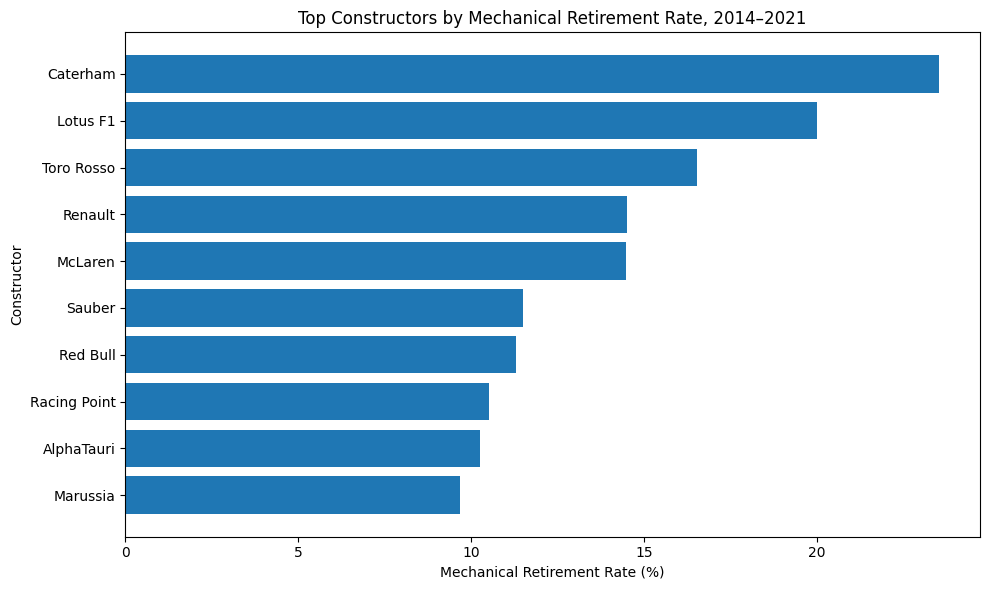

In [107]:
# ============================================================
# Q3 Visualization: 2014–2021
# ============================================================

plot_2014 = (
    q3_top10_named[
        q3_top10_named["era"] == "2014-2021"
    ]
    .sort_values("mechanical_retirement_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_2014["name"],
    plot_2014["mechanical_retirement_rate"] * 100
)

plt.xlabel("Mechanical Retirement Rate (%)")
plt.ylabel("Constructor")
plt.title(
    "Top Constructors by Mechanical Retirement Rate, 2014–2021"
)

plt.tight_layout()
plt.show()

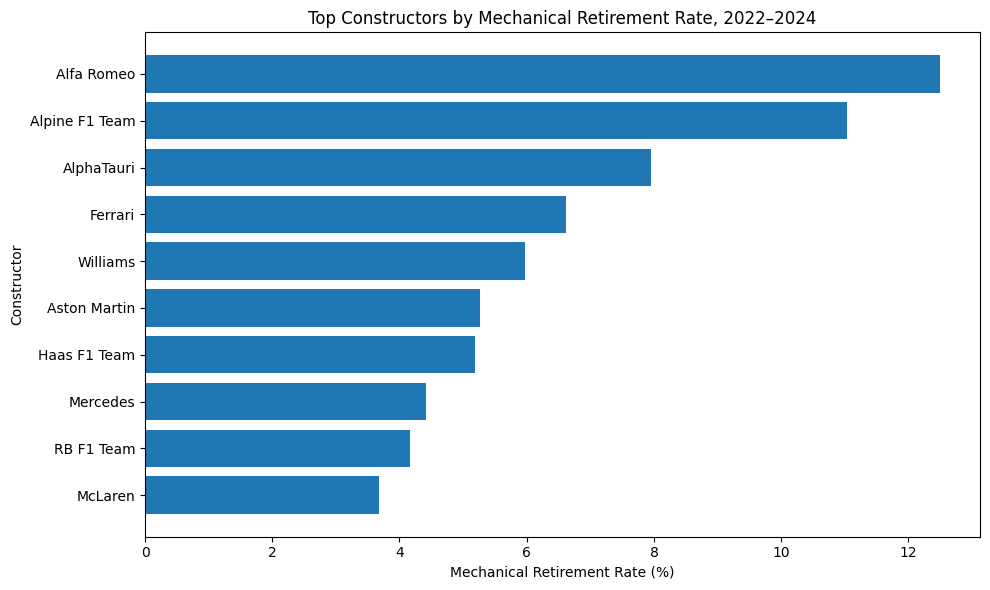

In [108]:
# ============================================================
# Q3 Visualization: 2022–2024
# ============================================================

plot_2022 = (
    q3_top10_named[
        q3_top10_named["era"] == "2022-2024"
    ]
    .sort_values("mechanical_retirement_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_2022["name"],
    plot_2022["mechanical_retirement_rate"] * 100
)

plt.xlabel("Mechanical Retirement Rate (%)")
plt.ylabel("Constructor")
plt.title(
    "Top Constructors by Mechanical Retirement Rate, 2022–2024"
)

plt.tight_layout()
plt.show()

## Answer to Data-Engineering Question 3

Mechanical-retirement rates differ substantially between the two periods. Among constructors with at least 20 race starts within the corresponding period, Caterham had the highest mechanical-retirement rate in 2014–2021, with 8 mechanical retirements in 34 race starts (23.53%). Lotus F1 ranked second at 20.00%, followed by Toro Rosso at 16.53%.

In 2022–2024, Alfa Romeo had the highest mechanical-retirement rate, with 11 mechanical retirements in 88 race starts (12.50%), followed by Alpine F1 Team at 11.03% and AlphaTauri at 7.95%.

Across all constructors, the aggregate mechanical-retirement count was 330 out of 3,258 race starts in 2014–2021 (10.13%) and 83 out of 1,354 race starts in 2022–2024 (6.13%). This indicates that the overall rate of recorded mechanical retirements was lower in the later period.

A mechanical retirement was defined using explicit component or system failure statuses in the dataset. Crash-related statuses such as Accident, Collision, Collision damage, Damage and Spun off were excluded, as were regulatory outcomes such as Disqualified and Excluded. Generic "Retired" was also excluded because it does not identify the cause of retirement. "Withdrew" was excluded from the race-start denominator because the driver did not start the race.

The analysis uses the race-driver level and joins race year, constructor identity and the status table. The 20-start minimum is applied only when producing the constructor ranking to reduce instability from very small samples; it does not modify the underlying data.

**Missingness:** every result row has a status and every status matches the status table (checked in Checkpoint 2), so no race starts are dropped because of missing data. Q3 does not use qualifying, so the missing qualifying records do not affect it, and it has no pre-race cutoff issue because it describes what happened in the race itself.

---
## CHECKPOINT 6 — Pre-processing and Feature Engineering

**Checklist items covered:** Effect of the preprocessing step on distribution / range / values, and the preprocessing-order experiments.

**Evidence:** Before/after statistics table and range plot below, Experiments A/B (order) and C/D (fit on training data only vs. all data); the pipeline itself is in 'Data Pre-processing Setup' above.

---

## Data Pre-processing and Feature Engineering Effects

In [109]:
# ============================================================
# Effect of preprocessing on feature ranges and distributions
# ============================================================

# Feature names in the processed matrix
processed_feature_names = X_train.columns.tolist()

# Create a before/after summary for the training data
before_stats = pd.DataFrame({
    "feature": processed_feature_names,
    "before_mean": X_train.mean().values,
    "before_std": X_train.std().values,
    "before_min": X_train.min().values,
    "before_max": X_train.max().values
})

after_stats = pd.DataFrame({
    "feature": processed_feature_names,
    "after_mean": X_train_processed.mean(axis=0),
    "after_std": X_train_processed.std(axis=0),
    "after_min": X_train_processed.min(axis=0),
    "after_max": X_train_processed.max(axis=0)
})

preprocessing_effect = before_stats.merge(
    after_stats,
    on="feature"
)

display(preprocessing_effect.round(3))

,feature,before_mean,before_std,before_min,before_max,after_mean,after_std,after_min,after_max
0,grid,11.412,6.438,1.000,30.000,0.0,1.0,-1.617,2.887
1,qualifying_position,11.376,6.369,1.000,28.000,0.0,1.0,-1.629,2.610
2,q1_seconds,89.313,15.891,63.807,1002.640,-0.0,1.0,-1.616,57.946
3,q2_seconds,88.981,11.841,63.378,132.470,-0.0,1.0,-3.028,5.145
4,q3_seconds,88.722,12.095,63.003,129.776,-0.0,1.0,-3.793,6.135
5,driver_previous_races,65.731,63.446,0.000,296.000,-0.0,1.0,-1.036,3.630
6,driver_previous_podiums,14.319,25.529,0.000,150.000,0.0,1.0,-0.561,5.315
7,driver_previous_podium_rate,0.135,0.184,0.000,1.000,-0.0,1.0,-0.735,4.699
8,driver_previous_avg_finish,11.530,3.472,1.000,28.000,0.0,1.0,-3.061,4.789
9,driver_previous_5_avg_finish,11.327,4.516,1.000,28.000,0.0,1.0,-2.310,3.726


## Effect of Data Pre-processing

The preprocessing stage had two main effects. First, missing numerical values were filled using median values learned from the training set. Second, the features were standardized using the training-set mean and standard deviation.

Before preprocessing, the feature ranges were substantially different. For example, `grid` ranged from 0 to 26, `driver_previous_races` from 0 to 296, `driver_age` from 17.45 to 43.89, and `alt` from -7 to 2227. After standardization, the training features have approximately zero mean and unit standard deviation.

This puts the numerical features on a comparable scale, which is particularly important for scale-sensitive models such as logistic regression and the shallow neural network. The preprocessing does not remove observations or alter the target variable.

A large standardized value remains for `q1_seconds` because the training data contain a historical Q1 value of 1002.64 seconds. This observation was retained because the original value is valid according to the recorded data; preprocessing only rescales it.

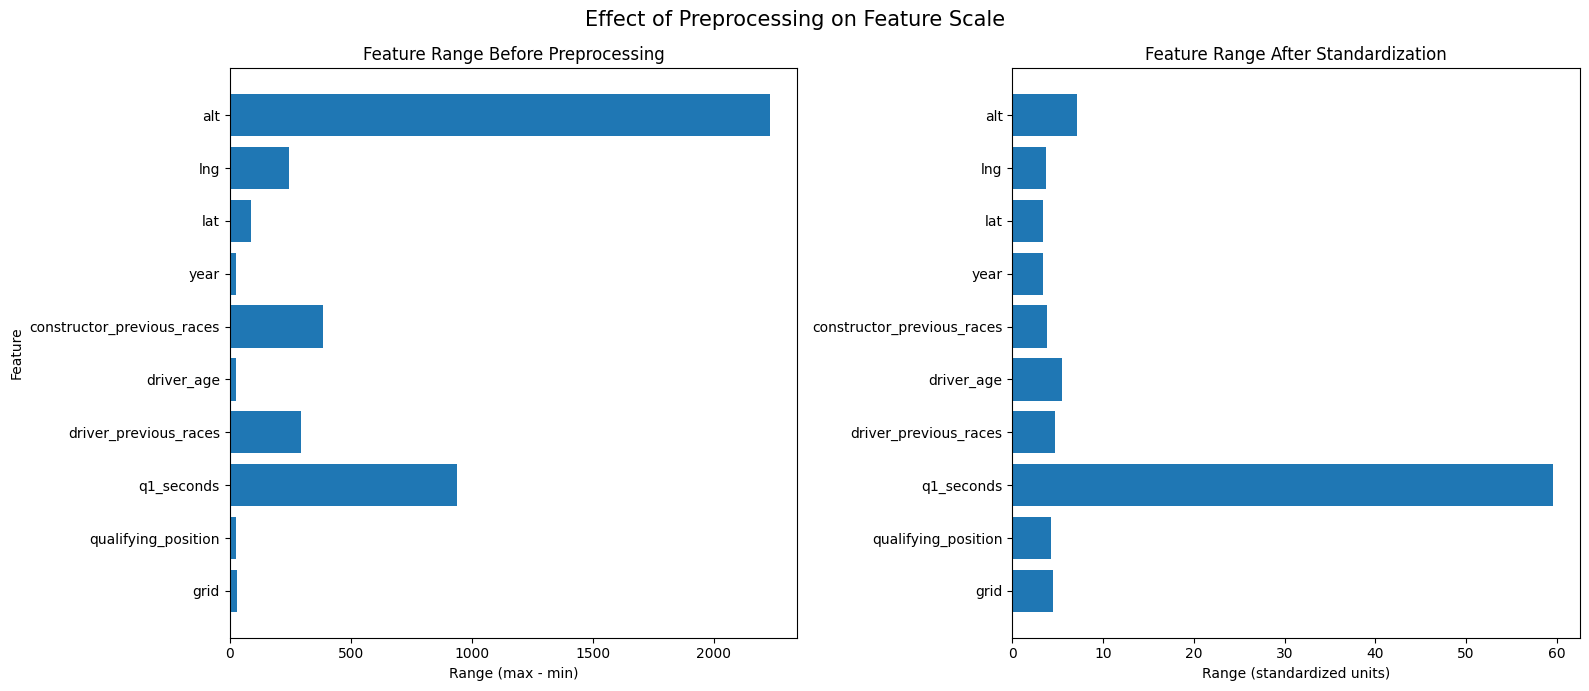

In [110]:
# ============================================================
# Visualize the effect of standardization on feature ranges
# ============================================================

selected_features = [
    "grid",
    "qualifying_position",
    "q1_seconds",
    "driver_previous_races",
    "driver_age",
    "constructor_previous_races",
    "year",
    "lat",
    "lng",
    "alt"
]

before_ranges = (
    X_train[selected_features]
    .agg(["min", "max"])
    .T
)

after_ranges = pd.DataFrame({
    "min": X_train_processed[
        :, [X_train.columns.get_loc(f) for f in selected_features]
    ].min(axis=0),
    "max": X_train_processed[
        :, [X_train.columns.get_loc(f) for f in selected_features]
    ].max(axis=0)
}, index=selected_features)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

# Before preprocessing
axes[0].barh(
    before_ranges.index,
    before_ranges["max"] - before_ranges["min"]
)

axes[0].set_title("Feature Range Before Preprocessing")
axes[0].set_xlabel("Range (max - min)")
axes[0].set_ylabel("Feature")

# After preprocessing
axes[1].barh(
    after_ranges.index,
    after_ranges["max"] - after_ranges["min"]
)

axes[1].set_title("Feature Range After Standardization")
axes[1].set_xlabel("Range (standardized units)")
axes[1].set_ylabel("")

fig.suptitle(
    "Effect of Preprocessing on Feature Scale",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Effect of Pre-processing on Feature Scale

Before preprocessing, the candidate features were measured on substantially different numerical scales. For example, altitude ranged from -7 to 2227, while historical podium rates ranged from 0 to 1. Qualifying times, driver history counts, and geographic coordinates also had different ranges.

After median imputation and standardization, the training features have approximately zero mean and unit standard deviation. This places the features on comparable scales and is particularly useful for scale-sensitive models such as logistic regression and the shallow neural network.

The preprocessing does not remove observations or modify the target variable. The unusually large standardized range of `q1_seconds` is caused by a historical extreme value that was retained because it is present in the original data.

In [111]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ============================================================
# Experiment A: Imputation → Standardization
# ============================================================

pipeline_impute_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_impute_scale.fit(
    X_train,
    y_train
)

pred_a = pipeline_impute_scale.predict_proba(
    X_validation
)[:, 1]

class_a = (pred_a >= 0.5).astype(int)


# ============================================================
# Experiment B: Standardization → Imputation
# ============================================================

pipeline_scale_impute = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_scale_impute.fit(
    X_train,
    y_train
)

pred_b = pipeline_scale_impute.predict_proba(
    X_validation
)[:, 1]

class_b = (pred_b >= 0.5).astype(int)


# ============================================================
# Compare validation performance
# ============================================================

results_preprocessing = pd.DataFrame({
    "Preprocessing Order": [
        "Imputation → Standardization",
        "Standardization → Imputation"
    ],
    "ROC-AUC": [
        roc_auc_score(y_validation, pred_a),
        roc_auc_score(y_validation, pred_b)
    ],
    "PR-AUC": [
        average_precision_score(y_validation, pred_a),
        average_precision_score(y_validation, pred_b)
    ],
    "F1": [
        f1_score(y_validation, class_a),
        f1_score(y_validation, class_b)
    ]
})

display(
    results_preprocessing.round(4)
)

,Preprocessing Order,ROC-AUC,PR-AUC,F1
0,Imputation → Standardization,0.9338,0.7368,0.6809
1,Standardization → Imputation,0.9338,0.7368,0.6809


## Pre-processing Order Experiments

Both experiments use the same features, training set, validation set, and Logistic Regression model (0.5 threshold), so only the preprocessing changes.

**Experiment 1: imputation → standardization vs. standardization → imputation**

| Order | ROC-AUC | PR-AUC | F1 |
|---|---|---|---|
| Imputation → Standardization | 0.9338 | 0.7368 | 0.6809 |
| Standardization → Imputation | 0.9338 | 0.7368 | 0.6809 |

The two orders give the same scores. This is expected: both steps work on one column at a time, and standardizing only shifts and rescales a column. The median of a rescaled column is the rescaled median, so a missing value gets the same final number in either order. **Imputation → Standardization** is kept as the main order because it is the standard, easy-to-read sequence.

**Experiment 2: preprocessing fitted on training data only vs. on all data before the split**

| Preprocessing fit | ROC-AUC | PR-AUC | F1 |
|---|---|---|---|
| C: fit on training data only | 0.9338 | 0.7368 | 0.6809 |
| D: fit on all data before the split (leaky) | 0.9337 | 0.7366 | 0.6762 |

In version D, the medians, means and standard deviations are computed with the validation and test seasons included, so information from the "future" leaks into training. Here the scores barely change, because the training seasons are about 80% of all rows, so the statistics hardly move. Version C is still the correct choice: in real use the future races are not available when the model is built, and the leaky version would make the evaluation less trustworthy. The decision follows from this principle, not from the small score difference.

In [112]:
# ============================================================
# Experiment C vs. D: fit preprocessing on training data only vs. on all data
# ============================================================
# C (correct): the imputer medians and scaler means/stds are learned from the
#              training seasons only, then applied to validation.
# D (leaky):   they are learned from ALL rows (train + validation + test) before
#              the split, so information from future seasons leaks into training.
# Same features, same Logistic Regression, same 0.5 threshold as experiments A/B.

X_all_rows = pd.concat([X_train, X_validation, X_test])

experiment_rows = []

for name, fit_data in [
    ("C: fit on training data only", X_train),
    ("D: fit on all data before the split (leaky)", X_all_rows),
]:
    experiment_preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    experiment_preprocessor.fit(fit_data)

    experiment_model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
    experiment_model.fit(experiment_preprocessor.transform(X_train), y_train)

    val_proba = experiment_model.predict_proba(experiment_preprocessor.transform(X_validation))[:, 1]

    experiment_rows.append({
        "Preprocessing fit": name,
        "ROC-AUC": roc_auc_score(y_validation, val_proba),
        "PR-AUC": average_precision_score(y_validation, val_proba),
        "F1": f1_score(y_validation, (val_proba >= 0.5).astype(int))
    })

results_fit_scope = pd.DataFrame(experiment_rows)
display(results_fit_scope.round(4))

,Preprocessing fit,ROC-AUC,PR-AUC,F1
0,C: fit on training data only,0.9338,0.7368,0.6809
1,D: fit on all data before the split (leaky),0.9337,0.7366,0.6762


---
## CHECKPOINT 8 — Prediction Models

**Checklist items covered:** Statistical models (Logistic Regression baseline, Random Forest) and a shallow FFNN: how they work, limitations, training/validation performance, unseen test performance, plots.

**Evidence:** 'Model Methods and Limitations', per-model training/validation tables, threshold selection, the training + validation table, and (after Checkpoint 9) the final test table with all five metrics and the validation/test comparison plots.

---

## Predictive Modeling

## Model Methods and Limitations

### Logistic Regression

Logistic Regression is the statistical baseline. It models the probability of a podium finish
using a linear combination of the standardized input features and applies the logistic function
to obtain a value between 0 and 1. Its main limitation is that it cannot directly represent
complex nonlinear interactions without additional feature engineering.

### Random Forest

Random Forest combines many decision trees trained on resampled data and randomized feature
subsets. It can capture nonlinear relationships and interactions without requiring a linear
decision boundary. Its main limitation in this experiment is overfitting: the training scores
are much higher than validation scores, so the model does not generalize as consistently as the
simpler approaches.

### Shallow Feed-Forward Neural Network

The neural network uses the architecture **34 → 32 → 16 → 1**, with ReLU activations in
the hidden layers and a sigmoid output for binary podium probability. It can learn nonlinear
relationships while remaining shallow enough to satisfy the milestone requirement. Its main
limitations are lower interpretability than Logistic Regression and sensitivity to the chosen
training setup and historical/era distribution. All random seeds are fixed, so it gives the
same results on every run in the same environment.

All three models use the same 34-feature modeling table and chronological train/validation/test
split. Model thresholds are selected using validation data only.


In [113]:
from sklearn.linear_model import LogisticRegression

# ============================================================
# Logistic Regression Baseline
# ============================================================

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# Train using the selected preprocessing:
# Imputation → Standardization
X_train_main = preprocessor.fit_transform(X_train)
X_validation_main = preprocessor.transform(X_validation)
X_test_main = preprocessor.transform(X_test)

logistic_model.fit(
    X_train_main,
    y_train
)

# Probabilities
y_train_proba_lr = logistic_model.predict_proba(
    X_train_main
)[:, 1]

y_validation_proba_lr = logistic_model.predict_proba(
    X_validation_main
)[:, 1]

# Default 0.5 threshold for now
y_train_pred_lr = (
    y_train_proba_lr >= 0.5
).astype(int)

y_validation_pred_lr = (
    y_validation_proba_lr >= 0.5
).astype(int)

print("Logistic Regression trained successfully.")

print("\nPrediction ranges:")
print(
    "Train:",
    y_train_proba_lr.min(),
    "to",
    y_train_proba_lr.max()
)

print(
    "Validation:",
    y_validation_proba_lr.min(),
    "to",
    y_validation_proba_lr.max()
)

Logistic Regression trained successfully.

Prediction ranges:
Train: 3.70891981849231e-05 to 0.9969200854544809
Validation: 6.630491451721815e-05 to 0.9878371118933633


In [114]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score
)

# ============================================================
# Logistic Regression: Training and Validation Performance
# ============================================================

# -------------------------
# Training metrics
# -------------------------

train_roc_auc_lr = roc_auc_score(
    y_train,
    y_train_proba_lr
)

train_pr_auc_lr = average_precision_score(
    y_train,
    y_train_proba_lr
)

train_f1_lr = f1_score(
    y_train,
    y_train_pred_lr
)


# -------------------------
# Validation metrics
# -------------------------

validation_roc_auc_lr = roc_auc_score(
    y_validation,
    y_validation_proba_lr
)

validation_pr_auc_lr = average_precision_score(
    y_validation,
    y_validation_proba_lr
)

validation_f1_lr = f1_score(
    y_validation,
    y_validation_pred_lr
)


# -------------------------
# Display results
# -------------------------

logistic_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "ROC-AUC": [
        train_roc_auc_lr,
        validation_roc_auc_lr
    ],
    "PR-AUC": [
        train_pr_auc_lr,
        validation_pr_auc_lr
    ],
    "F1": [
        train_f1_lr,
        validation_f1_lr
    ]
})

display(
    logistic_results.round(4)
)

,Dataset,ROC-AUC,PR-AUC,F1
0,Training,0.9238,0.6325,0.5998
1,Validation,0.9338,0.7368,0.6809


## Logistic Regression Baseline Results

Logistic Regression provides the statistical baseline for the podium prediction task. Using the initial 0.5 probability threshold, the model achieved a ROC-AUC of 0.9238, PR-AUC of 0.6325, and F1-score of 0.5998 on the training data. On the validation data, it achieved a ROC-AUC of 0.9338, PR-AUC of 0.7368, and F1-score of 0.6809.

The validation performance is higher than the training performance, so there is no sign of overfitting. A likely reason is that the training seasons include the 1990s and 2000s, when larger fields and lower reliability made podiums harder to predict than in 2020–2021. The test set is kept untouched at this stage and will only be used after model and threshold decisions are finalized.

In [115]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Random Forest Model
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train only on the training data
random_forest_model.fit(
    X_train_main,
    y_train
)

# Probability predictions
y_train_proba_rf = random_forest_model.predict_proba(
    X_train_main
)[:, 1]

y_validation_proba_rf = random_forest_model.predict_proba(
    X_validation_main
)[:, 1]

# Initial threshold = 0.5
y_train_pred_rf = (
    y_train_proba_rf >= 0.5
).astype(int)

y_validation_pred_rf = (
    y_validation_proba_rf >= 0.5
).astype(int)

print("Random Forest trained successfully.")

print("\nPrediction ranges:")
print(
    "Train:",
    y_train_proba_rf.min(),
    "to",
    y_train_proba_rf.max()
)

print(
    "Validation:",
    y_validation_proba_rf.min(),
    "to",
    y_validation_proba_rf.max()
)

Random Forest trained successfully.

Prediction ranges:
Train: 0.0 to 0.9942500284604405
Validation: 0.0 to 0.826650961175187


In [116]:
# ============================================================
# Random Forest: Training and Validation Performance
# ============================================================

# Training metrics
train_roc_auc_rf = roc_auc_score(
    y_train,
    y_train_proba_rf
)

train_pr_auc_rf = average_precision_score(
    y_train,
    y_train_proba_rf
)

train_f1_rf = f1_score(
    y_train,
    y_train_pred_rf
)

# Validation metrics
validation_roc_auc_rf = roc_auc_score(
    y_validation,
    y_validation_proba_rf
)

validation_pr_auc_rf = average_precision_score(
    y_validation,
    y_validation_proba_rf
)

validation_f1_rf = f1_score(
    y_validation,
    y_validation_pred_rf
)

# Results table
random_forest_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "ROC-AUC": [
        train_roc_auc_rf,
        validation_roc_auc_rf
    ],
    "PR-AUC": [
        train_pr_auc_rf,
        validation_pr_auc_rf
    ],
    "F1": [
        train_f1_rf,
        validation_f1_rf
    ]
})

display(
    random_forest_results.round(4)
)

,Dataset,ROC-AUC,PR-AUC,F1
0,Training,0.9993,0.9953,0.9587
1,Validation,0.9288,0.6977,0.6912


## Random Forest Results

The Random Forest achieves almost perfect performance on the training data (ROC-AUC = 0.9993, PR-AUC = 0.9953, F1 = 0.9587), but its validation performance drops to ROC-AUC = 0.9288, PR-AUC = 0.6977, and F1 = 0.6912. The large gap between training and validation shows substantial overfitting: the trees have memorized the training seasons.

At the 0.5 threshold the Random Forest has a slightly higher validation F1 than Logistic Regression (0.6912 vs. 0.6809), but Logistic Regression has clearly higher validation ROC-AUC and PR-AUC (0.9338 and 0.7368), meaning it ranks podium finishers above non-podium finishers more reliably.

In [117]:
# ============================================================
# Initial model comparison
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf
    ],
    "Validation F1": [
        validation_f1_lr,
        validation_f1_rf
    ]
})

display(
    model_comparison.round(4)
)

,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1
0,Logistic Regression,0.9338,0.7368,0.6809
1,Random Forest,0.9288,0.6977,0.6912


In [118]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# Shallow Feed-Forward Neural Network
# ============================================================

# Reproducibility: reset all seeds right before building the network,
# so its starting weights do not depend on earlier cells.
keras.utils.set_random_seed(42)

ffnn_model = keras.Sequential([
    layers.Input(shape=(X_train_main.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

# Give more importance to the minority podium class.
class_weights = {
    0: 1.0,
    1: len(y_train[y_train == 0]) / len(y_train[y_train == 1])
}

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_ffnn = ffnn_model.fit(
    X_train_main,
    y_train,
    validation_data=(
        X_validation_main,
        y_validation
    ),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("\nShallow FFNN trained successfully.")
print("Epochs actually used:", len(history_ffnn.history["loss"]))

2026-10-06 19:31:23.510461: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100


2026-10-06 19:31:23.840219: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7633 - pr_auc: 0.5363 - roc_auc: 0.8734 - val_loss: 0.3689 - val_pr_auc: 0.6672 - val_roc_auc: 0.9097
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6319 - pr_auc: 0.6060 - roc_auc: 0.9141 - val_loss: 0.3286 - val_pr_auc: 0.6926 - val_roc_auc: 0.9175
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6042 - pr_auc: 0.6278 - roc_auc: 0.9210 - val_loss: 0.3082 - val_pr_auc: 0.7044 - val_roc_auc: 0.9220
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5887 - pr_auc: 0.6384 - roc_auc: 0.9247 - val_loss: 0.2962 - val_pr_auc: 0.7180 - val_roc_auc: 0.9242
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5780 - pr_auc: 0.6459 - roc_auc: 0.9271 - val_loss: 0.2875 - val_pr_auc: 0.7297 - val_roc_auc: 0.9259
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5696 - pr_auc: 0.6495 - roc_auc: 0.9287 - val_loss: 0.2804 - val_pr_auc: 0.7321 - val_roc_auc: 0.9274
Epoch 7/100
262/262 ━━

  1/262 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5230 - pr_auc: 0.5226 - roc_auc: 0.9464

...

Epoch 31/100


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2470 - pr_auc: 0.9442 - roc_auc: 0.9911

162/262 ━━━━━━━━━━━━━━━━━━━━ 0s 312us/step - loss: 0.4734 - pr_auc: 0.7116 - roc_auc: 0.9481

262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - loss: 0.4776 - pr_auc: 0.7059 - roc_auc: 0.9469 - val_loss: 0.2575 - val_pr_auc: 0.7166 - val_roc_auc: 0.9200



Shallow FFNN trained successfully.
Epochs actually used: 31


In [119]:
# ============================================================
# Evaluate Shallow FFNN
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# Predicted probabilities
ffnn_train_proba = ffnn_model.predict(
    X_train_main,
    verbose=0
).ravel()

ffnn_validation_proba = ffnn_model.predict(
    X_validation_main,
    verbose=0
).ravel()

# Default classification threshold
ffnn_train_pred = (ffnn_train_proba >= 0.5).astype(int)
ffnn_validation_pred = (ffnn_validation_proba >= 0.5).astype(int)

# Metrics
train_roc_auc_ffnn = roc_auc_score(
    y_train,
    ffnn_train_proba
)

train_pr_auc_ffnn = average_precision_score(
    y_train,
    ffnn_train_proba
)

train_f1_ffnn = f1_score(
    y_train,
    ffnn_train_pred
)

validation_roc_auc_ffnn = roc_auc_score(
    y_validation,
    ffnn_validation_proba
)

validation_pr_auc_ffnn = average_precision_score(
    y_validation,
    ffnn_validation_proba
)

validation_f1_ffnn = f1_score(
    y_validation,
    ffnn_validation_pred
)

# Display results
ffnn_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "F1"
    ],
    "Training": [
        train_roc_auc_ffnn,
        train_pr_auc_ffnn,
        train_f1_ffnn
    ],
    "Validation": [
        validation_roc_auc_ffnn,
        validation_pr_auc_ffnn,
        validation_f1_ffnn
    ]
})

display(ffnn_results.round(4))

print("\nFFNN probability ranges:")
print(
    f"Training:   {ffnn_train_proba.min():.4f} to {ffnn_train_proba.max():.4f}"
)
print(
    f"Validation: {ffnn_validation_proba.min():.4f} to {ffnn_validation_proba.max():.4f}"
)

2026-10-06 19:31:49.725180: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Metric,Training,Validation
0,ROC-AUC,0.9433,0.9288
1,PR-AUC,0.6955,0.7309
2,F1,0.6350,0.6953



FFNN probability ranges:
Training:   0.0000 to 0.9896
Validation: 0.0000 to 0.9848


In [120]:
# ============================================================
# Final Validation Comparison: All Three Models
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf,
        validation_roc_auc_ffnn
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf,
        validation_pr_auc_ffnn
    ],
    "Validation F1": [
        validation_f1_lr,
        validation_f1_rf,
        validation_f1_ffnn
    ]
})

display(
    model_comparison
    .sort_values("Validation PR-AUC", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1
0,Logistic Regression,0.9338,0.7368,0.6809
1,Shallow FFNN,0.9288,0.7309,0.6953
2,Random Forest,0.9288,0.6977,0.6912


## Validation-Based Threshold Selection

In [121]:
# ============================================================
# Fair Threshold Tuning for All Three Models
# Validation Set Only
# ============================================================

def find_best_f1_threshold(y_true, probabilities):
    thresholds = np.arange(0.05, 0.96, 0.01)

    results = []

    for threshold in thresholds:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        f1 = f1_score(
            y_true,
            predictions
        )

        results.append({
            "Threshold": threshold,
            "F1": f1
        })

    results_df = pd.DataFrame(results)

    best_row = results_df.loc[
        results_df["F1"].idxmax()
    ]

    return (
        float(best_row["Threshold"]),
        float(best_row["F1"]),
        results_df
    )


# ------------------------------------------------------------
# Get validation probabilities for all models
# ------------------------------------------------------------

lr_validation_proba = logistic_model.predict_proba(
    X_validation_main
)[:, 1]

rf_validation_proba = random_forest_model.predict_proba(
    X_validation_main
)[:, 1]

# FFNN probability already exists:
# ffnn_validation_proba


# ------------------------------------------------------------
# Tune each model independently using validation only
# ------------------------------------------------------------

best_threshold_lr, best_validation_f1_lr, lr_threshold_results = (
    find_best_f1_threshold(
        y_validation,
        lr_validation_proba
    )
)

best_threshold_rf, best_validation_f1_rf, rf_threshold_results = (
    find_best_f1_threshold(
        y_validation,
        rf_validation_proba
    )
)

best_threshold_ffnn, best_validation_f1_ffnn, ffnn_threshold_results = (
    find_best_f1_threshold(
        y_validation,
        ffnn_validation_proba
    )
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

threshold_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Selected Validation Threshold": [
        best_threshold_lr,
        best_threshold_rf,
        best_threshold_ffnn
    ],
    "Best Validation F1": [
        best_validation_f1_lr,
        best_validation_f1_rf,
        best_validation_f1_ffnn
    ]
})

display(
    threshold_comparison.round(4)
)

,Model,Selected Validation Threshold,Best Validation F1
0,Logistic Regression,0.62,0.6964
1,Random Forest,0.23,0.6975
2,Shallow FFNN,0.58,0.7243


## Training and Validation Performance

For the checklist requirement on training and validation performance, the following table
reports all three metrics for every model. F1 uses the threshold selected from the validation set,
so the comparison is consistent with the final threshold-selection procedure.


In [122]:
# ============================================================
# Training + validation performance with validation-selected F1 thresholds
# ============================================================

train_f1_lr_selected = f1_score(
    y_train,
    (y_train_proba_lr >= best_threshold_lr).astype(int)
)

train_f1_rf_selected = f1_score(
    y_train,
    (y_train_proba_rf >= best_threshold_rf).astype(int)
)

train_f1_ffnn_selected = f1_score(
    y_train,
    (ffnn_train_proba >= best_threshold_ffnn).astype(int)
)

training_validation_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Train ROC-AUC": [
        roc_auc_score(y_train, y_train_proba_lr),
        roc_auc_score(y_train, y_train_proba_rf),
        roc_auc_score(y_train, ffnn_train_proba)
    ],
    "Train PR-AUC": [
        average_precision_score(y_train, y_train_proba_lr),
        average_precision_score(y_train, y_train_proba_rf),
        average_precision_score(y_train, ffnn_train_proba)
    ],
    "Train F1": [
        train_f1_lr_selected,
        train_f1_rf_selected,
        train_f1_ffnn_selected
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf,
        validation_roc_auc_ffnn
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf,
        validation_pr_auc_ffnn
    ],
    "Validation F1": [
        best_validation_f1_lr,
        best_validation_f1_rf,
        best_validation_f1_ffnn
    ],
})

display(training_validation_comparison.round(4))


,Model,Train ROC-AUC,Train PR-AUC,Train F1,Validation ROC-AUC,Validation PR-AUC,Validation F1
0,Logistic Regression,0.9238,0.6325,0.6231,0.9338,0.7368,0.6964
1,Random Forest,0.9993,0.9953,0.7850,0.9288,0.6977,0.6975
2,Shallow FFNN,0.9433,0.6955,0.6539,0.9288,0.7309,0.7243


---
## CHECKPOINT 9 — Feature-group Ablation

**Checklist items covered:** Feature-group ablation: one group removed at a time and the model retrained.

**Evidence:** The ablation table below (FFNN retrained with a fixed seed for each removed group) and the 'Feature-Group Ablation Results' interpretation.

---

In [123]:
# ============================================================
# Feature-Group Ablation Experiment
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Define feature groups
# ------------------------------------------------------------

feature_groups = {
    "Qualifying": [
        "qualifying_position",
        "q1_seconds",
        "q2_seconds",
        "q3_seconds",
        "q1_missing",
        "q2_missing",
        "q3_missing"
    ],

    "Grid": [
        "grid",
        "did_not_start_from_grid"
    ],

    "Driver Form": [
        "driver_previous_races",
        "driver_previous_podiums",
        "driver_previous_podium_rate",
        "driver_previous_avg_finish",
        "driver_previous_5_avg_finish",
        "driver_has_history"
    ],

    "Constructor Form": [
        "constructor_previous_races",
        "constructor_previous_podiums",
        "constructor_previous_podium_rate",
        "constructor_has_history"
    ],

    "Driver-Constructor Form": [
        "driver_constructor_previous_races",
        "driver_constructor_previous_podiums",
        "driver_constructor_previous_podium_rate",
        "driver_constructor_has_history"
    ],

    "Standings": [
        "driver_standing_points_before",
        "driver_standing_position_before",
        "constructor_standing_points_before",
        "constructor_standing_position_before"
    ],

    "Context": [
        "driver_age",
        "year",
        "round",
        "home_race",
        "lat",
        "lng",
        "alt"
    ]
}

# Check that every feature belongs to exactly one group
grouped_features = [
    feature
    for group in feature_groups.values()
    for feature in group
]

print("Total model features:", len(X_train.columns))
print("Features assigned to groups:", len(grouped_features))

assert set(grouped_features) == set(X_train.columns), \
    "Some features are missing from or duplicated in the groups."

# ------------------------------------------------------------
# Helper function for training one ablation model
# ------------------------------------------------------------

def train_ablation_ffnn(X_tr, y_tr, X_val, y_val, input_dim):

    # Same seed for every ablation run, so the only difference between
    # runs is the removed feature group (not random starting weights).
    keras.utils.set_random_seed(42)

    # Fit preprocessing ONLY on the training data
    ablation_preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_tr_processed = ablation_preprocessor.fit_transform(X_tr)
    X_val_processed = ablation_preprocessor.transform(X_val)

    # Same shallow architecture as the main FFNN
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_tr_processed,
        y_tr,
        validation_data=(X_val_processed, y_val),
        epochs=100,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation probabilities
    val_proba = model.predict(
        X_val_processed,
        verbose=0
    ).ravel()

    val_pred = (
        val_proba >= best_threshold_ffnn
    ).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_val, val_proba),
        "PR-AUC": average_precision_score(y_val, val_proba),
        "F1": f1_score(y_val, val_pred)
    }


# ------------------------------------------------------------
# Full model reference
# ------------------------------------------------------------

ablation_results = [{
    "Experiment": "Full Model",
    "Removed Group": "None",
    "Remaining Features": len(X_train.columns),
    "Validation ROC-AUC": validation_roc_auc_ffnn,
    "Validation PR-AUC": validation_pr_auc_ffnn,
    "Validation F1": best_validation_f1_ffnn
}]

# ------------------------------------------------------------
# Remove one group at a time
# ------------------------------------------------------------

for group_name, group_features in feature_groups.items():

    remaining_features = [
        col for col in X_train.columns
        if col not in group_features
    ]

    print(f"Training ablation: remove {group_name}...")

    metrics = train_ablation_ffnn(
        X_train[remaining_features],
        y_train,
        X_validation[remaining_features],
        y_validation,
        input_dim=len(remaining_features)
    )

    ablation_results.append({
        "Experiment": f"Without {group_name}",
        "Removed Group": group_name,
        "Remaining Features": len(remaining_features),
        "Validation ROC-AUC": metrics["ROC-AUC"],
        "Validation PR-AUC": metrics["PR-AUC"],
        "Validation F1": metrics["F1"]
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

ablation_results_df = pd.DataFrame(ablation_results)

ablation_results_df["PR-AUC Drop"] = (
    validation_pr_auc_ffnn -
    ablation_results_df["Validation PR-AUC"]
)

ablation_results_df["F1 Drop"] = (
    best_validation_f1_ffnn -
    ablation_results_df["Validation F1"]
)

display(
    ablation_results_df.round(4)
)

Total model features: 34
Features assigned to groups: 34
Training ablation: remove Qualifying...


2026-10-06 19:32:14.070744: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Training ablation: remove Grid...


2026-10-06 19:32:40.276622: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Training ablation: remove Driver Form...


...

Training ablation: remove Standings...


2026-10-06 19:34:39.524034: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Training ablation: remove Context...


2026-10-06 19:35:02.898552: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Experiment,Removed Group,Remaining Features,Validation ROC-AUC,Validation PR-AUC,Validation F1,PR-AUC Drop,F1 Drop
0,Full Model,None,34,0.9288,0.7309,0.7243,0.0000,0.0000
1,Without Qualifying,Qualifying,27,0.9287,0.7338,0.6800,-0.0029,0.0443
2,Without Grid,Grid,32,0.9217,0.6795,0.6957,0.0514,0.0286
3,Without Driver Form,Driver Form,28,0.9278,0.7238,0.6899,0.0071,0.0344
4,Without Constructor Form,Constructor Form,30,0.9186,0.7034,0.6908,0.0275,0.0335
5,Without Driver-Constructor Form,Driver-Constructor Form,30,0.9230,0.7520,0.7236,-0.0211,0.0007
6,Without Standings,Standings,30,0.9286,0.7363,0.7126,-0.0054,0.0117
7,Without Context,Context,27,0.9227,0.7191,0.7073,0.0118,0.0170


### Feature-Group Ablation Results

Ablation removes one feature group at a time, retrains the same shallow FFNN (same fixed seed, so
the removed group is the only difference), and measures validation performance. The full model
reaches PR-AUC 0.7309 and F1 0.7243 (at its validation-selected threshold of 0.58).

| Removed group | Validation PR-AUC | PR-AUC drop | Validation F1 | F1 drop |
|---|---|---|---|---|
| Grid | 0.6795 | 0.0514 | 0.6957 | 0.0286 |
| Constructor Form | 0.7034 | 0.0275 | 0.6908 | 0.0335 |
| Context | 0.7191 | 0.0118 | 0.7073 | 0.0170 |
| Driver Form | 0.7238 | 0.0071 | 0.6899 | 0.0344 |
| Qualifying | 0.7338 | −0.0029 | 0.6800 | 0.0443 |
| Standings | 0.7363 | −0.0054 | 0.7126 | 0.0117 |
| Driver-Constructor Form | 0.7520 | −0.0211 | 0.7236 | 0.0007 |

What this shows:
- **Grid** and **Constructor Form** are the most important groups: removing them causes the
  largest PR-AUC drops (−0.0514 and −0.0275). Context (−0.0118) and Driver Form (−0.0071) follow.
- Removing **Qualifying**, **Standings** or **Driver-Constructor Form** *raises* PR-AUC
  (by 0.0029, 0.0054 and 0.0211). This does not mean these groups are useless. They **overlap with
  other features**: grid and qualifying position are equal in about 76% of rows, standings summarize
  the same recent results as the form features, and driver-constructor form overlaps with driver
  form and constructor form. When one group is removed, the overlapping group still carries most of
  the information.
- **F1 drops for every removed group**, so every group helps the final podium / no-podium
  decisions. Removing Qualifying causes the largest F1 drop of all (0.0443); removing
  Driver-Constructor Form barely changes F1 (0.0007).

**Reliability note:** this is one seeded training run per group, evaluated on 779 validation rows
(117 podiums). Differences below roughly 0.01–0.02 PR-AUC are within normal run-to-run variation
and should not be over-interpreted. On Kaggle, two runs of this notebook gave slightly different
values for the Driver Form and Driver-Constructor Form rows, inside this
range; the conclusions are the same. All groups are kept in the final feature set. Ablation
measures predictive contribution only; it does not establish causal effects.


## Final Model Selection and Unseen Test Evaluation

In [124]:
# ============================================================
# Final evaluation on the unseen 2022–2024 test set
# ============================================================

# Generate test probabilities after all model/threshold decisions
# have been finalized using training and validation only.
lr_test_proba = logistic_model.predict_proba(
    X_test_main
)[:, 1]

rf_test_proba = random_forest_model.predict_proba(
    X_test_main
)[:, 1]

ffnn_test_proba = ffnn_model.predict(
    X_test_main,
    verbose=0
).ravel()

# Apply the validation-selected threshold for each model.
lr_test_pred_tuned = (
    lr_test_proba >= best_threshold_lr
).astype(int)

rf_test_pred_tuned = (
    rf_test_proba >= best_threshold_rf
).astype(int)

ffnn_test_pred_tuned = (
    ffnn_test_proba >= best_threshold_ffnn
).astype(int)

# Test metrics
test_roc_auc_lr = roc_auc_score(y_test, lr_test_proba)
test_pr_auc_lr = average_precision_score(y_test, lr_test_proba)
test_f1_lr_tuned = f1_score(y_test, lr_test_pred_tuned)

test_roc_auc_rf = roc_auc_score(y_test, rf_test_proba)
test_pr_auc_rf = average_precision_score(y_test, rf_test_proba)
test_f1_rf_tuned = f1_score(y_test, rf_test_pred_tuned)

test_roc_auc_ffnn = roc_auc_score(y_test, ffnn_test_proba)
test_pr_auc_ffnn = average_precision_score(y_test, ffnn_test_proba)
test_f1_ffnn_tuned = f1_score(y_test, ffnn_test_pred_tuned)

final_fair_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf,
        validation_roc_auc_ffnn
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf,
        validation_pr_auc_ffnn
    ],
    "Validation F1": [
        best_validation_f1_lr,
        best_validation_f1_rf,
        best_validation_f1_ffnn
    ],
    "Selected Threshold": [
        best_threshold_lr,
        best_threshold_rf,
        best_threshold_ffnn
    ],
    "Test ROC-AUC": [
        test_roc_auc_lr,
        test_roc_auc_rf,
        test_roc_auc_ffnn
    ],
    "Test PR-AUC": [
        test_pr_auc_lr,
        test_pr_auc_rf,
        test_pr_auc_ffnn
    ],
    "Test F1": [
        test_f1_lr_tuned,
        test_f1_rf_tuned,
        test_f1_ffnn_tuned
    ]
})

# Precision and recall at each model's validation-selected threshold.
# Precision = of the drivers we predicted on the podium, how many really finished there.
# Recall    = of the drivers who really finished on the podium, how many we predicted.
model_outputs = {
    "Logistic Regression": (lr_validation_proba, lr_test_proba, best_threshold_lr),
    "Random Forest": (rf_validation_proba, rf_test_proba, best_threshold_rf),
    "Shallow FFNN": (ffnn_validation_proba, ffnn_test_proba, best_threshold_ffnn),
}

val_precision, val_recall, test_precision, test_recall = [], [], [], []

for val_proba, test_proba, threshold in model_outputs.values():
    val_pred = (val_proba >= threshold).astype(int)
    test_pred = (test_proba >= threshold).astype(int)
    val_precision.append(precision_score(y_validation, val_pred))
    val_recall.append(recall_score(y_validation, val_pred))
    test_precision.append(precision_score(y_test, test_pred))
    test_recall.append(recall_score(y_test, test_pred))

final_fair_comparison["Validation Precision"] = val_precision
final_fair_comparison["Validation Recall"] = val_recall
final_fair_comparison["Test Precision"] = test_precision
final_fair_comparison["Test Recall"] = test_recall

display(final_fair_comparison.round(4))

,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Selected Threshold,Test ROC-AUC,Test PR-AUC,Test F1,Validation Precision,Validation Recall,Test Precision,Test Recall
0,Logistic Regression,0.9338,0.7368,0.6964,0.62,0.9285,0.6752,0.6562,0.6615,0.7350,0.5475,0.8186
1,Random Forest,0.9288,0.6977,0.6975,0.23,0.9311,0.6522,0.6440,0.5976,0.8376,0.5070,0.8824
2,Shallow FFNN,0.9288,0.7309,0.7243,0.58,0.9219,0.6546,0.6164,0.6984,0.7521,0.5385,0.7206


**The five evaluation metrics.** Every model is reported with ROC-AUC, PR-AUC, F1, Precision and Recall, on the validation set and on the unseen test set. ROC-AUC and PR-AUC use the predicted probabilities directly. F1, Precision and Recall turn the probabilities into podium / no-podium decisions using each model's own threshold, which was selected on the validation set only.

### Final Model Selection

**Metric choice.** PR-AUC is the primary metric because podium finishes are the minority class
(about 15% of rows), and PR-AUC focuses on how well the true podium finishers are ranked. F1 is
the secondary metric because it evaluates the final podium / no-podium decision at a threshold.
Precision and recall are reported to show which kind of error each model makes.

**Selected model: Logistic Regression.** It has the highest validation PR-AUC (0.7368), just
ahead of the shallow FFNN (0.7309) and well ahead of the Random Forest (0.6977). The gap to the
FFNN is small (0.0059), so the simplest model, which is also the easiest to interpret, is chosen
under the stated rule. The FFNN has the higher validation F1 (0.7243 vs. 0.6964), so it is
a close second rather than clearly worse.

**Unseen test set (2022–2024), Logistic Regression at its validation-selected threshold of 0.62:**

| ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| 0.9285 | 0.6752 | 0.6562 | 0.5475 | 0.8186 |

**Weaknesses, stated honestly:**
- **PR-AUC falls from 0.7368 (validation) to 0.6752 (test).** 2022 started a new technical era
  (ground-effect cars), so patterns learned from older seasons transfer imperfectly.
- **Low precision on test (0.5475).** The model finds 82% of real podium finishers (recall
  0.8186), but only about 55% of its podium predictions are correct. It predicts roughly 305 podium
  finishers for 204 real ones, i.e. it is too generous in 2022–2024. The threshold of 0.62 was
  chosen on 2020–2021 and is too low for the newer seasons.
- On the test set the Random Forest has the highest ROC-AUC (0.9311), but test results are not used
  for selection; the Random Forest also overfits strongly (training PR-AUC 0.9953). Its
  validation-selected threshold is very low (0.23), so on the test set it finds the most podium
  finishers (recall 0.8824) but with the lowest precision (0.5070).

**XAI and inference use the final model.** The explainability section (permutation importance,
global and local SHAP, LIME) and the inference function below all use this Logistic Regression
model and its threshold of 0.62. The FFNN and Random Forest are kept for the comparison above and
for the ablation experiment.

The test set was not used to select models or thresholds.

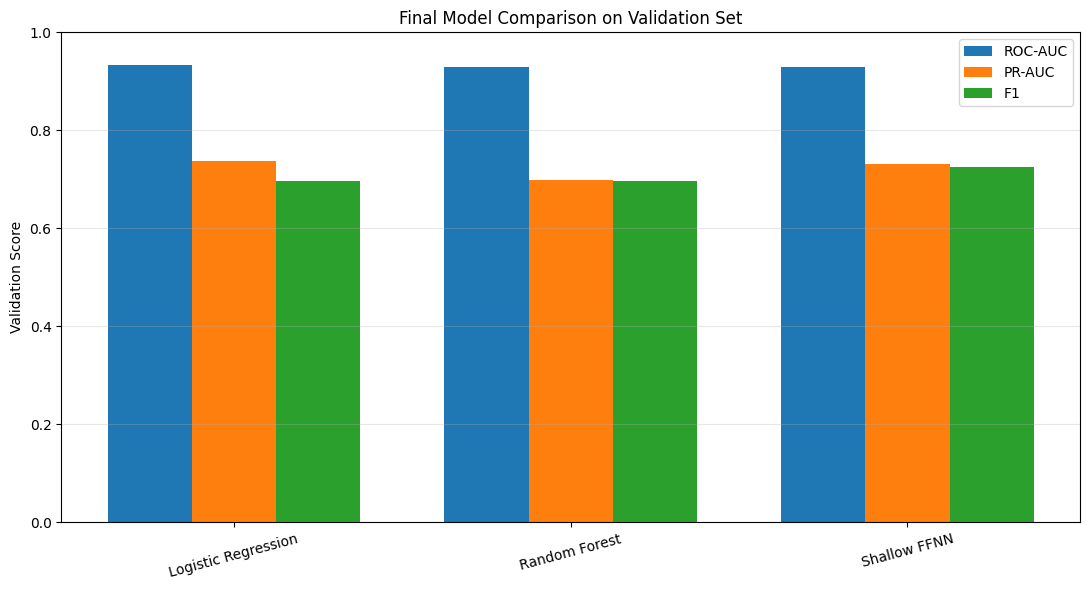

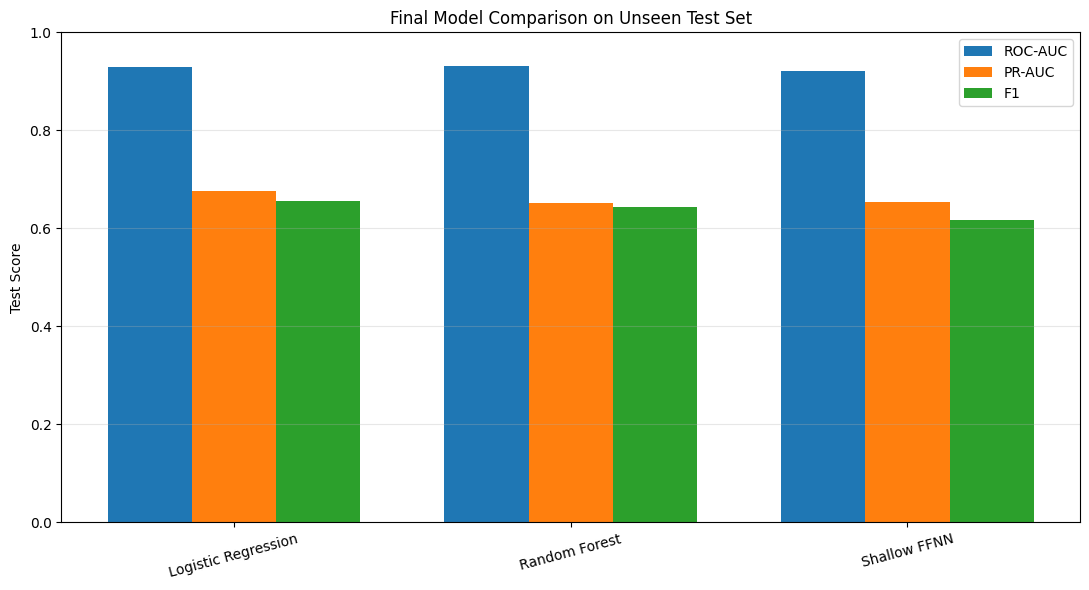

In [125]:
# ============================================================
# Final Model Performance Comparison
# ============================================================

plot_data = final_fair_comparison.copy()
x = np.arange(len(plot_data))
width = 0.25

plt.figure(figsize=(11, 6))
plt.bar(x - width, plot_data["Validation ROC-AUC"], width, label="ROC-AUC")
plt.bar(x, plot_data["Validation PR-AUC"], width, label="PR-AUC")
plt.bar(x + width, plot_data["Validation F1"], width, label="F1")
plt.xticks(x, plot_data["Model"], rotation=15)
plt.ylabel("Validation Score")
plt.ylim(0, 1)
plt.title("Final Model Comparison on Validation Set")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
plt.bar(x - width, plot_data["Test ROC-AUC"], width, label="ROC-AUC")
plt.bar(x, plot_data["Test PR-AUC"], width, label="PR-AUC")
plt.bar(x + width, plot_data["Test F1"], width, label="F1")
plt.xticks(x, plot_data["Model"], rotation=15)
plt.ylabel("Test Score")
plt.ylim(0, 1)
plt.title("Final Model Comparison on Unseen Test Set")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## CHECKPOINT 10 — XAI

**Checklist items covered:** Global explanation (permutation importance, SHAP), local explanation (LIME, local SHAP), plotted and explained.

**Evidence:** Permutation-importance table and plot, SHAP summary plot, SHAP waterfall for one validation row, LIME-style weights plot, each followed by an interpretation cell (all for the final Logistic Regression model).

---

## Model Explainability (XAI)

In [126]:
# ============================================================
# XAI — Permutation Importance
# Using the final model (Logistic Regression) and validation data
# ============================================================

from sklearn.metrics import average_precision_score

# Use the already processed validation data.
X_val_xai = X_validation_main.copy()

# Baseline validation PR-AUC
baseline_pr_auc = average_precision_score(
    y_validation,
    logistic_model.predict_proba(X_val_xai)[:, 1]
)

permutation_results = []

rng = np.random.RandomState(42)

for feature_idx, feature_name in enumerate(X_train.columns):

    drops = []

    for _ in range(5):
        X_permuted = X_val_xai.copy()

        # Shuffle only this feature
        shuffled_values = X_permuted[:, feature_idx].copy()
        rng.shuffle(shuffled_values)
        X_permuted[:, feature_idx] = shuffled_values

        permuted_proba = logistic_model.predict_proba(X_permuted)[:, 1]

        permuted_pr_auc = average_precision_score(
            y_validation,
            permuted_proba
        )

        drops.append(
            baseline_pr_auc - permuted_pr_auc
        )

    permutation_results.append({
        "Feature": feature_name,
        "Mean PR-AUC Drop": np.mean(drops),
        "Std PR-AUC Drop": np.std(drops)
    })

permutation_importance_df = (
    pd.DataFrame(permutation_results)
    .sort_values("Mean PR-AUC Drop", ascending=False)
    .reset_index(drop=True)
)

display(
    permutation_importance_df.head(15).round(4)
)

,Feature,Mean PR-AUC Drop,Std PR-AUC Drop
0,qualifying_position,0.0955,0.0114
1,grid,0.0597,0.0170
2,round,0.0246,0.0044
3,driver_age,0.0217,0.0050
4,driver_previous_podium_rate,0.0141,0.0155
5,q1_missing,0.0128,0.0152
6,driver_previous_races,0.0105,0.0098
7,constructor_previous_podium_rate,0.0098,0.0118
8,constructor_standing_points_before,0.0085,0.0052
9,driver_previous_podiums,0.0068,0.0040


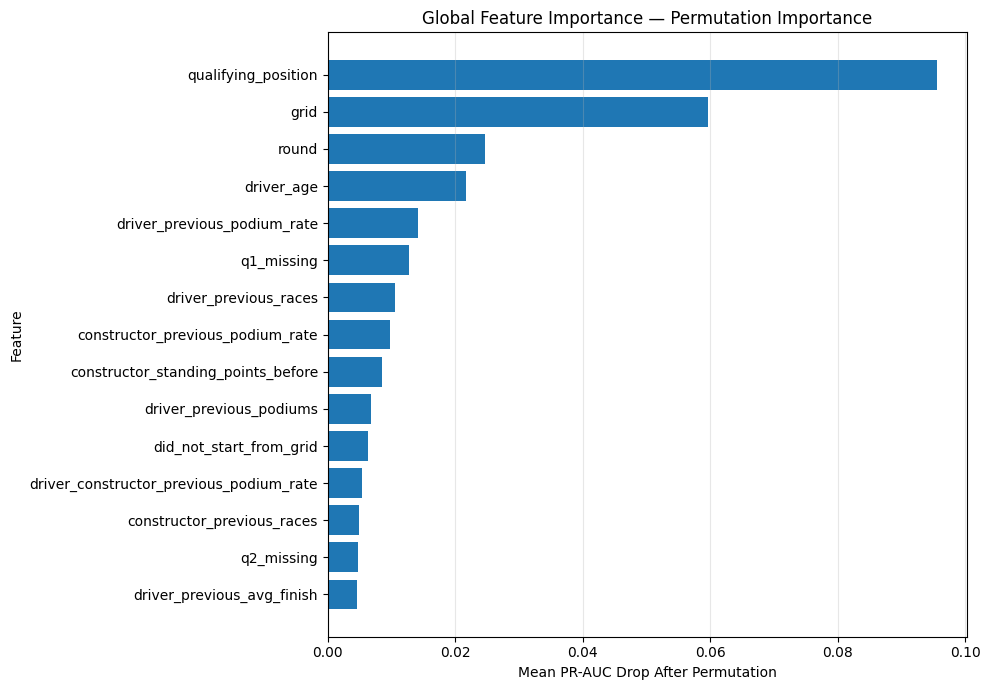

In [127]:
# ============================================================
# XAI — Global Permutation Importance Plot
# ============================================================

top_n = 15

plot_df = (
    permutation_importance_df
    .head(top_n)
    .sort_values("Mean PR-AUC Drop", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Mean PR-AUC Drop"]
)

plt.xlabel("Mean PR-AUC Drop After Permutation")
plt.ylabel("Feature")
plt.title(
    "Global Feature Importance — Permutation Importance"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Global Explanation — Permutation Importance

Permutation importance was calculated for the final Logistic Regression model on the validation
set, using PR-AUC as the evaluation measure. A feature is important when randomly shuffling its
values lowers the model's PR-AUC (each feature is shuffled 5 times; the table shows the mean drop
and its standard deviation).

The largest drops come from **qualifying position** (0.0955) and **grid** (0.0597), so the model
relies most on where the driver starts. Next are **round** (0.0246), **driver age** (0.0217) and
**driver previous podium rate** (0.0141). **Constructor standing points before the race** is 9th
(0.0085).

Some smaller values are not reliable: for example `q1_missing` has a mean drop of 0.0128 but a
standard deviation of 0.0152, so its effect cannot be told apart from zero.

These values describe how much the trained model relies on each feature for prediction. They
should not be interpreted as causal effects: a high permutation importance does not prove that the
feature causes a podium finish.

SHAP values shape: (200, 34)
Feature matrix shape: (200, 34)


,Feature,Mean Absolute SHAP
0,qualifying_position,0.8297
1,grid,0.5513
2,round,0.2859
3,year,0.2814
4,driver_age,0.2729
5,constructor_standing_position_before,0.2405
6,driver_previous_races,0.2392
7,constructor_previous_races,0.2278
8,driver_previous_podium_rate,0.2183
9,q2_missing,0.1960


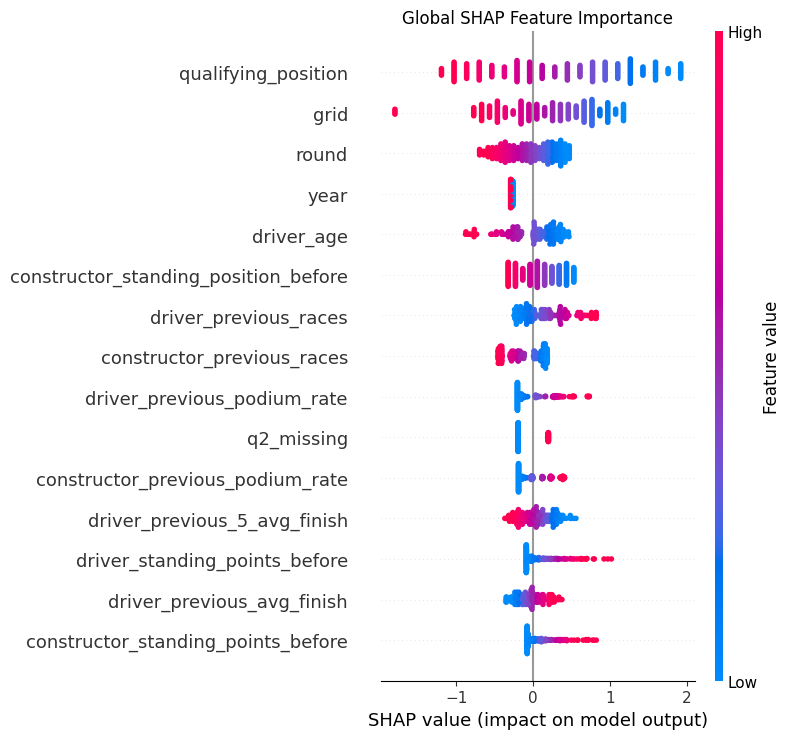

In [128]:
# ============================================================
# XAI — Global SHAP Explanation
# ============================================================

import shap

# ------------------------------------------------------------
# Use a representative background sample from training data
# and a validation sample for explanation.
# ------------------------------------------------------------


background_size = min(100, len(X_train_main))
explanation_size = min(200, len(X_validation_main))

rng = np.random.default_rng(42)

background_indices = rng.choice(
    len(X_train_main),
    size=background_size,
    replace=False
)

explanation_indices = rng.choice(
    len(X_validation_main),
    size=explanation_size,
    replace=False
)

X_background = X_train_main[background_indices]
X_explanation = X_validation_main[explanation_indices]

# ------------------------------------------------------------
# SHAP LinearExplainer for the final Logistic Regression model.
# For a linear model SHAP values are exact: coefficient x (value - average value).
# They are in log-odds units (the model's score before the sigmoid).
# ------------------------------------------------------------

shap_explainer = shap.LinearExplainer(
    logistic_model,
    X_background
)

shap_values = shap_explainer.shap_values(
    X_explanation
)

# Handle different SHAP output formats/versions
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3:
    shap_values = np.squeeze(shap_values, axis=-1)

print("SHAP values shape:", shap_values.shape)
print("Feature matrix shape:", X_explanation.shape)

# ------------------------------------------------------------
# Global SHAP importance
# ------------------------------------------------------------

shap_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean Absolute SHAP": np.mean(
        np.abs(shap_values),
        axis=0
    )
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
).reset_index(drop=True)

display(
    shap_importance_df.head(15).round(4)
)

# ------------------------------------------------------------
# SHAP summary plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_explanation,
    feature_names=X_train.columns,
    max_display=15,
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

Local explanation example
----------------------------------------
Validation row position: 220
Actual podium:           1
Predicted podium:        1
Predicted probability:   0.9815
Decision threshold:      0.62


,Feature,Value,SHAP Value,Absolute SHAP
1,qualifying_position,1.000,1.9172,1.9172
0,grid,1.000,1.1733,1.1733
26,driver_standing_points_before,230.000,0.7947,0.7947
7,driver_previous_podium_rate,0.613,0.7096,0.7096
5,driver_previous_races,261.000,0.6324,0.6324
28,constructor_standing_points_before,391.000,0.5713,0.5713
29,constructor_standing_position_before,1.000,0.5272,0.5272
10,driver_age,35.800,-0.4875,0.4875
6,driver_previous_podiums,160.000,0.4872,0.4872
9,driver_previous_5_avg_finish,2.600,0.4810,0.4810


SHAP reconstructed log-odds: 3.9696
As a probability (sigmoid):  0.9815


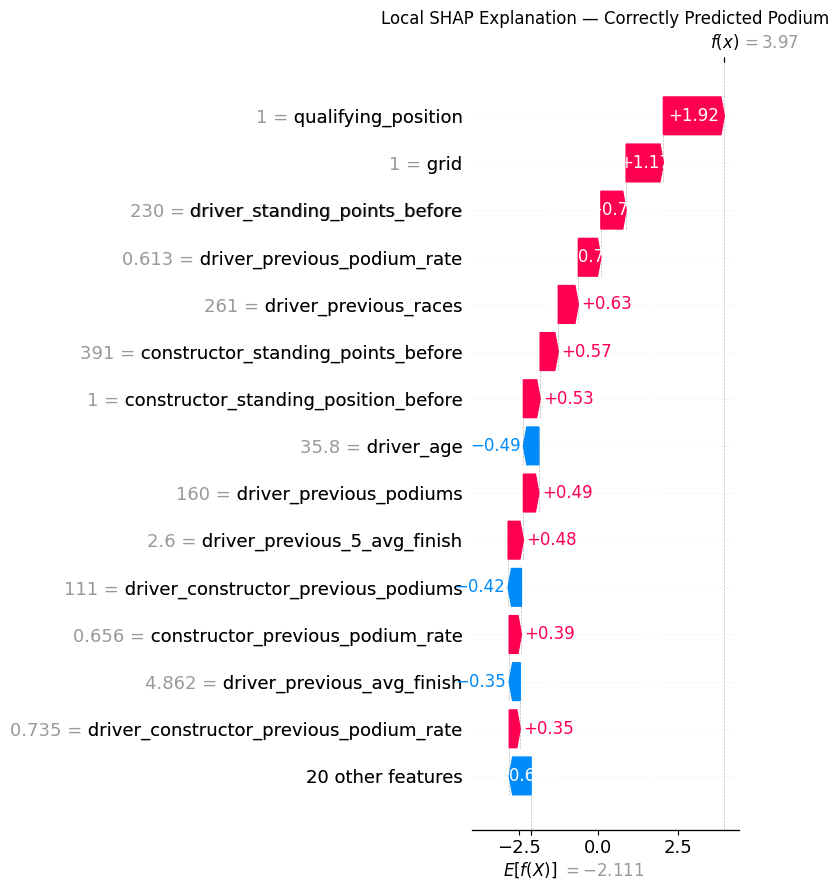

In [129]:
# ============================================================
# XAI — Local SHAP Explanation
# ============================================================

candidate_positions = []

for pos, original_idx in enumerate(explanation_indices):
    actual = int(y_validation.iloc[original_idx])
    predicted = int(
        lr_validation_proba[original_idx] >= best_threshold_lr
    )

    if actual == 1 and predicted == 1:
        candidate_positions.append(pos)

if candidate_positions:
    local_position = max(
        candidate_positions,
        key=lambda p: lr_validation_proba[explanation_indices[p]]
    )
else:
    local_position = int(
        np.argmax(
            [lr_validation_proba[idx] for idx in explanation_indices]
        )
    )

local_original_idx = explanation_indices[local_position]
local_shap_values = np.asarray(shap_values[local_position]).reshape(-1)

local_probability = float(
    lr_validation_proba[local_original_idx]
)
local_prediction = int(
    local_probability >= best_threshold_lr
)
local_actual = int(
    y_validation.iloc[local_original_idx]
)

local_display_values = X_validation.iloc[
    local_original_idx
].values.astype(float)

# Base value = the model's average log-odds over the background sample.
# Base value + sum of SHAP values = this row's log-odds (checked below).
local_base_value = float(np.ravel(shap_explainer.expected_value)[0])

local_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=local_base_value,
    data=local_display_values,
    feature_names=X_train.columns.tolist()
)

local_features_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Value": local_display_values,
    "SHAP Value": local_shap_values
})

local_features_df["Absolute SHAP"] = np.abs(
    local_features_df["SHAP Value"]
)

print("Local explanation example")
print("-" * 40)
print(f"Validation row position: {local_original_idx}")
print(f"Actual podium:           {local_actual}")
print(f"Predicted podium:        {local_prediction}")
print(f"Predicted probability:   {local_probability:.4f}")
print(f"Decision threshold:      {best_threshold_lr:.2f}")

display(
    local_features_df
    .sort_values("Absolute SHAP", ascending=False)
    .head(10)
    .round(4)
)

local_log_odds = local_base_value + np.sum(local_shap_values)
print(f"SHAP reconstructed log-odds: {local_log_odds:.4f}")
print(f"As a probability (sigmoid):  {1 / (1 + np.exp(-local_log_odds)):.4f}")

plt.figure(figsize=(10, 8))
shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=False
)
plt.title("Local SHAP Explanation — Correctly Predicted Podium")
plt.tight_layout()
plt.show()

### Global SHAP and Local Explanation — Individual Prediction

SHAP values are computed with `shap.LinearExplainer`, the exact SHAP method for a linear model:
each feature's contribution is its coefficient × (its value − its average value in the
background sample). The values are in **log-odds**, the model's score before the sigmoid turns it
into a probability.

**Global SHAP (summary plot above).** The mean absolute SHAP values agree with permutation
importance: **qualifying position** (0.8297) and **grid** (0.5513) dominate, followed by
**round** (0.2859), **year** (0.2814), **driver age** (0.2729) and **constructor standing position
before the race** (0.2405). In the summary plot, low qualifying and grid values (starting near the
front) push predictions towards podium, and high values push them away.

Some features are strongly correlated (qualifying position and grid; standings points and
standings position). A linear model can split or offset weight between correlated features, so
their SHAP values should be read together rather than one by one.

**Local SHAP waterfall.** The waterfall explains one correctly predicted podium from the
validation set (validation row 220; actual podium = 1, predicted podium = 1). The model gives it a
podium probability of **0.9815**, above the threshold of 0.62. The base value plus all SHAP values
gives a log-odds of 3.9696, which is exactly this probability after the sigmoid.
- Largest positive contributions: **qualifying position 1** (+1.9172) and **grid 1** (+1.1733).
- Then **230 driver championship points before the race** (+0.7947), a **previous podium rate of
  61%** (+0.7096) and **261 previous races** (+0.6324).
- The **constructor leading the championship** (391 points, position 1) adds +0.5713 and +0.5272.
- The only large negative contribution is **driver age 35.8** (−0.4875).

These SHAP contributions describe model behavior for this observation and should not be
interpreted as causal effects.

## Local Explanation — LIME

The milestone checklist names LIME explicitly, while the detailed XAI requirement also accepts
local SHAP. To remove ambiguity, a local **LIME-style tabular surrogate** is added in addition
to the existing local SHAP explanation.

The implementation follows the core LIME idea: generate perturbed samples around one instance,
obtain the model's predictions for those samples, weight nearby samples more heavily, and fit a
weighted local linear surrogate. The resulting coefficients describe which features most
influence the model locally around this individual prediction.

This is a local model explanation, not a causal analysis.


Selected local example:
Actual podium: 1
Predicted podium: 1
Model probability: 0.9815
Local surrogate R²: 0.7752


,Feature,LIME Weight,Absolute Weight
0,qualifying_position,-0.0242,0.0242
1,grid,-0.0151,0.0151
2,round,-0.0078,0.0078
3,driver_age,-0.0074,0.0074
4,q1_missing,0.0073,0.0073
5,constructor_standing_position_before,-0.0068,0.0068
6,driver_previous_podium_rate,0.0060,0.0060
7,constructor_previous_podium_rate,0.0060,0.0060
8,driver_previous_5_avg_finish,-0.0059,0.0059
9,q2_missing,0.0050,0.0050


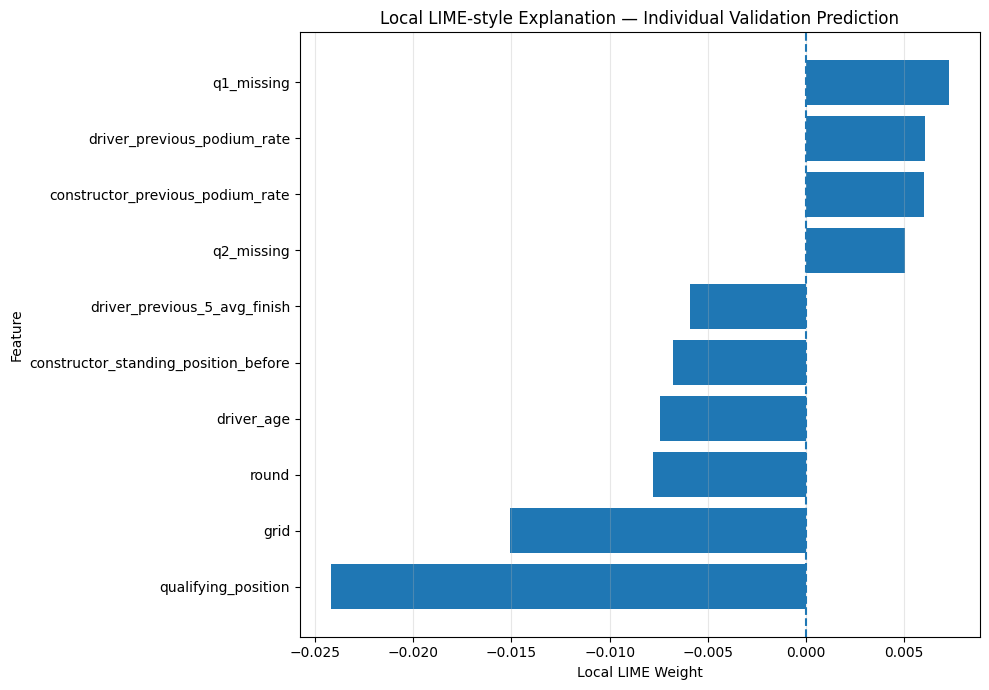

In [130]:
# ============================================================
# XAI — Local LIME-style explanation
# Self-contained implementation to avoid an external dependency.
# ============================================================

from sklearn.linear_model import Ridge

# Use the same individual selected for the local SHAP explanation.
lime_instance = X_validation_main[local_original_idx].copy()

n_lime_samples = 5000
rng_lime = np.random.default_rng(42)

# Estimate a reasonable perturbation scale from the training data.
feature_scale = np.std(X_train_main, axis=0)
feature_scale = np.where(feature_scale == 0, 1.0, feature_scale)

# Generate local perturbations around the selected instance.
lime_perturbations = (
    lime_instance
    + rng_lime.normal(
        loc=0.0,
        scale=0.5,
        size=(n_lime_samples, X_train_main.shape[1])
    ) * feature_scale
)

# Include the original instance exactly as the first sample.
lime_perturbations[0] = lime_instance

# Model predictions for perturbed samples.
lime_probabilities = logistic_model.predict_proba(lime_perturbations)[:, 1]

# Euclidean distance in standardized feature space.
scaled_distances = np.linalg.norm(
    (lime_perturbations - lime_instance) /
    feature_scale,
    axis=1
)

# LIME exponential kernel.
kernel_width = 0.75 * np.sqrt(X_train_main.shape[1])

lime_weights = np.exp(
    -(scaled_distances ** 2) /
    (kernel_width ** 2)
)

# Fit weighted local linear surrogate.
lime_surrogate = Ridge(
    alpha=1.0,
    random_state=42
)

lime_surrogate.fit(
    lime_perturbations,
    lime_probabilities,
    sample_weight=lime_weights
)

lime_coefficients = lime_surrogate.coef_

lime_results = pd.DataFrame({
    "Feature": X_train.columns,
    "LIME Weight": lime_coefficients,
    "Absolute Weight": np.abs(lime_coefficients)
}).sort_values(
    "Absolute Weight",
    ascending=False
).reset_index(drop=True)

print("Selected local example:")
print(f"Actual podium: {local_actual}")
print(f"Predicted podium: {local_prediction}")
print(f"Model probability: {local_probability:.4f}")
print(f"Local surrogate R²: {lime_surrogate.score(lime_perturbations, lime_probabilities, sample_weight=lime_weights):.4f}")

display(
    lime_results.head(10).round(4)
)

# Plot the strongest local LIME weights.
lime_plot_df = (
    lime_results.head(10)
    .sort_values("LIME Weight", ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(
    lime_plot_df["Feature"],
    lime_plot_df["LIME Weight"]
)
plt.axvline(
    0,
    linestyle="--"
)
plt.xlabel("Local LIME Weight")
plt.ylabel("Feature")
plt.title("Local LIME-style Explanation — Individual Validation Prediction")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

lime_explanation_ready = True


### LIME Interpretation

The LIME-style surrogate explains the same validation row and the same Logistic Regression model
as the local SHAP waterfall. It fits the model's probabilities well around this row (local
R² = 0.7752).

The strongest local weights are **qualifying position** (−0.0242) and **grid** (−0.0151), then
**round** (−0.0078) and **driver age** (−0.0074). A negative weight means that a higher value
lowers the podium probability, so starting further back reduces it. This agrees with the SHAP
explanation.

The weights look small because they are on the probability scale and this row is already at
0.9815. Near a probability of 1 the sigmoid is flat, so small changes to a feature barely move the
probability.

The LIME explanation describes **local model behavior**. The weights do not mean that the
corresponding features causally produce a podium finish.

---
## CHECKPOINT 11 — Inference Function and Final Audit

**Checklist items covered:** Inference function demonstrated on a complete and a partially missing record, and the final technical audit.

**Evidence:** The predict_podium function and its two printed predictions, then the audit cell that re-checks grain, target, split, features, preprocessing, models, ablation, XAI and inference with assertions.

---

## Inference Function

In [131]:
# ============================================================
# Final Inference Function
# ============================================================

def predict_podium(input_record):
    """
    Predict podium vs. non-podium for a complete or partially-missing
    pre-race record using the final model (Logistic Regression).
    """

    if isinstance(input_record, dict):
        input_df = pd.DataFrame([input_record])
    elif isinstance(input_record, pd.DataFrame):
        input_df = input_record.copy()
    else:
        raise TypeError(
            "input_record must be a dictionary or pandas DataFrame."
        )

    missing_columns = [
        col for col in X_train.columns
        if col not in input_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing required model features: "
            + ", ".join(missing_columns)
        )

    input_df = input_df[X_train.columns].copy()
    input_processed = preprocessor.transform(input_df)

    probability = float(
        logistic_model.predict_proba(input_processed)[:, 1][0]
    )

    prediction = int(
        probability >= best_threshold_lr
    )

    return {
        "podium_probability": probability,
        "predicted_podium": prediction,
        "classification_threshold": best_threshold_lr
    }


# Complete record demonstration
complete_record = X_validation.iloc[739].to_dict()
complete_prediction = predict_podium(complete_record)

# Partially missing record demonstration
partial_record = complete_record.copy()

partial_record["q1_seconds"] = np.nan
partial_record["q2_seconds"] = np.nan
partial_record["q3_seconds"] = np.nan

# Keep missingness indicators consistent with the changed values.
partial_record["q1_missing"] = 1
partial_record["q2_missing"] = 1
partial_record["q3_missing"] = 1

partial_prediction = predict_podium(partial_record)

print("Complete record prediction:")
print(complete_prediction)

print("\nPartially missing record prediction:")
print(partial_prediction)

Complete record prediction:
{'podium_probability': 0.9853170619143369, 'predicted_podium': 1, 'classification_threshold': 0.6200000000000001}

Partially missing record prediction:
{'podium_probability': 0.9990655637899437, 'predicted_podium': 1, 'classification_threshold': 0.6200000000000001}


### Inference Function Demonstration

The inference function uses the preprocessing pipeline fitted on the training data, the final
Logistic Regression model, and its threshold of 0.62 selected on the validation data.

A complete record and a partially missing record are both accepted. The complete record gets a
podium probability of 0.9853 and is predicted as a podium. In the partial example, the three
qualifying lap times are removed and their missingness indicators set to 1; the function still
returns a prediction (probability 0.9991) because missing values are filled with the training
medians.

## Final MS1 Technical Audit

In [132]:
# ============================================================
# FINAL MS1 TECHNICAL AUDIT
# ============================================================

print("=" * 70)
print("FINAL MS1 TECHNICAL AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Modeling table / grain
# ------------------------------------------------------------

duplicate_pairs = model.duplicated(
    subset=["raceId", "driverId"]
).sum()

print("\n[1] MODELING TABLE")
print(f"Rows: {len(model):,}")
print(f"Columns: {model.shape[1]}")
print(f"Duplicate (raceId, driverId) pairs: {duplicate_pairs}")
print("grid = 0 rows recoded to 30 + flag:", int(X_train["did_not_start_from_grid"].sum()
      + X_validation["did_not_start_from_grid"].sum() + X_test["did_not_start_from_grid"].sum()))
assert (X_train["grid"] > 0).all() and (X_test["grid"] > 0).all()

assert duplicate_pairs == 0

# ------------------------------------------------------------
# 2. Target
# ------------------------------------------------------------

print("\n[2] TARGET")
print(f"Podium cases: {y_train.sum() + y_validation.sum() + y_test.sum():,}")
print(f"Overall podium rate: {model['podium'].mean():.4f}")

assert set(model["podium"].unique()) <= {0, 1}

# ------------------------------------------------------------
# 3. Temporal split
# ------------------------------------------------------------

print("\n[3] TEMPORAL SPLIT")
print(f"Train:      {len(train):,} rows | years {train['year'].min()}–{train['year'].max()}")
print(f"Validation: {len(validation):,} rows | years {validation['year'].min()}–{validation['year'].max()}")
print(f"Test:       {len(test):,} rows | years {test['year'].min()}–{test['year'].max()}")

assert train["year"].max() <= 2019
assert validation["year"].min() >= 2020
assert validation["year"].max() <= 2021
assert test["year"].min() >= 2022

# ------------------------------------------------------------
# 4. Feature set
# ------------------------------------------------------------

print("\n[4] FEATURES")
print(f"Number of model features: {len(X_train.columns)}")
print("All expected features assigned to ablation groups:",
      set(grouped_features) == set(X_train.columns))

assert set(grouped_features) == set(X_train.columns)

# ------------------------------------------------------------
# 5. Preprocessing
# ------------------------------------------------------------

print("\n[5] PREPROCESSING")

print(
    "Training missing values after preprocessing:",
    np.isnan(X_train_main).sum()
)

print(
    "Validation missing values after preprocessing:",
    np.isnan(X_validation_main).sum()
)

print(
    "Test missing values after preprocessing:",
    np.isnan(X_test_main).sum()
)

assert np.isnan(X_train_main).sum() == 0
assert np.isnan(X_validation_main).sum() == 0
assert np.isnan(X_test_main).sum() == 0

# ------------------------------------------------------------
# 6. Preprocessing-order experiment
# ------------------------------------------------------------

print("\n[6] PREPROCESSING-ORDER EXPERIMENT")

if "results_preprocessing" in globals():
    display(results_preprocessing.round(4))
else:
    print("Preprocessing-order results are not available.")

# 7. Model comparison
# ------------------------------------------------------------

print("\n[7] MODEL COMPARISON")
display(final_fair_comparison.round(4))

# ------------------------------------------------------------
# 8. Final model
# ------------------------------------------------------------

# The final model is the one with the highest validation PR-AUC (primary metric).
selected_row = final_fair_comparison.round(4).loc[final_fair_comparison["Validation PR-AUC"].idxmax()]
print("\n[8] FINAL MODEL (highest validation PR-AUC)")
print(selected_row.to_string())

print("Model used for XAI and inference: Logistic Regression (the final model)")

print("\nRunner-up kept for comparison: Shallow FFNN")
print(f"Architecture: {X_train.shape[1]} -> 32 -> 16 -> 1")
print(f"Selected threshold: {best_threshold_ffnn:.2f}")
print(f"Validation ROC-AUC: {validation_roc_auc_ffnn:.4f}")
print(f"Validation PR-AUC:  {validation_pr_auc_ffnn:.4f}")
print(f"Validation F1:      {best_validation_f1_ffnn:.4f}")
print(f"Test ROC-AUC:       {test_roc_auc_ffnn:.4f}")
print(f"Test PR-AUC:        {test_pr_auc_ffnn:.4f}")
print(f"Test F1:            {test_f1_ffnn_tuned:.4f}")

# ------------------------------------------------------------
# 9. Feature ablation
# ------------------------------------------------------------

print("\n[9] FEATURE-GROUP ABLATION")
print(f"Experiments completed: {len(ablation_results_df)}")
display(ablation_results_df.round(4))

assert len(ablation_results_df) == len(feature_groups) + 1

# ------------------------------------------------------------
# 10. Permutation importance
# ------------------------------------------------------------

print("\n[10] PERMUTATION IMPORTANCE")
print(f"Features analyzed: {len(permutation_importance_df)}")
display(permutation_importance_df.head(10).round(4))

assert len(permutation_importance_df) == len(X_train.columns)

# ------------------------------------------------------------
# 11. SHAP
# ------------------------------------------------------------

print("\n[11] GLOBAL SHAP")
print(f"SHAP matrix shape: {shap_values.shape}")
print(f"SHAP importance features: {len(shap_importance_df)}")

assert shap_values.shape[1] == len(X_train.columns)

# ------------------------------------------------------------
# 12. Local explanation
# ------------------------------------------------------------

print("\n[12] LOCAL SHAP")
print(f"Actual podium: {local_actual}")
print(f"Predicted podium: {local_prediction}")
print(f"Probability: {local_probability:.4f}")

# ------------------------------------------------------------
# 13. Inference
# ------------------------------------------------------------

print("\n[13] INFERENCE FUNCTION")

print("Complete record:")
print(complete_prediction)

print("Partially missing record:")
print(partial_prediction)

assert "podium_probability" in complete_prediction
assert "predicted_podium" in complete_prediction
assert "podium_probability" in partial_prediction
assert "predicted_podium" in partial_prediction


# ------------------------------------------------------------
# 14. Sentinel / semantic typing
# ------------------------------------------------------------

print("\n[14] SENTINEL / SEMANTIC TYPING")
print(
    "Literal sentinel values remaining:",
    int(sentinel_report_df["Literal \\N values remaining"].sum())
)
print("Race date dtype:", races_typed["date"].dtype)
print("Driver DOB dtype:", drivers_typed["dob"].dtype)

assert sentinel_report_df["Literal \\N values remaining"].sum() == 0
assert pd.api.types.is_datetime64_any_dtype(races_typed["date"])
assert pd.api.types.is_datetime64_any_dtype(drivers_typed["dob"])

# ------------------------------------------------------------
# 15. LIME local explanation
# ------------------------------------------------------------

print("\n[15] LOCAL LIME")
print("LIME explanation ready:", lime_explanation_ready)

assert lime_explanation_ready is True

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MS1 TECHNICAL AUDIT COMPLETED")
print("=" * 70)
print("Core modeling, experiments, XAI, inference, evaluation, and checklist evidence exist.")

FINAL MS1 TECHNICAL AUDIT

[1] MODELING TABLE
Rows: 10,494
Columns: 63
Duplicate (raceId, driverId) pairs: 0
grid = 0 rows recoded to 30 + flag: 87

[2] TARGET
Podium cases: 1,482
Overall podium rate: 0.1412

[3] TEMPORAL SPLIT
Train:      8,356 rows | years 1994–2019
Validation: 779 rows | years 2020–2021
Test:       1,359 rows | years 2022–2024

[4] FEATURES
Number of model features: 34
All expected features assigned to ablation groups: True

[5] PREPROCESSING
Training missing values after preprocessing: 0
Validation missing values after preprocessing: 0
Test missing values after preprocessing: 0

[6] PREPROCESSING-ORDER EXPERIMENT


,Preprocessing Order,ROC-AUC,PR-AUC,F1
0,Imputation → Standardization,0.9338,0.7368,0.6809
1,Standardization → Imputation,0.9338,0.7368,0.6809



[7] MODEL COMPARISON


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Selected Threshold,Test ROC-AUC,Test PR-AUC,Test F1,Validation Precision,Validation Recall,Test Precision,Test Recall
0,Logistic Regression,0.9338,0.7368,0.6964,0.62,0.9285,0.6752,0.6562,0.6615,0.7350,0.5475,0.8186
1,Random Forest,0.9288,0.6977,0.6975,0.23,0.9311,0.6522,0.6440,0.5976,0.8376,0.5070,0.8824
2,Shallow FFNN,0.9288,0.7309,0.7243,0.58,0.9219,0.6546,0.6164,0.6984,0.7521,0.5385,0.7206



[8] FINAL MODEL (highest validation PR-AUC)
Model                   Logistic Regression
Validation ROC-AUC                   0.9338
Validation PR-AUC                    0.7368
Validation F1                        0.6964
Selected Threshold                     0.62
Test ROC-AUC                         0.9285
Test PR-AUC                          0.6752
Test F1                              0.6562
Validation Precision                 0.6615
Validation Recall                     0.735
Test Precision                       0.5475
Test Recall                          0.8186
Model used for XAI and inference: Logistic Regression (the final model)

Runner-up kept for comparison: Shallow FFNN
Architecture: 34 -> 32 -> 16 -> 1
Selected threshold: 0.58
Validation ROC-AUC: 0.9288
Validation PR-AUC:  0.7309
Validation F1:      0.7243
Test ROC-AUC:       0.9219
Test PR-AUC:        0.6546
Test F1:            0.6164

[9] FEATURE-GROUP ABLATION
Experiments completed: 8


,Experiment,Removed Group,Remaining Features,Validation ROC-AUC,Validation PR-AUC,Validation F1,PR-AUC Drop,F1 Drop
0,Full Model,None,34,0.9288,0.7309,0.7243,0.0000,0.0000
1,Without Qualifying,Qualifying,27,0.9287,0.7338,0.6800,-0.0029,0.0443
2,Without Grid,Grid,32,0.9217,0.6795,0.6957,0.0514,0.0286
3,Without Driver Form,Driver Form,28,0.9278,0.7238,0.6899,0.0071,0.0344
4,Without Constructor Form,Constructor Form,30,0.9186,0.7034,0.6908,0.0275,0.0335
5,Without Driver-Constructor Form,Driver-Constructor Form,30,0.9230,0.7520,0.7236,-0.0211,0.0007
6,Without Standings,Standings,30,0.9286,0.7363,0.7126,-0.0054,0.0117
7,Without Context,Context,27,0.9227,0.7191,0.7073,0.0118,0.0170



[10] PERMUTATION IMPORTANCE
Features analyzed: 34


,Feature,Mean PR-AUC Drop,Std PR-AUC Drop
0,qualifying_position,0.0955,0.0114
1,grid,0.0597,0.0170
2,round,0.0246,0.0044
3,driver_age,0.0217,0.0050
4,driver_previous_podium_rate,0.0141,0.0155
5,q1_missing,0.0128,0.0152
6,driver_previous_races,0.0105,0.0098
7,constructor_previous_podium_rate,0.0098,0.0118
8,constructor_standing_points_before,0.0085,0.0052
9,driver_previous_podiums,0.0068,0.0040



[11] GLOBAL SHAP
SHAP matrix shape: (200, 34)
SHAP importance features: 34

[12] LOCAL SHAP
Actual podium: 1
Predicted podium: 1
Probability: 0.9815

[13] INFERENCE FUNCTION
Complete record:
{'podium_probability': 0.9853170619143369, 'predicted_podium': 1, 'classification_threshold': 0.6200000000000001}
Partially missing record:
{'podium_probability': 0.9990655637899437, 'predicted_podium': 1, 'classification_threshold': 0.6200000000000001}

[14] SENTINEL / SEMANTIC TYPING
Literal sentinel values remaining: 0
Race date dtype: datetime64[ns]
Driver DOB dtype: datetime64[ns]

[15] LOCAL LIME
LIME explanation ready: True

MS1 TECHNICAL AUDIT COMPLETED
Core modeling, experiments, XAI, inference, evaluation, and checklist evidence exist.


## Final Written Summary

# Feature Selection and Pre-Race Validity

All 34 features use only information available after qualifying and before the race starts.

| Group | Features | Why it is valid before the race | Evidence |
|---|---|---|---|
| Qualifying | qualifying position, Q1/Q2/Q3 times (seconds), Q1/Q2/Q3 missing flags | Qualifying finishes before the race | Podium rate falls steeply with qualifying position (EDA plot) |
| Grid | grid position, did-not-start-from-grid flag | The starting grid is fixed before the start | Strongest group in ablation (PR-AUC −0.0514 without it) |
| Driver Form | previous races, previous podiums, podium rate, average finish, last-5 average finish, has-history flag | Built only from earlier races (`shift(1)`) | Driver podium history vs. current podium (EDA plot) |
| Constructor Form | previous races, previous podiums, podium rate, has-history flag | Built only from earlier races | 2nd strongest group in ablation (−0.0275) |
| Driver-Constructor Form | previous races, podiums and podium rate for this driver with this team, has-history flag | Built only from earlier races | Kept; removing it slightly raises PR-AUC, so it overlaps with the two groups above |
| Standings | driver and constructor championship points and position **after the previous round** | Taken from the previous round, never the current race; round 1 starts at 0 points | Correlation with podium: driver position −0.446, constructor position −0.437, driver points +0.403, constructor points +0.382 |
| Context | driver age, year, round, home race, circuit latitude/longitude/altitude | Known from the calendar and driver data | Ablation PR-AUC −0.0118 without it |

`grid = 0` (the car did not start from a grid slot) is recoded to grid 30 plus a flag, so the
model does not read it as "better than pole position". Current-race results, points, status,
laps, pit stops and post-race standings are never used as features.

Feature importance and ablation results describe predictive usefulness within the trained model
and should not be interpreted as causal effects.

# Known Limitations

### Historical qualifying coverage

Qualifying data coverage is incomplete in earlier Formula 1 seasons and becomes
substantially more consistent in later seasons. The modeling population therefore
contains only driver-race records with an observed qualifying record. This avoids
inventing qualifying information but introduces historical coverage drift.

### Temporal and era sensitivity

The model was trained on seasons through 2019, validated on 2020–2021, and tested
on 2022–2024. Performance decreased from validation to the unseen test period,
especially for PR-AUC and F1. This indicates that relationships learned from
earlier seasons do not transfer perfectly to later F1 eras.

### Historical-format differences

Formula 1 has changed substantially across eras, including qualifying formats,
team structures, regulations, and race formats. Features such as year and round
may therefore capture some era-specific differences.

### Interpretation limitations

Permutation importance and SHAP explain how the trained model uses available
features for prediction. They do not establish that an important feature causes
a podium finish.

### Prediction scope

The milestone predicts a binary outcome: podium versus non-podium. It does not
predict the exact finishing position or the specific podium position.

# Final Project Conclusion

The project built a leakage-safe F1 driver-race modeling table (10,494 rows, one per driver per
race, 1994–2024) for binary podium prediction, using only information available before the race
starts. The features cover qualifying, grid, driver form, constructor form, driver-constructor
form, pre-race championship standings, and race context.

Three models were compared on the same features and the same chronological split: Logistic
Regression, Random Forest, and a shallow feed-forward neural network (34 → 32 → 16 → 1). PR-AUC was
the primary metric and F1 the secondary one; thresholds were chosen on the validation seasons only.

**Logistic Regression was selected** because it has the highest validation PR-AUC (0.7368). The
neural network was a close second (0.7309), and the Random Forest overfit (training PR-AUC
0.9953, validation 0.6977). The simplest model winning shows that the main signal is close to
linear: start further forward, with a stronger driver and team record, and the podium chance
rises.

On the unseen 2022–2024 seasons, Logistic Regression reaches ROC-AUC 0.9285, PR-AUC 0.6752 and
F1 0.6562, with recall 0.8186 and precision 0.5475. The drop from validation to test and the low
precision (too many predicted podiums in the new ground-effect era) are the main weaknesses and
are reported rather than hidden.

Pre-race championship standings were added as a leakage-safe feature group. In the ablation they
overlap with the form features: removing them slightly raises PR-AUC but lowers F1 by 0.0117.
Feature-group ablation identified grid and constructor form as the strongest groups.
Permutation importance, SHAP and LIME for the final Logistic Regression model agree that
qualifying position and grid dominate, followed by round, driver age, the driver's podium
history and the championship standings. These are model-reliance measures, not causal effects.

The inference function handles both complete and partially missing pre-race records.

## MS1 Final Submission Checklist

### Notebook requirements

- [x] Exploratory Data Analysis (EDA) with visualizations
- [x] Data Cleaning: `\N` sentinel handling and semantic typing
- [x] Grain fixed to one row per `(raceId, driverId)`
- [x] Duplicate handling documented and cleaning impact visualized
- [x] Primary-key uniqueness/null checks
- [x] Foreign-key reconciliation
- [x] Data Analysis with plotted results
- [x] Data-Engineering Question 1: analysis + visualization + written answer
- [x] Data-Engineering Question 2: analysis + visualization + written answer
- [x] Data-Engineering Question 3: analysis + visualization + written answer
- [x] Feature selection justified with EDA and ablation evidence
- [x] Feature-effect visualizations
- [x] Leakage-safe historical form features using only past races
- [x] Feature engineering
- [x] Preprocessing effect on ranges/distributions
- [x] At least two preprocessing-order experiments
- [x] Chronological train/validation/test split
- [x] Logistic Regression
- [x] Random Forest
- [x] Shallow FFNN
- [x] Model mechanics and limitations documented
- [x] Training and validation performance reported
- [x] Validation-selected thresholds documented
- [x] Unseen test performance reported
- [x] Validation and test model-comparison plots
- [x] Feature-group ablation
- [x] Global permutation importance + plot + interpretation
- [x] Global SHAP + plot + interpretation
- [x] Local SHAP + plot + interpretation
- [x] Local LIME-style explanation + plot + interpretation
- [x] Inference function
- [x] Inference demonstrated on complete and partially missing records
- [x] Final technical audit

### Final submission actions outside the notebook

- [ ] Run the entire notebook from the first cell using **Run All** in Kaggle and confirm zero errors.
- [ ] Export/prepare the structured PDF report containing the DEQ answers, figures, feature rationale, model comparison, ablation, XAI, inference example, and limitations.
- [ ] Verify the submitted Kaggle notebook link and GitHub repository link are accessible.

The first section is complete in the notebook. The last three items are final submission actions that must be performed after the cleaned notebook is executed in the target Kaggle environment.
